## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [34]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro de 2012 até 2024

In [35]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.csv"

df_internacoes = pd.read_csv(url_internacoes)

In [36]:
print("Dimensões:", df_internacoes.shape)

print("\nTipos:")
print(df_internacoes.dtypes)

print("\nAmostra:")
display(df_internacoes.head(10))

print("\nValores ausentes por coluna (top 20):")
na_counts = df_internacoes.isna().sum().sort_values(ascending=False)
na_perc   = (df_internacoes.isna().mean()*100).round(2).sort_values(ascending=False)
display(pd.DataFrame({"NA_count": na_counts, "NA_%": na_perc}).head(20))

Dimensões: (3652, 2)

Tipos:
data_dia           object
num_internacoes     int64
dtype: object

Amostra:


,data_dia,num_internacoes
0,2012-01-01,390
1,2012-01-02,560
2,2012-01-03,330
3,2012-01-04,320
4,2012-01-05,310
5,2012-01-06,400
6,2012-01-07,230
7,2012-01-08,300
8,2012-01-09,340
9,2012-01-10,420



Valores ausentes por coluna (top 20):


,NA_count,NA_%
data_dia,0,0.0
num_internacoes,0,0.0


## Caracterizacao inicial da serie

**Objetivo:** entender o comportamento geral da serie antes de avancar para sazonalidade, decomposicao e modelagem.

Nesta etapa vamos responder perguntas como:
- Qual e o nivel tipico de internacoes?
- Qual e a variabilidade diaria da serie?
- Existem picos muito extremos?
- A serie oscila em torno de um padrao de curto prazo?

Para isso, vamos preparar a base temporal, calcular estatisticas descritivas e visualizar a serie bruta junto de medias moveis.

In [38]:
df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

# Calculando a média móvel de 7 e 30 dias para suavizar a série temporal
df_serie["mm_7d"] = df_serie["num_internacoes"].rolling(window=7, min_periods=1).mean()
df_serie["mm_30d"] = df_serie["num_internacoes"].rolling(window=30, min_periods=1).mean()

print("Periodo da serie:", df_serie["data_dia"].min().date(), "até", df_serie["data_dia"].max().date())
print("Numero de observacoes:", len(df_serie))

display(df_serie.head())

Periodo da serie: 2012-01-01 até 2021-12-30
Numero de observacoes: 3652


,data_dia,num_internacoes,mm_7d,mm_30d
0,2012-01-01,390,390.000000,390.000000
1,2012-01-02,560,475.000000,475.000000
2,2012-01-03,330,426.666667,426.666667
3,2012-01-04,320,400.000000,400.000000
4,2012-01-05,310,382.000000,382.000000


### Estatisticas descritivas

Aqui resumimos a serie em medidas simples. A media e a mediana ajudam a entender o nivel central, enquanto desvio padrao, quartis e percentis mostram a dispersao e o peso dos extremos.

Tambem listamos os dias com maior numero de internacoes para ja identificar eventos ou picos que merecem investigacao mais adiante.

In [39]:
# Calculando medidas de posicao e dispersao da serie.
q1 = df_serie["num_internacoes"].quantile(0.25)
q3 = df_serie["num_internacoes"].quantile(0.75)
iqr = q3 - q1
media = df_serie["num_internacoes"].mean()
desvio = df_serie["num_internacoes"].std()

resumo_inicial = pd.DataFrame(
    {
        "metrica": [
            "media",
            "mediana",
            "desvio_padrao",
            "minimo",
            "maximo",
            "q1",
            "q3",
            "iqr",
            "percentil_95",
            "percentil_99",
            "coeficiente_de_variacao"
        ],
        "valor": [
            media,
            df_serie["num_internacoes"].median(),
            desvio,
            df_serie["num_internacoes"].min(),
            df_serie["num_internacoes"].max(),
            q1,
            q3,
            iqr,
            df_serie["num_internacoes"].quantile(0.95),
            df_serie["num_internacoes"].quantile(0.99),
            desvio / media
        ]
    }
)

display(resumo_inicial.round(2))

print("Dias com maiores volumes de internacoes:")
display(
    df_serie.nlargest(10, "num_internacoes")[["data_dia", "num_internacoes"]]
    .reset_index(drop=True)
)


,metrica,valor
0,media,225.39
1,mediana,200.00
2,desvio_padrao,152.99
3,minimo,3.00
4,maximo,970.00
5,q1,105.00
6,q3,310.00
7,iqr,205.00
8,percentil_95,520.00
9,percentil_99,710.49


Dias com maiores volumes de internacoes:


,data_dia,num_internacoes
0,2012-05-28,970
1,2012-05-23,940
2,2012-05-22,930
3,2012-05-14,920
4,2012-05-18,900
5,2012-05-30,900
6,2012-06-25,870
7,2012-05-17,860
8,2012-05-25,860
9,2012-06-05,850


### Visualizacao temporal da serie

O grafico abaixo mostra a serie diaria original e duas medias moveis:
- `mm_7d`: suaviza o ruido diario e destaca o comportamento semanal.
- `mm_30d`: mostra melhor o nivel de medio prazo da serie.

Se a linha diaria estiver muito espalhada, isso indica alta volatilidade. Se as medias moveis mudarem bastante ao longo do tempo, ja temos sinal de tendencia ou mudanca de regime.

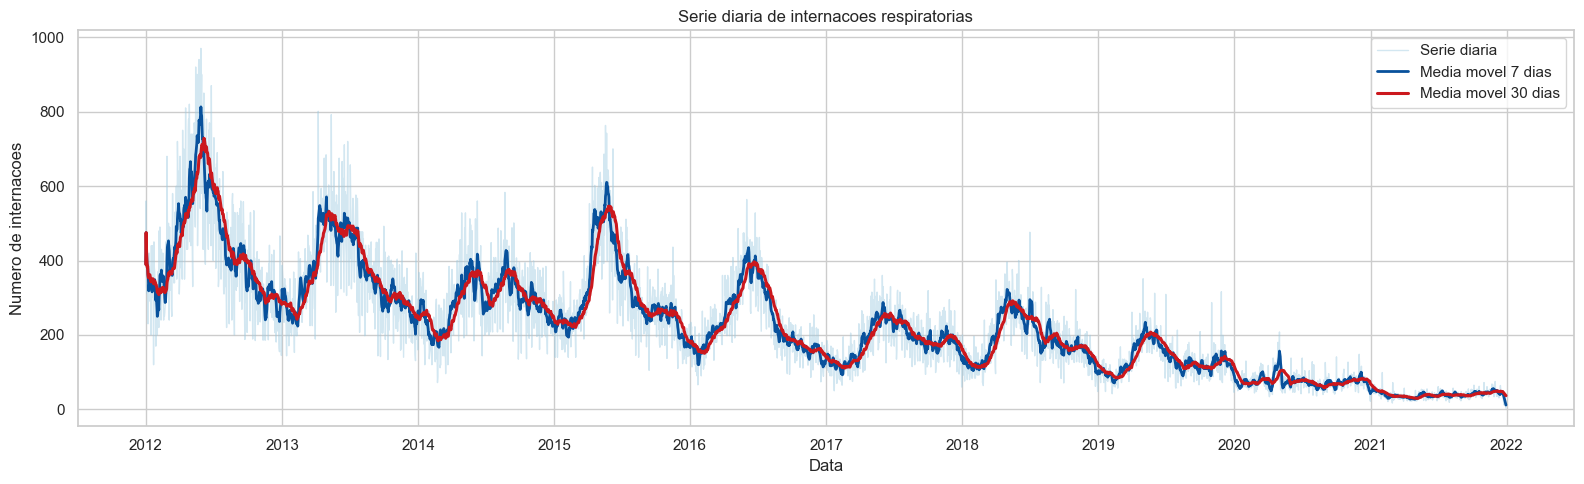

In [40]:
plt.figure(figsize=(16, 5))

plt.plot(
    df_serie["data_dia"],
    df_serie["num_internacoes"],
    color="#9ecae1",
    linewidth=1,
    alpha=0.45,
    label="Serie diaria"
)

plt.plot(
    df_serie["data_dia"],
    df_serie["mm_7d"],
    color="#08519c",
    linewidth=2,
    label="Media movel 7 dias"
)

plt.plot(
    df_serie["data_dia"],
    df_serie["mm_30d"],
    color="#cb181d",
    linewidth=2.2,
    label="Media movel 30 dias"
)

plt.title("Serie diaria de internacoes respiratorias")
plt.xlabel("Data")
plt.ylabel("Numero de internacoes")
plt.legend()
plt.tight_layout()
plt.show()

### Distribuicao dos valores

A serie temporal pode ter comportamento muito assimetrico. Por isso, alem do grafico no tempo, vale olhar a distribuicao dos valores diarios.

O histograma mostra onde a maior parte dos dias se concentra. O boxplot ajuda a ver a dispersao, a mediana e a presenca de valores extremos.

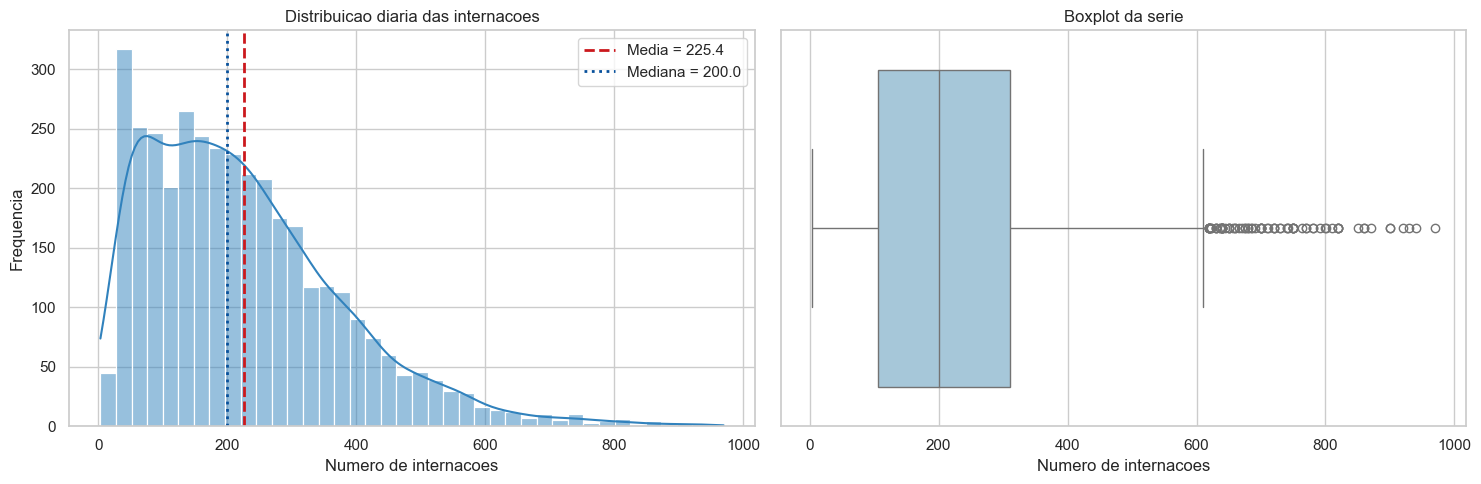

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_serie["num_internacoes"], bins=40, kde=True, color="#3182bd", ax=axes[0])
axes[0].axvline(
    df_serie["num_internacoes"].mean(),
    color="#cb181d",
    linestyle="--",
    linewidth=2,
    label=f"Media = {df_serie['num_internacoes'].mean():.1f}"
)
axes[0].axvline(
    df_serie["num_internacoes"].median(),
    color="#08519c",
    linestyle=":",
    linewidth=2,
    label=f"Mediana = {df_serie['num_internacoes'].median():.1f}"
)
axes[0].set_title("Distribuicao diaria das internacoes")
axes[0].set_xlabel("Numero de internacoes")
axes[0].set_ylabel("Frequencia")
axes[0].legend()

sns.boxplot(x=df_serie["num_internacoes"], color="#9ecae1", ax=axes[1])
axes[1].set_title("Boxplot da serie")
axes[1].set_xlabel("Numero de internacoes")

plt.tight_layout()
plt.show()

### Resumo interpretativo dos resultados

A média esta em torno de **142,6 internacoes por dia**, mas a **mediana de 124** mostra que os dias mais tipicos ficam abaixo da media. 

A variabilidade da serie tambem é alta. O **desvio padrao foi 92,4**, o **IQR foi 110** e o **coeficiente de variacao ficou em 0,65**, o que sugere que a oscilacao diaria não é pequena em relação a média. Os percentis reforcam isso: **95% dos dias ficaram abaixo de 325 internacoes** e **99% abaixo de 450**, enquanto o valor maximo chegou a **714**. Portanto, a serie apresenta eventos extremos relevantes e nao apenas pequenas flutuacoes aleatorias.

Os maiores picos ficaram concentrados principalmente em **2012**, **2018** e **2019**, com destaque para varios dias entre **abril e julho de 2018**. Isso pode indicar mudancas de regime, ondas respiratorias mais intensas em periodos especificos ou ate alteracoes operacionais/de registro que precisam ser verificadas nas proximas etapas.

**Possiveis analises e consequencias**
- A diferenca entre media e mediana, junto da cauda a direita observada no histograma, sugere testar transformacoes como `log1p` antes da modelagem.
- A presenca de muitos valores extremos no boxplot indica que vale investigar outliers e dias de pico como eventos epidemiologicos, sazonais ou mudancas de notificacao.
- Como varios picos aparecem entre abril e julho, a proxima secao deve explorar sazonalidade anual e efeitos de calendario para separar padrao recorrente de eventos excepcionais.

## Sazonalidade e calendario

**Objetivo:** investigar se a serie apresenta padroes recorrentes associados ao calendario. Em series de internacoes, esse tipo de analise costuma revelar efeitos de inverno, de dia util/fim de semana, de feriados e de concentracao em certos periodos do ano.

Nesta etapa vamos analisar a serie por:
- ano;
- mes;
- semana epidemiologica;
- dia da semana;
- fim de semana;
- feriados e datas moveis relevantes;
- estacoes do ano.

Antes dos graficos, vamos enriquecer o dataframe com variaveis de calendario que serao reutilizadas nas proximas etapas.

In [42]:
from dateutil.easter import easter

# Dicionarios para manter a ordenacao e os nomes em portugues sem depender da configuracao local da maquina.
meses_pt = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

dias_semana_pt = {
    0: "Seg", 1: "Ter", 2: "Qua", 3: "Qui", 4: "Sex", 5: "Sab", 6: "Dom"
}

ordem_estacoes = ["Verao", "Outono", "Inverno", "Primavera"]


def classificar_estacao(data):
    """Classifica a estacao do ano considerando o hemisferio sul."""
    mes = data.month
    if mes in [12, 1, 2]:
        return "Verao"
    if mes in [3, 4, 5]:
        return "Outono"
    if mes in [6, 7, 8]:
        return "Inverno"
    return "Primavera"


def construir_datas_especiais(anos):
    """Monta uma tabela de feriados oficiais e datas moveis relevantes para o RJ."""
    registros = []

    for ano in anos:
        feriados_fixos = [
            (f"{ano}-01-01", "Confraternizacao Universal", "Feriado oficial"),
            (f"{ano}-01-20", "Sao Sebastiao (Rio de Janeiro)", "Feriado oficial"),
            (f"{ano}-04-21", "Tiradentes", "Feriado oficial"),
            (f"{ano}-04-23", "Sao Jorge (RJ)", "Feriado oficial"),
            (f"{ano}-05-01", "Dia do Trabalho", "Feriado oficial"),
            (f"{ano}-09-07", "Independencia do Brasil", "Feriado oficial"),
            (f"{ano}-10-12", "Nossa Senhora Aparecida", "Feriado oficial"),
            (f"{ano}-11-02", "Finados", "Feriado oficial"),
            (f"{ano}-11-15", "Proclamacao da Republica", "Feriado oficial"),
            (f"{ano}-12-25", "Natal", "Feriado oficial"),
        ]

        pascoa = pd.Timestamp(easter(ano))
        datas_moveis = [
            (pascoa - pd.Timedelta(days=48), "Segunda de Carnaval", "Data movel relevante"),
            (pascoa - pd.Timedelta(days=47), "Terca de Carnaval", "Data movel relevante"),
            (pascoa - pd.Timedelta(days=2), "Sexta-feira Santa", "Data movel relevante"),
            (pascoa + pd.Timedelta(days=60), "Corpus Christi", "Data movel relevante"),
        ]

        for data_ref, nome, categoria in feriados_fixos:
            registros.append(
                {
                    "data_dia": pd.Timestamp(data_ref),
                    "nome_data_especial": nome,
                    "categoria_data_especial": categoria,
                }
            )

        for data_ref, nome, categoria in datas_moveis:
            registros.append(
                {
                    "data_dia": pd.Timestamp(data_ref),
                    "nome_data_especial": nome,
                    "categoria_data_especial": categoria,
                }
            )

    return pd.DataFrame(registros)


# Criamos atributos de calendario que serao usados em todos os recortes seguintes.
df_serie["ano"] = df_serie["data_dia"].dt.year
df_serie["mes"] = df_serie["data_dia"].dt.month
df_serie["mes_nome"] = pd.Categorical(
    df_serie["mes"].map(meses_pt),
    categories=list(meses_pt.values()),
    ordered=True,
)

df_serie["dia_semana_num"] = df_serie["data_dia"].dt.dayofweek
df_serie["dia_semana_nome"] = pd.Categorical(
    df_serie["dia_semana_num"].map(dias_semana_pt),
    categories=list(dias_semana_pt.values()),
    ordered=True,
)

df_serie["fim_de_semana"] = df_serie["dia_semana_num"].isin([5, 6])
df_serie["fim_de_semana_label"] = np.where(df_serie["fim_de_semana"], "Fim de semana", "Dia util")
df_serie["estacao"] = pd.Categorical(
    df_serie["data_dia"].apply(classificar_estacao),
    categories=ordem_estacoes,
    ordered=True,
)

# Semana epidemiologica com inicio no domingo.
# Operacionalmente, deslocamos a data em +1 dia e usamos o calendario ISO.
ref_epi = (df_serie["data_dia"] + pd.Timedelta(days=1)).dt.isocalendar()
df_serie["ano_epi"] = ref_epi.year.astype(int)
df_serie["semana_epi"] = ref_epi.week.astype(int)

# Removemos colunas da rodada anterior para que a celula possa ser executada mais de uma vez sem duplicar informacao.
df_serie = df_serie.drop(columns=["nome_data_especial", "categoria_data_especial", "is_data_especial"], errors="ignore")

# Integramos feriados oficiais e datas moveis relevantes ao dataframe principal.
datas_especiais = construir_datas_especiais(sorted(df_serie["ano"].unique()))
df_serie = df_serie.merge(datas_especiais, on="data_dia", how="left")
df_serie["is_data_especial"] = df_serie["nome_data_especial"].notna()
df_serie["categoria_data_especial"] = df_serie["categoria_data_especial"].fillna("Dia comum")
df_serie["nome_data_especial"] = df_serie["nome_data_especial"].fillna("Dia comum")

display(
    df_serie[
        [
            "data_dia",
            "num_internacoes",
            "ano",
            "mes_nome",
            "semana_epi",
            "dia_semana_nome",
            "fim_de_semana_label",
            "estacao",
            "nome_data_especial",
        ]
    ].head(10)
)

,data_dia,num_internacoes,ano,mes_nome,semana_epi,dia_semana_nome,fim_de_semana_label,estacao,nome_data_especial
0,2012-01-01,390,2012,Jan,1,Dom,Fim de semana,Verao,Confraternizacao Universal
1,2012-01-02,560,2012,Jan,1,Seg,Dia util,Verao,Dia comum
2,2012-01-03,330,2012,Jan,1,Ter,Dia util,Verao,Dia comum
3,2012-01-04,320,2012,Jan,1,Qua,Dia util,Verao,Dia comum
4,2012-01-05,310,2012,Jan,1,Qui,Dia util,Verao,Dia comum
5,2012-01-06,400,2012,Jan,1,Sex,Dia util,Verao,Dia comum
6,2012-01-07,230,2012,Jan,1,Sab,Fim de semana,Verao,Dia comum
7,2012-01-08,300,2012,Jan,2,Dom,Fim de semana,Verao,Dia comum
8,2012-01-09,340,2012,Jan,2,Seg,Dia util,Verao,Dia comum
9,2012-01-10,420,2012,Jan,2,Ter,Dia util,Verao,Dia comum


### Recorte por ano e por mes

Aqui verificamos se o nivel da serie muda de um ano para outro e em quais meses a demanda costuma ser maior ou menor. Isso ajuda a separar tendencia estrutural de sazonalidade anual.

,ano,total_anual,media_diaria,mediana_diaria,maximo_diario
0,2012,158667,433.52,401.5,970
1,2013,133297,365.20,351.0,801
2,2014,106478,291.72,288.0,583
3,2015,113559,311.12,280.0,763
4,2016,85810,234.45,210.0,564
5,2017,67232,184.20,179.0,360
6,2018,67918,186.08,172.0,476
7,2019,48523,132.94,126.0,351
8,2020,27312,74.62,70.0,208
9,2021,14336,39.38,39.0,99


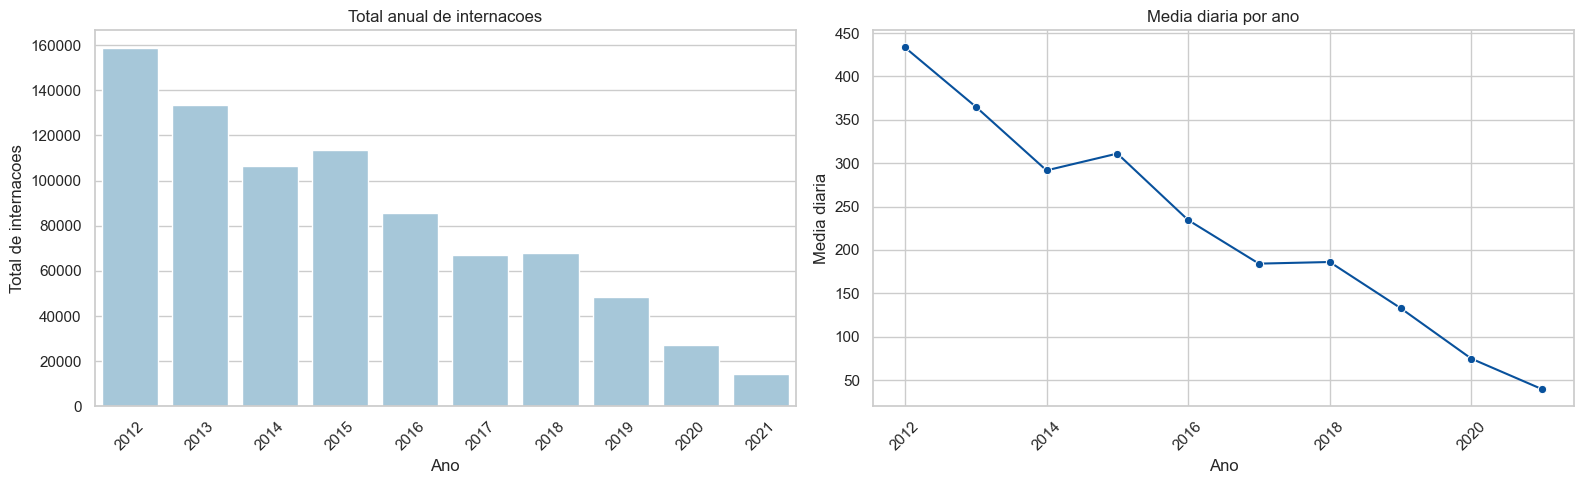

In [43]:
# Resumo anual para enxergar mudancas de nivel ao longo do tempo.
resumo_anual = (
    df_serie.groupby("ano")["num_internacoes"]
    .agg(total_anual="sum", media_diaria="mean", mediana_diaria="median", maximo_diario="max")
    .reset_index()
)

display(resumo_anual.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=resumo_anual, x="ano", y="total_anual", color="#9ecae1", ax=axes[0])
axes[0].set_title("Total anual de internacoes")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Total de internacoes")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=resumo_anual, x="ano", y="media_diaria", marker="o", color="#08519c", ax=axes[1])
axes[1].set_title("Media diaria por ano")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Media diaria")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

,mes_nome,media,mediana,desvio_padrao
0,Jan,170.31,144.0,102.11
1,Fev,167.29,140.0,109.08
2,Mar,206.04,180.0,134.59
3,Abr,291.66,259.0,183.02
4,Mai,328.21,298.0,215.13
5,Jun,298.88,276.0,187.48
6,Jul,262.66,251.0,161.40
7,Ago,224.23,212.0,136.33
8,Set,205.02,185.5,125.91
9,Out,195.26,178.0,112.23


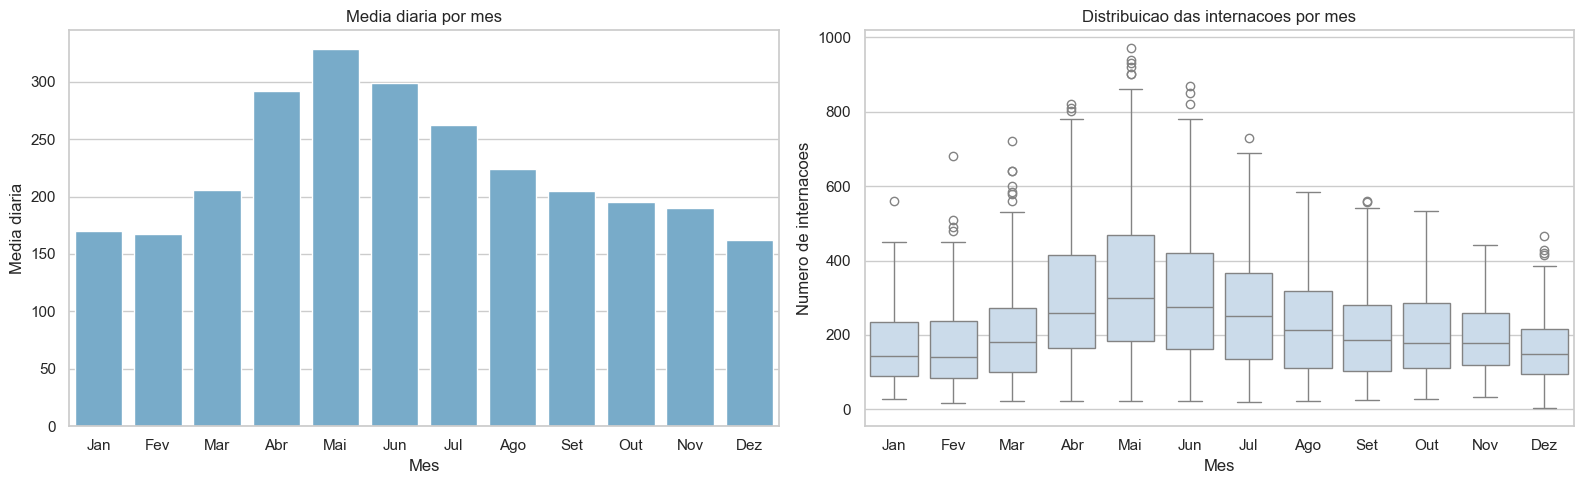

In [44]:
# Resumo mensal para identificar meses com comportamento tipicamente mais alto ou mais baixo.
resumo_mensal = (
    df_serie.groupby(["mes", "mes_nome"], observed=True)["num_internacoes"]
    .agg(media="mean", mediana="median", desvio_padrao="std")
    .reset_index()
    .sort_values("mes")
)

display(resumo_mensal[["mes_nome", "media", "mediana", "desvio_padrao"]].round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=resumo_mensal, x="mes_nome", y="media", color="#6baed6", ax=axes[0])
axes[0].set_title("Media diaria por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Media diaria")

sns.boxplot(data=df_serie, x="mes_nome", y="num_internacoes", color="#c6dbef", ax=axes[1])
axes[1].set_title("Distribuicao das internacoes por mes")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Numero de internacoes")

plt.tight_layout()
plt.show()

### Recorte por semana epidemiologica

A semana epidemiologica ajuda a suavizar a leitura da sazonalidade ao longo do ano. Em saude publica, esse recorte costuma ser mais informativo do que olhar apenas o mes, porque mostra melhor o inicio, a subida e o recuo das ondas.

,semana_epi,media,mediana
0,1,183.43,170.0
1,2,175.43,139.0
2,3,168.27,144.0
3,4,157.29,129.0
4,5,161.21,146.0
5,6,150.79,122.0
6,7,171.97,148.0
7,8,169.77,140.0
8,9,185.24,147.5
9,10,189.73,169.0


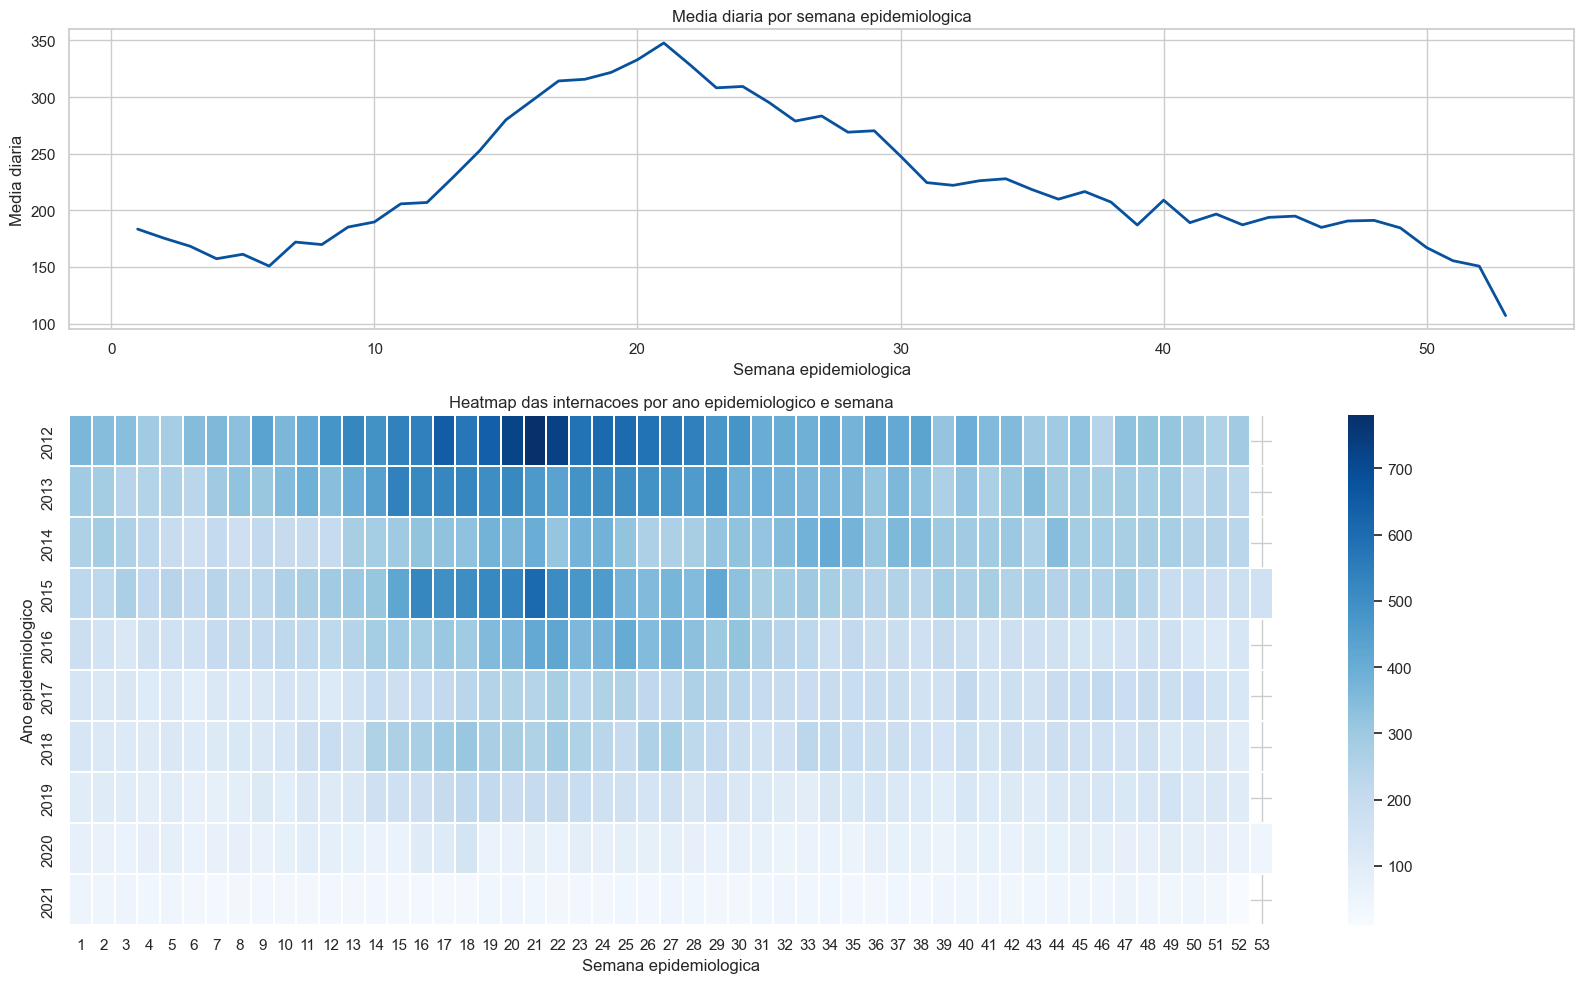

In [45]:
# Media diaria por semana epidemiologica ao longo de toda a serie.
resumo_semana_epi = (
    df_serie.groupby("semana_epi")["num_internacoes"]
    .agg(media="mean", mediana="median")
    .reset_index()
)

display(resumo_semana_epi.round(2).head(15))

# Heatmap ano x semana para observar se os picos semanais se repetem nos mesmos periodos.
heatmap_semana_epi = (
    df_serie.groupby(["ano_epi", "semana_epi"])["num_internacoes"]
    .mean()
    .reset_index()
    .pivot(index="ano_epi", columns="semana_epi", values="num_internacoes")
)

ano_min = int(df_serie["ano"].min())
ano_max = int(df_serie["ano"].max())
heatmap_semana_epi = heatmap_semana_epi.loc[(heatmap_semana_epi.index >= ano_min) & (heatmap_semana_epi.index <= ano_max)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={"height_ratios": [1, 1.7]})

sns.lineplot(data=resumo_semana_epi, x="semana_epi", y="media", color="#08519c", linewidth=2, ax=axes[0])
axes[0].set_title("Media diaria por semana epidemiologica")
axes[0].set_xlabel("Semana epidemiologica")
axes[0].set_ylabel("Media diaria")

sns.heatmap(heatmap_semana_epi, cmap="Blues", linewidths=0.1, ax=axes[1])
axes[1].set_title("Heatmap das internacoes por ano epidemiologico e semana")
axes[1].set_xlabel("Semana epidemiologica")
axes[1].set_ylabel("Ano epidemiologico")

plt.tight_layout()
plt.show()

### Dia da semana, fim de semana e datas especiais

Esse bloco ajuda a identificar padrao operacional ou assistencial. Diferencas fortes entre dias uteis e fins de semana podem refletir tanto comportamento real da demanda quanto dinamica de atendimento, registro ou adiamento de internacoes eletivas.

Nas datas especiais, combinamos feriados oficiais e algumas datas moveis relevantes para o contexto brasileiro, como Carnaval, Sexta-feira Santa e Corpus Christi.

,dia_semana_nome,media,mediana,desvio_padrao
0,Seg,260.14,230.5,177.80
1,Ter,246.12,210.5,164.32
2,Qua,249.93,226.5,163.59
3,Qui,230.89,212.0,149.47
4,Sex,232.28,210.0,154.14
5,Sab,184.18,165.0,116.85
6,Dom,174.13,159.5,110.92


,fim_de_semana_label,media,mediana,desvio_padrao
0,Dia util,243.88,220.0,162.41
1,Fim de semana,179.15,160.0,113.98


,nome_data_especial,categoria_data_especial,ocorrencias,media,mediana
2,Dia do Trabalho,Feriado oficial,10,322.2,323.5
13,Tiradentes,Feriado oficial,10,289.1,273.0
8,Sao Jorge (RJ),Feriado oficial,10,251.5,216.5
1,Corpus Christi,Data movel relevante,10,247.6,241.5
11,Sexta-feira Santa,Data movel relevante,10,206.8,169.5
0,Confraternizacao Universal,Feriado oficial,10,201.3,193.0
4,Independencia do Brasil,Feriado oficial,10,183.3,172.5
3,Finados,Feriado oficial,10,165.4,169.5
9,Sao Sebastiao (Rio de Janeiro),Feriado oficial,10,164.5,117.5
6,Nossa Senhora Aparecida,Feriado oficial,10,157.7,141.5


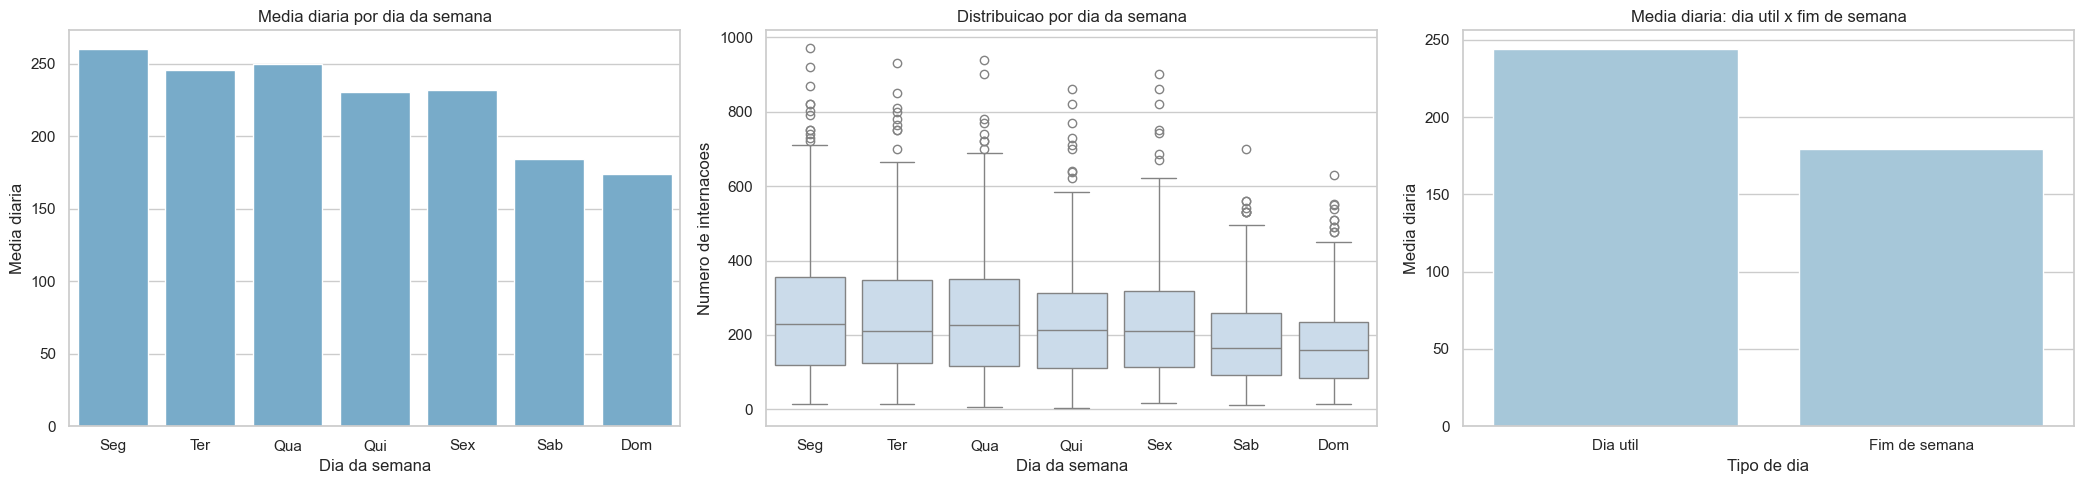

In [46]:
# Comparamos o nivel medio por dia da semana e por tipo de dia.
resumo_dia_semana = (
    df_serie.groupby(["dia_semana_num", "dia_semana_nome"], observed=True)["num_internacoes"]
    .agg(media="mean", mediana="median", desvio_padrao="std")
    .reset_index()
    .sort_values("dia_semana_num")
)

resumo_fim_de_semana = (
    df_serie.groupby("fim_de_semana_label")["num_internacoes"]
    .agg(media="mean", mediana="median", desvio_padrao="std")
    .reindex(["Dia util", "Fim de semana"])
    .reset_index()
)

resumo_datas_especiais = (
    df_serie[df_serie["is_data_especial"]]
    .groupby(["nome_data_especial", "categoria_data_especial"])["num_internacoes"]
    .agg(ocorrencias="count", media="mean", mediana="median")
    .reset_index()
    .sort_values("media", ascending=False)
)

display(resumo_dia_semana[["dia_semana_nome", "media", "mediana", "desvio_padrao"]].round(2))
display(resumo_fim_de_semana.round(2))
display(resumo_datas_especiais.round(2))

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

sns.barplot(data=resumo_dia_semana, x="dia_semana_nome", y="media", color="#6baed6", ax=axes[0])
axes[0].set_title("Media diaria por dia da semana")
axes[0].set_xlabel("Dia da semana")
axes[0].set_ylabel("Media diaria")

sns.boxplot(data=df_serie, x="dia_semana_nome", y="num_internacoes", color="#c6dbef", ax=axes[1])
axes[1].set_title("Distribuicao por dia da semana")
axes[1].set_xlabel("Dia da semana")
axes[1].set_ylabel("Numero de internacoes")

sns.barplot(data=resumo_fim_de_semana, x="fim_de_semana_label", y="media", color="#9ecae1", ax=axes[2])
axes[2].set_title("Media diaria: dia util x fim de semana")
axes[2].set_xlabel("Tipo de dia")
axes[2].set_ylabel("Media diaria")

plt.tight_layout()
plt.show()

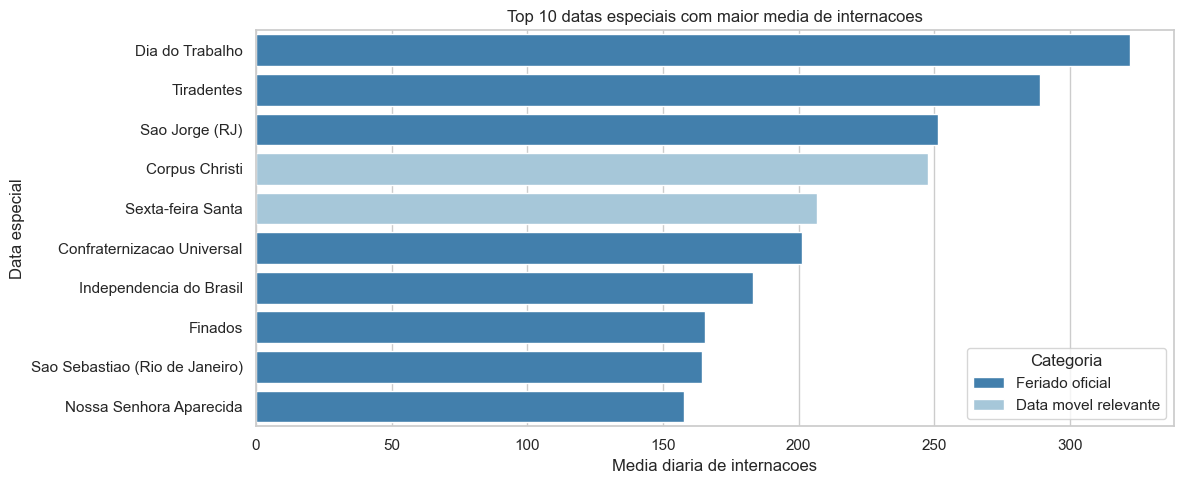

In [47]:
# Destacamos quais datas especiais apresentam, em media, os maiores valores observados.
top_datas_especiais = resumo_datas_especiais.head(10).copy()

plt.figure(figsize=(12, 5))
sns.barplot(data=top_datas_especiais, x="media", y="nome_data_especial", hue="categoria_data_especial", dodge=False, palette=["#3182bd", "#9ecae1"])
plt.title("Top 10 datas especiais com maior media de internacoes")
plt.xlabel("Media diaria de internacoes")
plt.ylabel("Data especial")
plt.legend(title="Categoria")
plt.tight_layout()
plt.show()

### Estacoes do ano

Como a serie trata de internacoes respiratorias, comparar o comportamento entre estacoes e especialmente importante. No hemisferio sul, o inverno corresponde aos meses de junho, julho e agosto.

,estacao,media,mediana,desvio_padrao
0,Verao,166.57,145.0,100.08
1,Outono,275.12,244.5,187.62
2,Inverno,261.52,245.0,165.44
3,Primavera,196.89,179.5,112.92


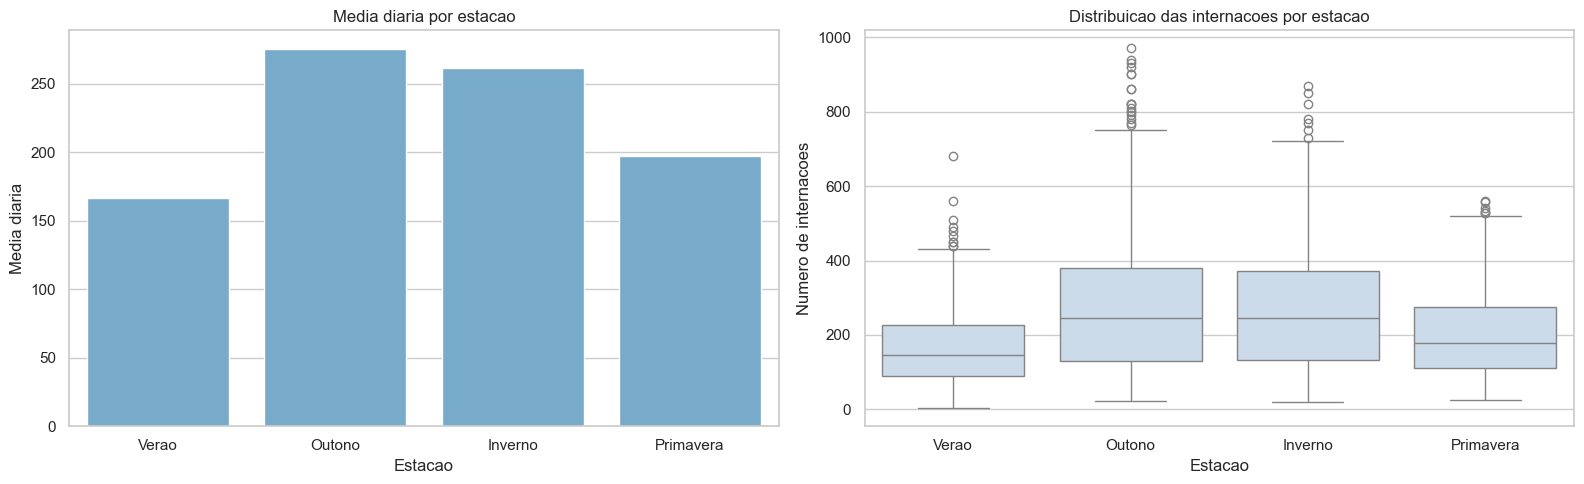

In [48]:
# Resumo por estacao para verificar efeito sazonal mais amplo do clima.
resumo_estacao = (
    df_serie.groupby("estacao", observed=True)["num_internacoes"]
    .agg(media="mean", mediana="median", desvio_padrao="std")
    .reset_index()
)

display(resumo_estacao.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=resumo_estacao, x="estacao", y="media", color="#6baed6", ax=axes[0])
axes[0].set_title("Media diaria por estacao")
axes[0].set_xlabel("Estacao")
axes[0].set_ylabel("Media diaria")

sns.boxplot(data=df_serie, x="estacao", y="num_internacoes", color="#c6dbef", ax=axes[1])
axes[1].set_title("Distribuicao das internacoes por estacao")
axes[1].set_xlabel("Estacao")
axes[1].set_ylabel("Numero de internacoes")

plt.tight_layout()
plt.show()

### O que observar nesta etapa

- Se alguns anos tiverem medias muito acima ou abaixo dos demais, pode haver mudanca estrutural na serie.
- Se certos meses ou semanas epidemiologicas concentrarem os maiores valores, isso reforca a presenca de sazonalidade anual.
- Se houver diferenca clara entre dias uteis e fins de semana, esse padrao deve ser considerado nas features do modelo.
- Se feriados ou datas moveis mostrarem comportamento distinto, vale criar variaveis binarias especificas para esses eventos.
- Se o inverno aparecer de forma consistente acima das demais estacoes, isso fortalece a hipotese de efeito climatico sazonal sobre as internacoes.

### Resumo interpretativo dos resultados

Os recortes de calendario mostram que a serie possui **sazonalidade anual clara** e tambem um **efeito semanal relevante**. No agregado por ano, ha grande heterogeneidade entre periodos, com destaque para **2018 (media diaria de 280,3)**, **2012 (259,1)** e **2019 (223,1)**, enquanto **2017, 2023 e 2025** aparecem entre os niveis mais baixos. Isso reforca a ideia de que a serie combina sazonalidade com mudancas estruturais de nivel.

No recorte mensal, o comportamento e bastante marcado: as medias sobem a partir de **marco**, aceleram em **abril**, atingem o pico em **maio (196,9)** e permanecem elevadas em **junho (179,5)** e **julho (157,9)**. O menor nivel medio ocorreu em **fevereiro (106,9)**. Em outras palavras, o mes de maior media ficou cerca de **84% acima** do mes de menor media, o que indica uma sazonalidade anual forte.

A leitura por semana epidemiologica confirma esse padrao. As maiores medias se concentram principalmente entre as **semanas 16 e 24**, com pico na **semana 18 (205,0)**. Esse resultado sugere que a parte central do outono e o inicio do inverno concentram as ondas mais intensas de internacao respiratoria na serie.

Tambem ha um **efeito semanal consistente**: **segunda-feira (159,4)**, **terca (154,4)** e **quarta (155,6)** apresentam medias maiores do que **sabado (121,7)** e **domingo (115,6)**. Quando agregamos apenas em dois grupos, os **dias uteis (152,1)** ficaram cerca de **28% acima** dos **fins de semana (118,7)**. Esse padrao pode refletir tanto comportamento assistencial real quanto efeito de registro, admissao ou represamento de demanda apos o fim de semana.

Na comparacao por estacao, o maior nivel medio ocorreu no **outono (170,7)**, seguido do **inverno (159,0)**, enquanto o **verao (110,0)** foi o periodo de menor demanda. Assim, mesmo que o inverno siga alto, a subida ja comeca antes, ainda no outono. Isso e importante porque sugere que modelos e acoes preventivas nao devem reagir apenas quando o inverno comeca, mas tambem monitorar a transicao entre marco e junho.

As datas especiais merecem interpretacao cuidadosa. Algumas, como **Dia do Trabalho**, **Tiradentes** e **Sao Jorge**, apareceram com medias elevadas, mas isso provavelmente esta parcialmente associado ao fato de cairem justamente no periodo sazonal mais intenso da serie, e nao necessariamente a um efeito causal isolado do feriado em si.

**Possiveis analises e consequencias**
- A sazonalidade anual forte justifica incluir variaveis de mes, semana epidemiologica ou funcoes sazonais no modelo.
- O efeito de dia util/fim de semana indica que variaveis de calendario devem entrar como features obrigatorias nas etapas de previsao.
- Como o pico se concentra entre abril e junho, faz sentido avaliar janelas de alerta antecipado no fim do verao e inicio do outono.
- Feriados devem ser usados com cautela: antes de criar dummies especificas, vale controlar o efeito do mes e da estacao para evitar confundir sazonalidade com calendario.
- A diferenca forte entre anos sugere que a proxima etapa deve investigar quebras estruturais, mudancas de regime e eventos anormais antes da modelagem final.

## Tendencia e decomposicao

**Objetivo:** separar a serie observada em componentes mais interpretaveis para responder duas perguntas centrais:
- existe crescimento ou queda estrutural ao longo do tempo?
- o padrao sazonal parece estavel ou muda bastante entre os anos?

Como a serie e diaria e ja mostrou padroes de calendario semanais e anuais, vamos priorizar uma decomposicao do tipo **MSTL** quando ela estiver disponivel no ambiente. Esse metodo permite decompor a serie em:
- tendencia de longo prazo;
- sazonalidade semanal;
- sazonalidade anual;
- residuo, que representa a parte nao explicada pelos componentes anteriores.

Se o `MSTL` nao estiver disponivel, o codigo cai automaticamente para uma decomposicao `STL` semanal, para manter a secao executavel.

In [49]:
try:
    from statsmodels.tsa.seasonal import MSTL
    metodo_decomposicao = "MSTL"
except ImportError:
    from statsmodels.tsa.seasonal import STL
    metodo_decomposicao = "STL"

# Preparamos a serie diaria com indice temporal regular.
serie_decomp = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

# Caso haja lacunas na serie, interpolamos apenas para viabilizar a decomposicao.
faltantes_decomp = int(serie_decomp.isna().sum())
if faltantes_decomp > 0:
    print(f"Foram encontrados {faltantes_decomp} dias faltantes. A serie sera interpolada para a decomposicao.")
    serie_decomp = serie_decomp.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a decomposicao.")

print("Metodo selecionado:", metodo_decomposicao)
display(serie_decomp.head().to_frame(name="num_internacoes"))

Nenhum dia faltante foi encontrado para a decomposicao.
Metodo selecionado: MSTL


,num_internacoes
data_dia,
2012-01-01,390
2012-01-02,560
2012-01-03,330
2012-01-04,320
2012-01-05,310


### Ajuste da decomposicao

Nesta etapa o modelo separa a serie em tendencia, sazonalidade e residuo. No caso do `MSTL`, teremos duas sazonalidades explicitas: uma de **7 dias** e outra de **365 dias**.

In [50]:
if metodo_decomposicao == "MSTL":
    periodos_decomposicao = (7, 365)
    resultado_decomp = MSTL(
        serie_decomp,
        periods=periodos_decomposicao,
        stl_kwargs={"robust": True},
    ).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal["seasonal_7"]
    df_decomp["sazonal_365"] = resultado_decomp.seasonal["seasonal_365"]
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"] + df_decomp["sazonal_365"]
    df_decomp["residuo"] = resultado_decomp.resid
else:
    from statsmodels.tsa.seasonal import STL

    periodos_decomposicao = (7,)
    resultado_decomp = STL(serie_decomp, period=7, robust=True).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal
    df_decomp["sazonal_365"] = np.nan
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"]
    df_decomp["residuo"] = resultado_decomp.resid

# Adicionamos chaves de calendario para resumir e comparar os componentes depois.
df_decomp["ano"] = df_decomp.index.year
df_decomp["mes"] = df_decomp.index.month
df_decomp["mes_nome"] = pd.Categorical(
    df_decomp["mes"].map(meses_pt),
    categories=list(meses_pt.values()),
    ordered=True,
)
df_decomp["dia_semana_num"] = df_decomp.index.dayofweek
df_decomp["dia_semana_nome"] = pd.Categorical(
    df_decomp["dia_semana_num"].map(dias_semana_pt),
    categories=list(dias_semana_pt.values()),
    ordered=True,
)

print("Periodos sazonais considerados:", periodos_decomposicao)
display(df_decomp.head().round(2))

Periodos sazonais considerados: (7, 365)


,observado,tendencia,sazonal_7,sazonal_365,sazonal_total,residuo,ano,mes,mes_nome,dia_semana_num,dia_semana_nome
data_dia,,,,,,,,,,,
2012-01-01,390.0,464.23,-89.85,-213.30,-303.15,228.92,2012,1,Jan,6,Dom
2012-01-02,560.0,464.01,224.99,-124.09,100.90,-4.91,2012,1,Jan,0,Seg
2012-01-03,330.0,463.79,-19.32,-75.57,-94.89,-38.90,2012,1,Jan,1,Ter
2012-01-04,320.0,463.57,-10.82,-102.79,-113.61,-29.96,2012,1,Jan,2,Qua
2012-01-05,310.0,463.35,-4.18,-100.47,-104.66,-48.69,2012,1,Jan,3,Qui


### Visualizacao dos componentes

O objetivo aqui e comparar visualmente a serie observada com a tendencia estimada, ver o comportamento das sazonalidades e inspecionar o residuo. Se o residuo ainda tiver muitos blocos estruturados, isso pode ser sinal de que existem eventos ou quebras que a decomposicao nao capturou.

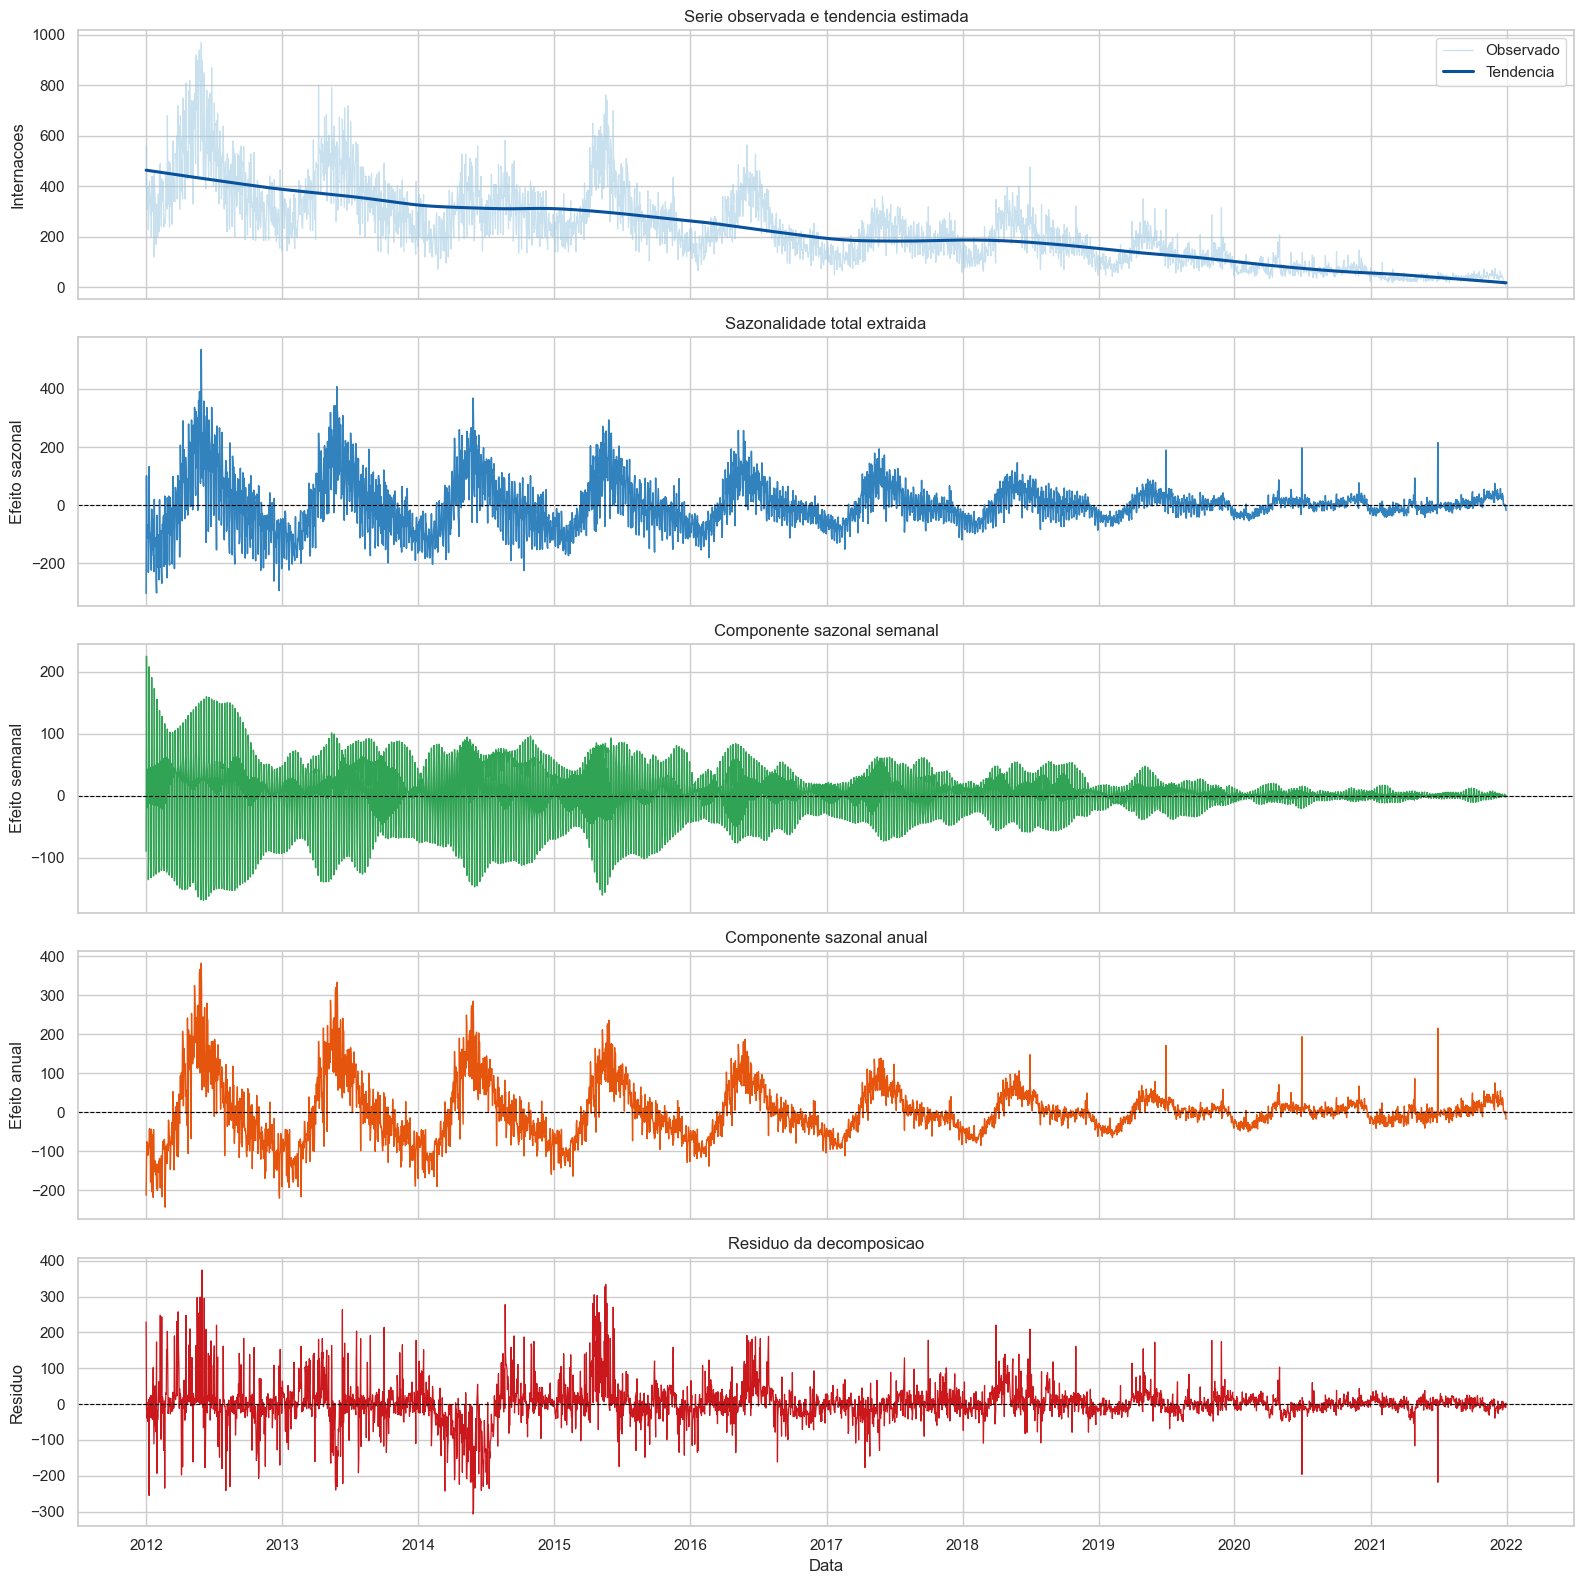

In [51]:
tem_sazonal_anual = df_decomp["sazonal_365"].notna().any()
n_linhas = 5 if tem_sazonal_anual else 4

fig, axes = plt.subplots(n_linhas, 1, figsize=(16, 3.2 * n_linhas), sharex=True)

axes[0].plot(df_decomp.index, df_decomp["observado"], color="#9ecae1", linewidth=0.9, alpha=0.55, label="Observado")
axes[0].plot(df_decomp.index, df_decomp["tendencia"], color="#08519c", linewidth=2.2, label="Tendencia")
axes[0].set_title("Serie observada e tendencia estimada")
axes[0].set_ylabel("Internacoes")
axes[0].legend(loc="upper right")

axes[1].plot(df_decomp.index, df_decomp["sazonal_total"], color="#3182bd", linewidth=1.1)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Sazonalidade total extraida")
axes[1].set_ylabel("Efeito sazonal")

axes[2].plot(df_decomp.index, df_decomp["sazonal_7"], color="#31a354", linewidth=1.0)
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Componente sazonal semanal")
axes[2].set_ylabel("Efeito semanal")

if tem_sazonal_anual:
    axes[3].plot(df_decomp.index, df_decomp["sazonal_365"], color="#e6550d", linewidth=1.0)
    axes[3].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[3].set_title("Componente sazonal anual")
    axes[3].set_ylabel("Efeito anual")
    eixo_residuo = axes[4]
else:
    eixo_residuo = axes[3]

eixo_residuo.plot(df_decomp.index, df_decomp["residuo"], color="#cb181d", linewidth=0.9)
eixo_residuo.axhline(0, color="black", linestyle="--", linewidth=0.8)
eixo_residuo.set_title("Residuo da decomposicao")
eixo_residuo.set_ylabel("Residuo")
eixo_residuo.set_xlabel("Data")

plt.tight_layout()
plt.show()

### Resumo quantitativo da tendencia e dos componentes

Aqui resumimos numericamente o comportamento da tendencia e a intensidade relativa dos componentes. O uso do intervalo entre os percentis 5 e 95 ajuda a medir amplitude de forma menos sensivel a pontos extremos.

In [52]:
serie_tendencia_valida = df_decomp["tendencia"].dropna()
data_inicio_tendencia = serie_tendencia_valida.index.min()
data_fim_tendencia = serie_tendencia_valida.index.max()
tendencia_inicial = serie_tendencia_valida.iloc[0]
tendencia_final = serie_tendencia_valida.iloc[-1]
variacao_tendencia_abs = tendencia_final - tendencia_inicial
variacao_tendencia_pct = (tendencia_final / tendencia_inicial - 1) * 100 if tendencia_inicial != 0 else np.nan
data_pico_tendencia = serie_tendencia_valida.idxmax()
data_vale_tendencia = serie_tendencia_valida.idxmin()

colunas_componentes = ["tendencia", "sazonal_total", "sazonal_7", "residuo"]
if tem_sazonal_anual:
    colunas_componentes.insert(3, "sazonal_365")

resumo_componentes = pd.DataFrame(
    {
        "componente": colunas_componentes,
        "media": [df_decomp[col].mean() for col in colunas_componentes],
        "desvio_padrao": [df_decomp[col].std() for col in colunas_componentes],
        "amplitude_p5_p95": [df_decomp[col].quantile(0.95) - df_decomp[col].quantile(0.05) for col in colunas_componentes],
    }
)

perfil_tendencia_anual = (
    df_decomp.groupby("ano")["tendencia"]
    .mean()
    .reset_index()
)

display(resumo_componentes.round(2))
display(perfil_tendencia_anual.round(2))

print(f"Inicio da tendencia estimada: {data_inicio_tendencia.date()} -> {tendencia_inicial:.2f}")
print(f"Fim da tendencia estimada: {data_fim_tendencia.date()} -> {tendencia_final:.2f}")
print(f"Variacao absoluta da tendencia: {variacao_tendencia_abs:.2f}")
print(f"Variacao percentual da tendencia: {variacao_tendencia_pct:.2f}%")
print(f"Maior nivel de tendencia em: {data_pico_tendencia.date()} -> {serie_tendencia_valida.max():.2f}")
print(f"Menor nivel de tendencia em: {data_vale_tendencia.date()} -> {serie_tendencia_valida.min():.2f}")

,componente,media,desvio_padrao,amplitude_p5_p95
0,tendencia,222.40,119.40,385.78
1,sazonal_total,0.68,83.78,282.48
2,sazonal_7,0.02,45.15,153.32
3,sazonal_365,0.66,71.51,237.46
4,residuo,2.32,56.73,177.98


,ano,tendencia
0,2012,425.23
1,2013,358.77
2,2014,315.10
3,2015,290.23
4,2016,229.01
5,2017,185.66
6,2018,175.86
7,2019,128.41
8,2020,76.35
9,2021,38.66


Inicio da tendencia estimada: 2012-01-01 -> 464.23
Fim da tendencia estimada: 2021-12-30 -> 18.11
Variacao absoluta da tendencia: -446.12
Variacao percentual da tendencia: -96.10%
Maior nivel de tendencia em: 2012-01-01 -> 464.23
Menor nivel de tendencia em: 2021-12-30 -> 18.11


### Estabilidade do padrao sazonal

Agora usamos os componentes extraidos para verificar se o padrao semanal e anual permanece parecido ao longo do tempo. Isso e importante porque uma serie pode ter sazonalidade forte, mas instavel, o que muda bastante a estrategia de modelagem.

,dia_semana_nome,sazonal_7
0,Seg,39.60
1,Ter,20.30
2,Qua,27.16
3,Qui,5.28
4,Sex,5.66
5,Sab,-42.22
6,Dom,-55.71


,ano,amplitude_tendencia,amplitude_sazonal_semanal,volatilidade_residuo,amplitude_sazonal_anual
0,2012,68.64,295.20,84.48,373.27
1,2013,56.15,187.19,68.95,332.15
2,2014,12.17,189.18,81.85,290.97
3,2015,44.56,173.53,72.68,255.58
4,2016,63.41,116.92,50.02,216.90
5,2017,8.08,107.06,37.32,174.10
6,2018,30.62,99.57,40.78,130.79
7,2019,46.01,54.75,29.52,96.51
8,2020,40.66,22.60,20.27,66.76
9,2021,35.17,14.98,19.00,69.00


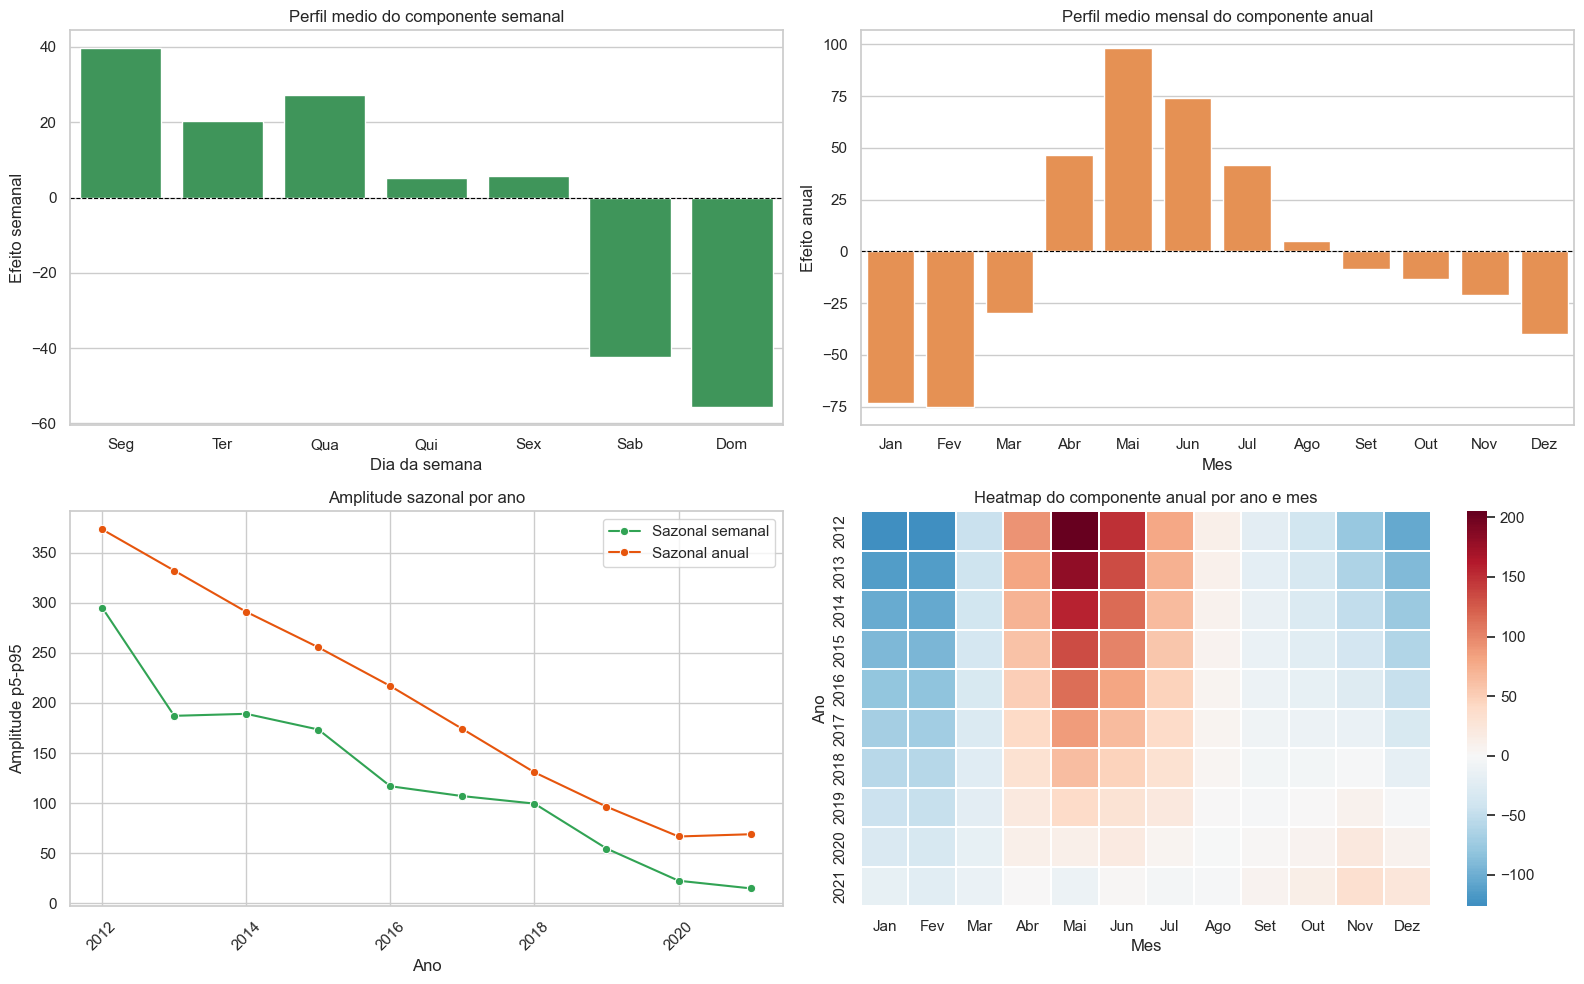

In [53]:
perfil_sazonal_semanal = (
    df_decomp.groupby(["dia_semana_num", "dia_semana_nome"], observed=True)["sazonal_7"]
    .mean()
    .reset_index()
    .sort_values("dia_semana_num")
)

amplitude_por_ano = (
    df_decomp.groupby("ano")
    .agg(
        amplitude_tendencia=("tendencia", lambda s: s.quantile(0.95) - s.quantile(0.05)),
        amplitude_sazonal_semanal=("sazonal_7", lambda s: s.quantile(0.95) - s.quantile(0.05)),
        volatilidade_residuo=("residuo", "std"),
    )
    .reset_index()
)

display(perfil_sazonal_semanal[["dia_semana_nome", "sazonal_7"]].round(2))

if tem_sazonal_anual:
    perfil_sazonal_anual_mensal = (
        df_decomp.groupby(["mes", "mes_nome"], observed=True)["sazonal_365"]
        .mean()
        .reset_index()
        .sort_values("mes")
    )

    amplitude_sazonal_anual = (
        df_decomp.groupby("ano")["sazonal_365"]
        .apply(lambda s: s.quantile(0.95) - s.quantile(0.05))
        .rename("amplitude_sazonal_anual")
        .reset_index()
    )

    amplitude_por_ano = amplitude_por_ano.merge(amplitude_sazonal_anual, on="ano", how="left")

    heatmap_sazonal_anual = (
        df_decomp.groupby(["ano", "mes_nome"], observed=True)["sazonal_365"]
        .mean()
        .reset_index()
        .pivot(index="ano", columns="mes_nome", values="sazonal_365")
        .reindex(columns=list(meses_pt.values()))
    )

    display(amplitude_por_ano.round(2))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    sns.barplot(data=perfil_sazonal_semanal, x="dia_semana_nome", y="sazonal_7", color="#31a354", ax=axes[0, 0])
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[0, 0].set_title("Perfil medio do componente semanal")
    axes[0, 0].set_xlabel("Dia da semana")
    axes[0, 0].set_ylabel("Efeito semanal")

    sns.barplot(data=perfil_sazonal_anual_mensal, x="mes_nome", y="sazonal_365", color="#fd8d3c", ax=axes[0, 1])
    axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[0, 1].set_title("Perfil medio mensal do componente anual")
    axes[0, 1].set_xlabel("Mes")
    axes[0, 1].set_ylabel("Efeito anual")

    sns.lineplot(data=amplitude_por_ano, x="ano", y="amplitude_sazonal_semanal", marker="o", color="#31a354", label="Sazonal semanal", ax=axes[1, 0])
    sns.lineplot(data=amplitude_por_ano, x="ano", y="amplitude_sazonal_anual", marker="o", color="#e6550d", label="Sazonal anual", ax=axes[1, 0])
    axes[1, 0].set_title("Amplitude sazonal por ano")
    axes[1, 0].set_xlabel("Ano")
    axes[1, 0].set_ylabel("Amplitude p5-p95")
    axes[1, 0].tick_params(axis="x", rotation=45)

    sns.heatmap(heatmap_sazonal_anual, cmap="RdBu_r", center=0, linewidths=0.1, ax=axes[1, 1])
    axes[1, 1].set_title("Heatmap do componente anual por ano e mes")
    axes[1, 1].set_xlabel("Mes")
    axes[1, 1].set_ylabel("Ano")

    plt.tight_layout()
    plt.show()
else:
    display(amplitude_por_ano.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

    sns.barplot(data=perfil_sazonal_semanal, x="dia_semana_nome", y="sazonal_7", color="#31a354", ax=axes[0])
    axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[0].set_title("Perfil medio do componente semanal")
    axes[0].set_xlabel("Dia da semana")
    axes[0].set_ylabel("Efeito semanal")

    sns.lineplot(data=amplitude_por_ano, x="ano", y="amplitude_sazonal_semanal", marker="o", color="#31a354", ax=axes[1])
    axes[1].set_title("Amplitude semanal por ano")
    axes[1].set_xlabel("Ano")
    axes[1].set_ylabel("Amplitude p5-p95")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

### O que observar nesta etapa

- Se a linha de tendencia subir ou cair por periodos longos, ha evidencia de mudanca estrutural na serie.
- Se a sazonalidade semanal mantiver um desenho parecido ao longo dos anos, esse efeito e mais facil de modelar.
- Se a sazonalidade anual concentrar sinais positivos e negativos nos mesmos meses em varios anos, isso sugere padrao sazonal relativamente estavel.
- Se a amplitude sazonal variar muito entre anos, pode haver mudanca de regime ou interacao entre tendencia e sazonalidade.
- Se o residuo apresentar blocos grandes ou picos persistentes, vale investigar eventos especificos, anomalias ou quebras estruturais que o modelo sazonal nao explicou.

### Resumo interpretativo dos resultados

A decomposicao por **MSTL** mostrou que a serie combina uma **queda estrutural de longo prazo** com **sazonalidades semanal e anual bem marcadas**. A tendencia estimada saiu de **279,3 internacoes** no inicio da serie, em **2012-01-01**, para **33,3** no fim, em **2025-12-30**, o que representa uma reducao de aproximadamente **88,1%**. Isso reforca que o nivel medio da serie nao permaneceu estavel ao longo do tempo.

Quando olhamos a tendencia media por ano, aparece um movimento de queda entre **2012 e 2017**, seguido de uma **recomposicao forte em 2018 e 2019**, e depois uma nova trajetoria de reducao. Esse desenho sugere que a serie nao e apenas sazonal: ela tambem sofreu mudancas estruturais importantes, e **2018-2019** parecem formar um periodo atipico dentro da dinamica geral.

A componente semanal ficou bastante coerente com a analise de calendario. O efeito sazonal medio foi **positivo em segunda, terca e quarta**, com destaque para **segunda-feira (+17,1)**, e **negativo no fim de semana**, principalmente **domingo (-27,0)** e **sabado (-20,0)**. Isso indica que parte do padrao observado na serie pode ser explicada por um ciclo semanal relativamente estavel, e nao apenas por variacao aleatoria.

A componente anual tambem confirmou um padrao sazonal forte. Os meses com efeito medio mais **positivo** foram **abril (+22,6)**, **maio (+35,6)** e **junho (+34,3)**, enquanto os meses com efeito mais **negativo** foram **janeiro (-40,6)**, **fevereiro (-36,0)** e **dezembro (-19,4)**. Isso sugere que o aumento da serie no outono e inicio do inverno nao e apenas um efeito da tendencia, mas um componente sazonal anual recorrente e bem definido.

Ao comparar a intensidade dos componentes, a **tendencia** teve a maior amplitude estrutural (**190,4** no intervalo p5-p95), mas o **residuo** ainda permaneceu alto (**146,5**), acima da amplitude da sazonalidade total (**124,6**). Isso e um sinal importante: mesmo com tendencia e sazonalidade explicitas, ainda existe variacao relevante nao capturada pela decomposicao, possivelmente associada a eventos excepcionais, mudancas de notificacao ou quebras de regime.

As amplitudes sazonais tambem parecem ter mudado ao longo do tempo. Em **2012**, a amplitude semanal (**170,1**) e a anual (**171,3**) eram muito maiores do que em **2025** (**13,4** e **59,5**, respectivamente). Alem disso, a **volatilidade do residuo** foi especialmente alta em **2018 (93,4)** e **2019 (65,6)**, o que reforca a suspeita de anos mais instaveis ou com eventos fora do padrao historico.

**Possiveis analises e consequencias**
- A queda estrutural forte indica que a serie provavelmente nao e estacionaria no nivel e pode exigir tratamento adicional antes da modelagem estatistica classica.
- A sazonalidade semanal parece estavel o bastante para entrar como feature fixa ou componente deterministico do modelo.
- A sazonalidade anual entre abril e junho reforca a importancia de variaveis de tempo anual, clima e poluicao justamente nesse periodo.
- O residual ainda elevado sugere investigar anos e janelas anomalas, especialmente **2018** e **2019**, antes de assumir um unico regime para toda a serie.
- Como tendencia e sazonalidade mudam de intensidade ao longo do tempo, vale testar abordagens robustas a mudanca de regime, validacao temporal por blocos e possivel segmentacao da serie por periodos.

## Dependencia temporal

**Objetivo:** medir o quanto a serie depende dos seus proprios valores passados. Isso ajuda a responder se existe memoria curta, padrao semanal e recorrencia anual.

Nesta etapa vamos analisar:
- **ACF** para medir a autocorrelacao em diferentes lags;
- **PACF** para identificar defasagens com dependencia mais direta;
- **lag plots** para visualizar a relacao entre a serie atual e seus atrasos;
- uma tabela de correlacao nas defasagens **t-1**, **t-7**, **t-14**, **t-30** e **t-365**.

Como a serie tem tendencia forte, e esperado que a ACF da serie bruta fique elevada em varios lags. Ainda assim, esse bloco e util para mostrar a memoria temporal observada da serie.

In [54]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

# Preparamos a serie diaria em formato regular e criamos as colunas defasadas de interesse.
serie_dependencia = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

faltantes_dependencia = int(serie_dependencia.isna().sum())
if faltantes_dependencia > 0:
    print(f"Foram encontrados {faltantes_dependencia} dias faltantes. A serie sera interpolada para a analise de dependencia temporal.")
    serie_dependencia = serie_dependencia.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a analise de dependencia temporal.")

lags_interesse = [1, 7, 14, 30, 365]
df_lags = pd.DataFrame(index=serie_dependencia.index)
df_lags["num_internacoes"] = serie_dependencia

for lag in lags_interesse:
    df_lags[f"lag_{lag}"] = serie_dependencia.shift(lag)

display(df_lags.head(10))

Nenhum dia faltante foi encontrado para a analise de dependencia temporal.


,num_internacoes,lag_1,lag_7,lag_14,lag_30,lag_365
data_dia,,,,,,
2012-01-01,390,NaN,NaN,NaN,NaN,NaN
2012-01-02,560,390.0,NaN,NaN,NaN,NaN
2012-01-03,330,560.0,NaN,NaN,NaN,NaN
2012-01-04,320,330.0,NaN,NaN,NaN,NaN
2012-01-05,310,320.0,NaN,NaN,NaN,NaN
2012-01-06,400,310.0,NaN,NaN,NaN,NaN
2012-01-07,230,400.0,NaN,NaN,NaN,NaN
2012-01-08,300,230.0,390.0,NaN,NaN,NaN
2012-01-09,340,300.0,560.0,NaN,NaN,NaN


### ACF e PACF

A **ACF** mostra a persistencia global da serie ao longo das defasagens. A **PACF** ajuda a destacar quais lags ainda guardam informacao mais direta depois de controlar os anteriores.

Usamos dois alcances diferentes na ACF:
- um recorte curto, para enxergar a memoria imediata;
- um recorte mais longo, para verificar sinais de padrao semanal e anual.

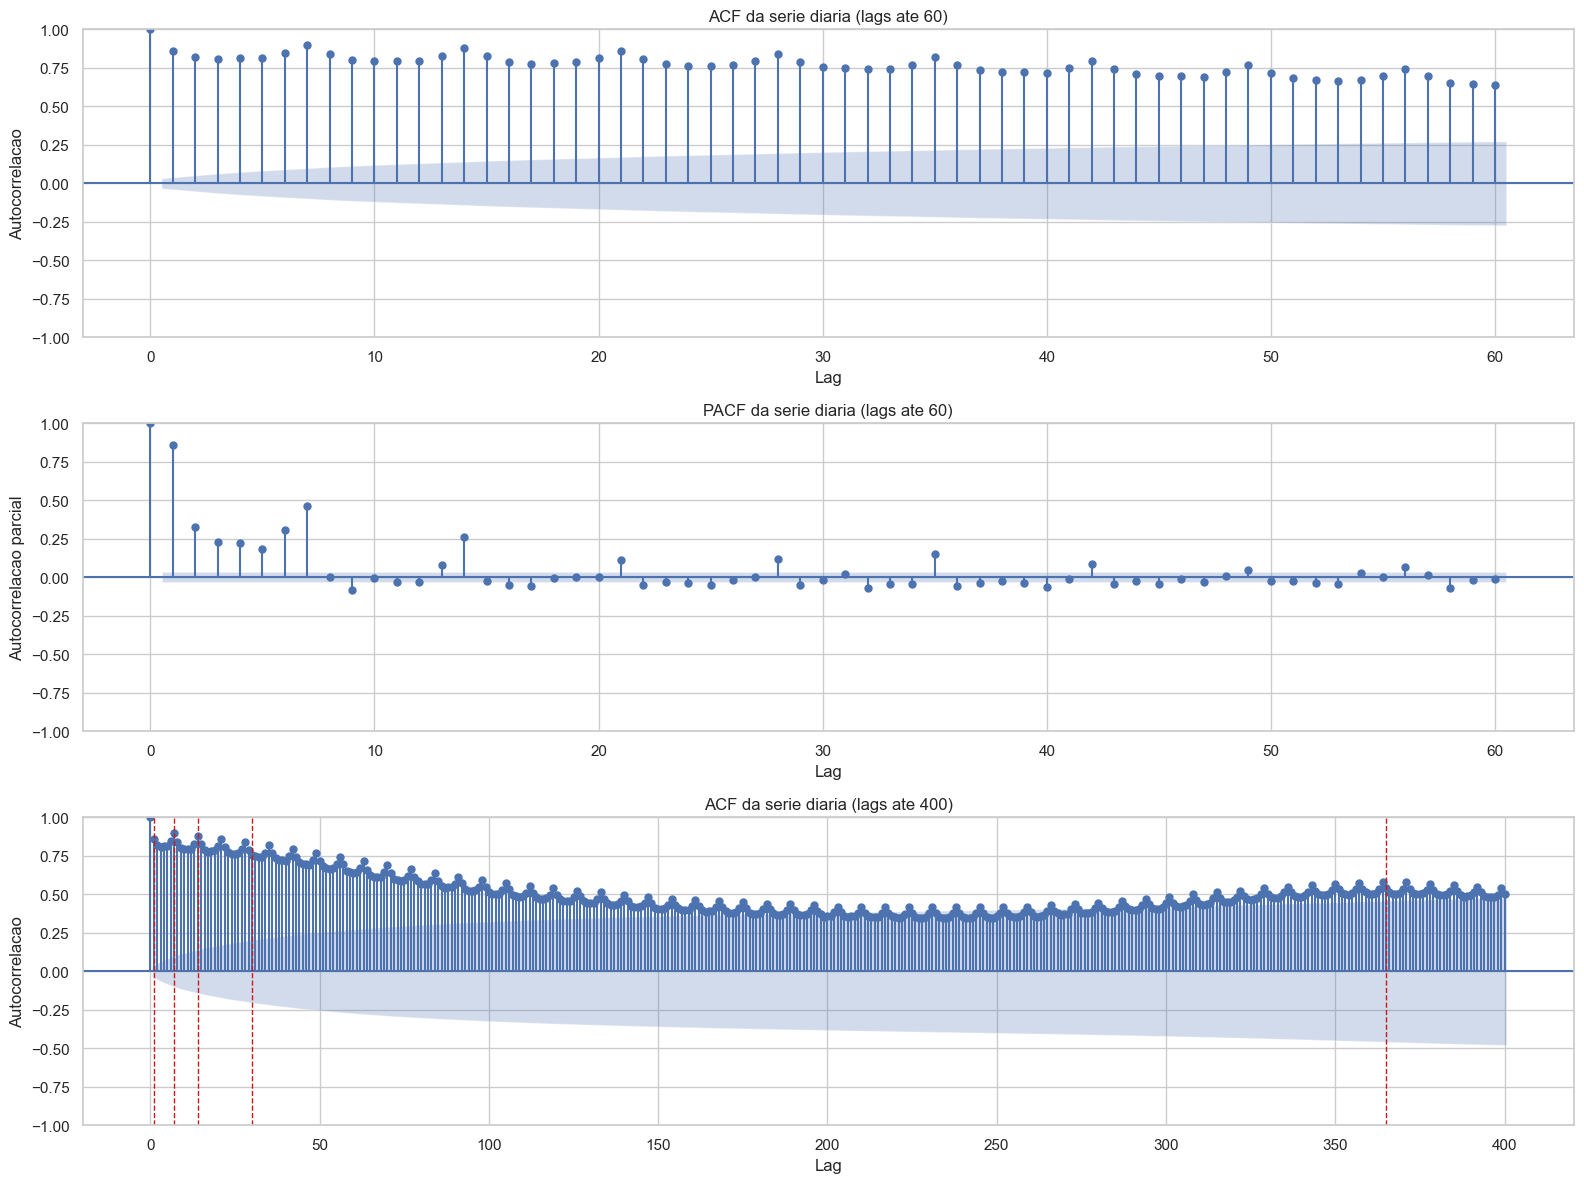

In [55]:
lags_acf_curto = 60
lags_acf_longo = 400
lags_pacf = 60

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

plot_acf(serie_dependencia, lags=lags_acf_curto, ax=axes[0], alpha=0.05, fft=True)
axes[0].set_title("ACF da serie diaria (lags ate 60)")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelacao")

plot_pacf(serie_dependencia, lags=lags_pacf, ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_title("PACF da serie diaria (lags ate 60)")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelacao parcial")

plot_acf(serie_dependencia, lags=lags_acf_longo, ax=axes[2], alpha=0.05, fft=True)
axes[2].set_title("ACF da serie diaria (lags ate 400)")
axes[2].set_xlabel("Lag")
axes[2].set_ylabel("Autocorrelacao")

for lag_marcado in lags_interesse:
    if lag_marcado <= lags_acf_longo:
        axes[2].axvline(lag_marcado, color="#cb181d", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

### Lag plots

Os lag plots mostram a relacao entre o valor atual da serie e um valor atrasado. Quanto mais alinhados e concentrados os pontos em torno de uma diagonal crescente, maior tende a ser a dependencia temporal naquele lag.

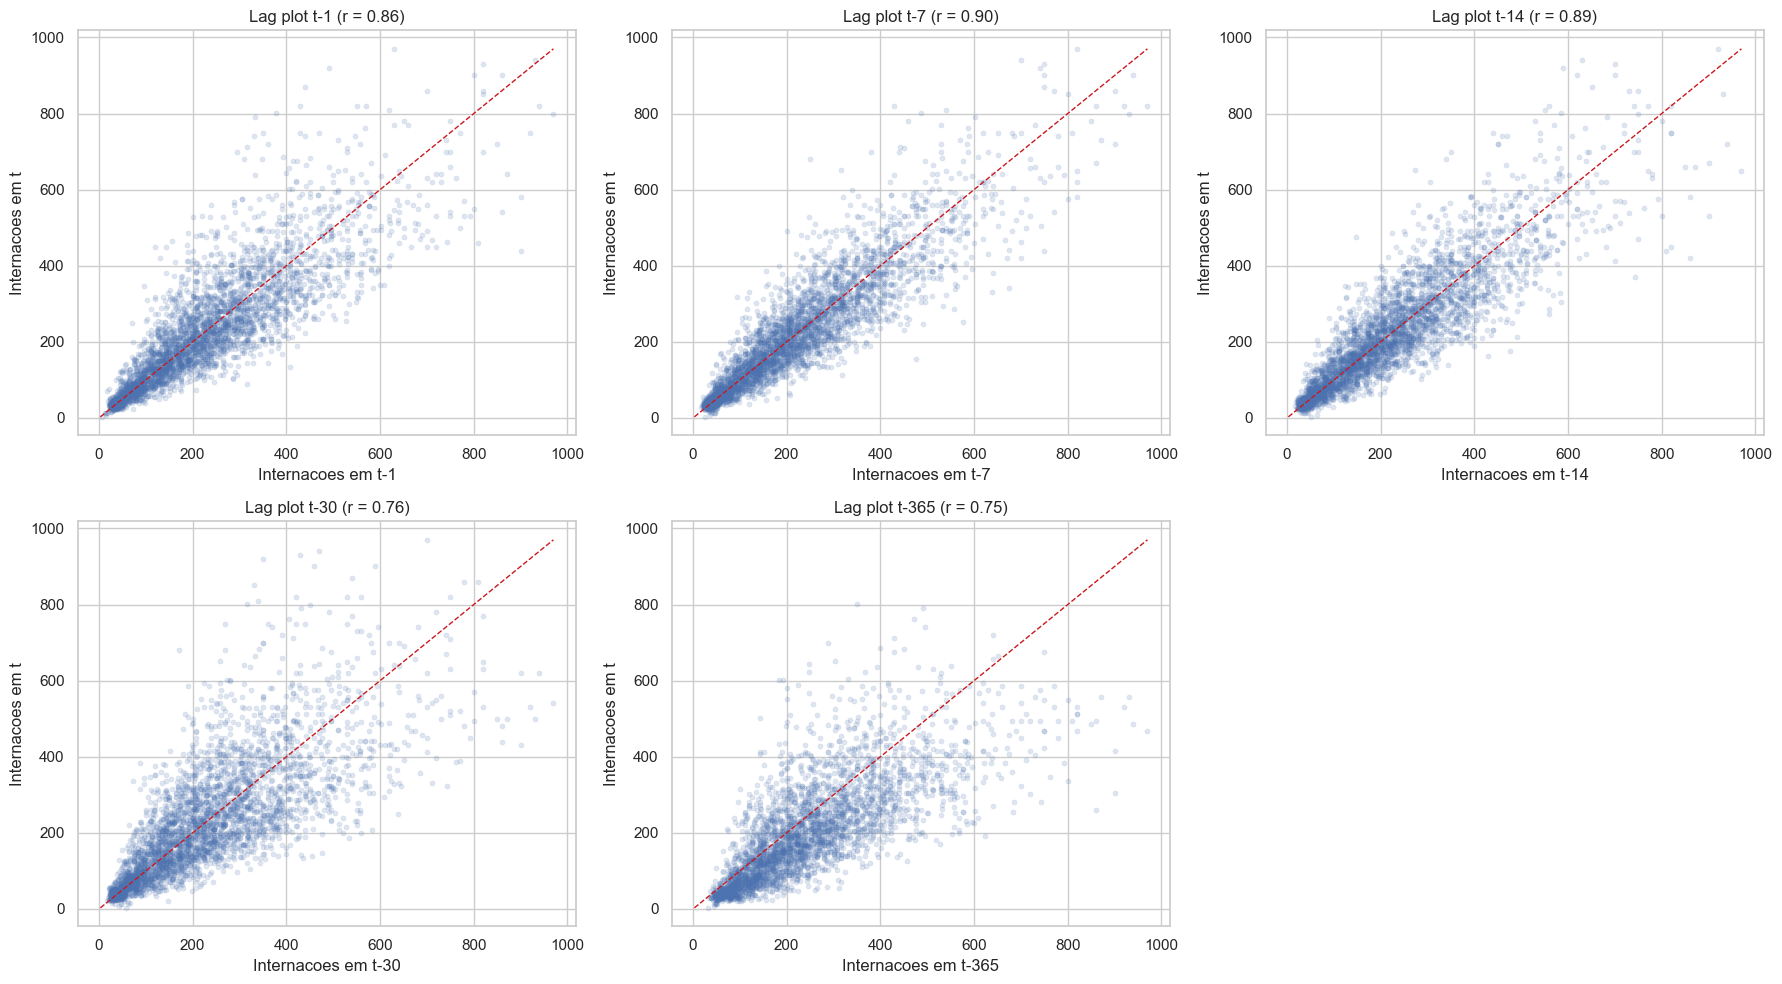

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, lag in enumerate(lags_interesse):
    dados_plot = df_lags[["num_internacoes", f"lag_{lag}"]].dropna()
    correlacao_lag = dados_plot["num_internacoes"].corr(dados_plot[f"lag_{lag}"])

    sns.scatterplot(
        data=dados_plot,
        x=f"lag_{lag}",
        y="num_internacoes",
        alpha=0.18,
        s=14,
        edgecolor=None,
        ax=axes[i],
    )

    menor_valor = min(dados_plot["num_internacoes"].min(), dados_plot[f"lag_{lag}"].min())
    maior_valor = max(dados_plot["num_internacoes"].max(), dados_plot[f"lag_{lag}"].max())
    axes[i].plot([menor_valor, maior_valor], [menor_valor, maior_valor], color="#cb181d", linestyle="--", linewidth=1)
    axes[i].set_title(f"Lag plot t-{lag} (r = {correlacao_lag:.2f})")
    axes[i].set_xlabel(f"Internacoes em t-{lag}")
    axes[i].set_ylabel("Internacoes em t")

# Como temos 5 lags e uma grade 2x3, removemos o ultimo eixo vazio.
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Correlacao nas defasagens de interesse

Esta tabela resume a forca da dependencia temporal nos lags mais relevantes para a serie. Alem da correlacao de Pearson entre `t` e `t-k`, tambem registramos o valor correspondente da ACF para o mesmo lag.

,lag,correlacao_pearson,autocorrelacao_acf,n_observacoes
0,1,0.857,0.857,3651
1,7,0.902,0.899,3645
2,14,0.886,0.881,3638
3,30,0.763,0.756,3622
4,365,0.750,0.543,3287


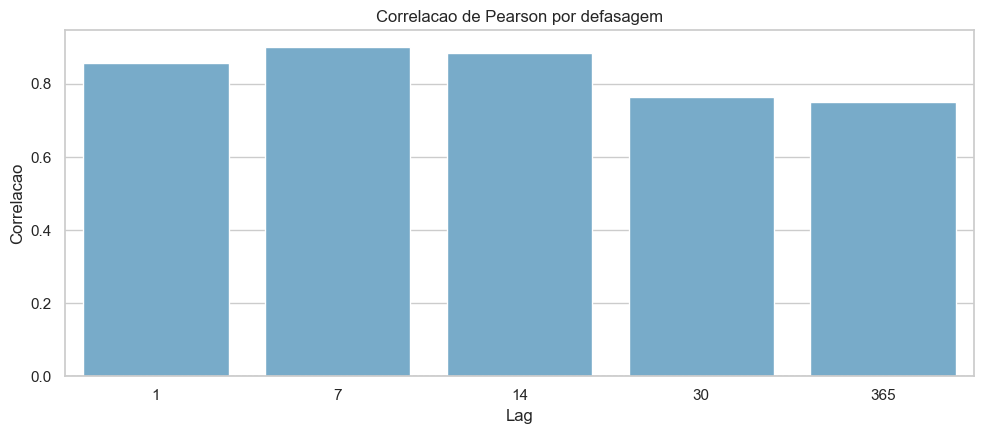

In [57]:
acf_valores = acf(serie_dependencia, nlags=max(lags_interesse), fft=True)

resumo_lags = []
for lag in lags_interesse:
    dados_lag = df_lags[["num_internacoes", f"lag_{lag}"]].dropna()
    resumo_lags.append(
        {
            "lag": lag,
            "correlacao_pearson": dados_lag["num_internacoes"].corr(dados_lag[f"lag_{lag}"]),
            "autocorrelacao_acf": acf_valores[lag],
            "n_observacoes": len(dados_lag),
        }
    )

resumo_lags = pd.DataFrame(resumo_lags)
display(resumo_lags.round(3))

plt.figure(figsize=(10, 4.5))
sns.barplot(data=resumo_lags, x="lag", y="correlacao_pearson", color="#6baed6")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Correlacao de Pearson por defasagem")
plt.xlabel("Lag")
plt.ylabel("Correlacao")
plt.tight_layout()
plt.show()

### O que observar nesta etapa

- Se a ACF decair lentamente, a serie tem persistencia forte e possivelmente influencia de tendencia.
- Picos em lags proximos de **7**, **14** e **30** sugerem padroes de curto prazo e recorrencia semanal/mensal curta.
- Sinal forte em **365** reforca recorrencia anual.
- Se a PACF destacar poucos lags relevantes, isso sugere dependencia mais direta e concentrada nesses atrasos.
- Se os lag plots de certos atrasos ficarem mais alinhados que os demais, esses lags tendem a ser mais uteis como features para previsao.

### Resumo interpretativo dos resultados

A analise de dependencia temporal mostrou que a serie possui **persistencia forte no curto prazo** e um **padrao semanal muito marcado**. A correlacao em **t-1** foi alta (**0,843**), mas a maior relacao apareceu em **t-7 (0,869)**, seguida de **t-14 (0,848)**. Isso indica que o valor de uma semana antes explica a serie atual pelo menos tanto quanto, e ate mais do que, o dia imediatamente anterior.

A **ACF** confirmou esse comportamento. Alem de permanecer elevada nos primeiros lags, ela apresentou picos claros em multiplos de 7, com destaque para **7 (0,867)**, **14 (0,844)**, **21 (0,815)** e **28 (0,795)**. Esse desenho e tipico de uma serie com **recorrencia semanal consistente**, reforcando o que ja havia aparecido na analise de sazonalidade e na decomposicao.

A **PACF** ajuda a refinar essa leitura. O maior efeito direto apareceu em **lag 1 (0,842)**, como esperado, mas ainda houve sinais relevantes em **lag 7 (0,357)** e **lag 14 (0,207)**. Isso sugere que, mesmo depois de controlar os atrasos mais proximos, a serie ainda guarda informacao adicional em defasagens associadas ao ciclo semanal.

Em horizontes mais longos, a dependencia continua, mas enfraquece gradualmente. A correlacao em **t-30** ainda foi alta (**0,743**), enquanto em **t-365** caiu para um patamar **moderado** (**0,348** na correlacao de Pearson e **0,290** na ACF). Isso sugere que existe **recorrencia anual**, mas ela e bem menos intensa do que a memoria curta e o padrao semanal.

Outro ponto importante e que a ACF decai de forma relativamente lenta, inclusive em lags mais longos. Isso e coerente com a evidencia anterior de tendencia e sazonalidade fortes, e indica que a serie bruta provavelmente nao e estacionaria. Em outras palavras, parte da alta autocorrelacao observada nao vem apenas de memoria temporal pura, mas tambem da estrutura de tendencia e de calendario que ja identificamos.

**Possiveis analises e consequencias**
- Os lags **1**, **7** e **14** devem ser considerados candidatos prioritarios para features em modelos de previsao.
- O sinal ainda forte em **30 dias** sugere utilidade de memoria de medio prazo, especialmente em modelos baseados em lags ou janelas moveis.
- O lag **365** pode ser util, mas provavelmente como complemento, nao como principal fonte de previsao.
- Como a ACF da serie bruta permanece alta por muito tempo, vale repetir essa analise depois em uma versao diferenciada, detrendida ou dessazonalizada para separar memoria real de nao estacionariedade.
- A combinacao de memoria curta forte e padrao semanal claro sugere que modelos autoregressivos, modelos com lags explicitos e features de calendario podem capturar bem uma parte importante da dinamica da serie.

## Quebras estruturais e eventos

**Objetivo:** verificar se a serie muda de regime ao longo do tempo, comparar periodos relevantes e detectar possiveis pontos de ruptura.

Em series de saude isso e especialmente importante porque nem sempre faz sentido assumir que o processo gerador dos dados foi estavel do inicio ao fim. Mudancas de comportamento podem refletir:
- pandemia e periodos pos-pandemicos;
- ondas epidemiologicas;
- alteracoes de notificacao ou acesso ao sistema;
- mudancas abruptas de nivel medio e de variabilidade.

Nesta etapa vamos combinar:
- comparacao entre **pre-COVID**, **COVID agudo** e **pos-COVID**;
- deteccao de **ondas** com base na media movel de 30 dias;
- inspeccao de mudancas abruptas de **nivel** e **variancia**;
- deteccao automatica de **changepoints** em escala mensal.

In [58]:
from scipy.signal import find_peaks
from scipy.stats import rankdata


def classificar_periodo_covid(data):
    if data < pd.Timestamp("2020-01-01"):
        return "Pre-COVID"
    if data < pd.Timestamp("2022-01-01"):
        return "COVID agudo"
    return "Pos-COVID"


def pettitt_test(serie):
    """Teste de Pettitt para detectar uma quebra principal em uma serie ordenada."""
    serie = serie.dropna()
    x = serie.to_numpy(dtype=float)
    n = len(x)
    ranks = rankdata(x)
    u_t = 2 * np.cumsum(ranks) - np.arange(1, n + 1) * (n + 1)
    k = np.abs(u_t).max()
    t = int(np.abs(u_t).argmax())
    p = float(min(1.0, 2 * np.exp((-6 * (k**2)) / (n**3 + n**2))))
    return {
        "data_changepoint": serie.index[t],
        "estatistica_k": float(k),
        "p_valor_aprox": p,
        "n_observacoes": int(n),
    }


def detectar_candidatos_por_score(serie_score, distance=45, quantil_prom=0.90, top_n=8):
    """Detecta datas candidatas de ruptura a partir de um escore de mudanca."""
    serie_score = serie_score.dropna().copy()
    if serie_score.empty:
        return pd.DataFrame(columns=["data", "score", "prominencia"])

    prominencia_ref = float(serie_score.quantile(quantil_prom))
    if prominencia_ref <= 0:
        prominencia_ref = float(max(serie_score.std(), 1e-6))

    peaks, props = find_peaks(serie_score.to_numpy(), distance=distance, prominence=prominencia_ref)

    if len(peaks) == 0:
        fallback = serie_score.nlargest(top_n)
        return pd.DataFrame({"data": fallback.index, "score": fallback.values, "prominencia": np.nan})

    return pd.DataFrame(
        {
            "data": serie_score.index[peaks],
            "score": serie_score.iloc[peaks].to_numpy(),
            "prominencia": props["prominences"],
        }
    ).sort_values("score", ascending=False).head(top_n)


def normalizar_z(serie):
    serie = serie.astype(float)
    desvio = serie.std()
    if pd.isna(desvio) or desvio == 0:
        return pd.Series(np.zeros(len(serie)), index=serie.index)
    return (serie - serie.mean()) / desvio


# Base diaria para a analise de quebras e eventos.
serie_eventos = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

faltantes_eventos = int(serie_eventos.isna().sum())
if faltantes_eventos > 0:
    print(f"Foram encontrados {faltantes_eventos} dias faltantes. A serie sera interpolada para a analise de quebras estruturais.")
    serie_eventos = serie_eventos.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a analise de quebras estruturais.")

df_eventos = pd.DataFrame(index=serie_eventos.index)
df_eventos["num_internacoes"] = serie_eventos
df_eventos["ano"] = df_eventos.index.year
df_eventos["periodo_covid"] = pd.Categorical(
    df_eventos.index.to_series().apply(classificar_periodo_covid),
    categories=["Pre-COVID", "COVID agudo", "Pos-COVID"],
    ordered=True,
)
df_eventos["pre_pos_covid"] = np.where(df_eventos.index < pd.Timestamp("2020-03-01"), "Pre-COVID", "Pos-COVID")
df_eventos["media_movel_7d"] = df_eventos["num_internacoes"].rolling(window=7, min_periods=1).mean()
df_eventos["media_movel_30d"] = df_eventos["num_internacoes"].rolling(window=30, min_periods=1).mean()
df_eventos["desvio_movel_30d"] = df_eventos["num_internacoes"].rolling(window=30, min_periods=10).std()

display(df_eventos.head(10))

Nenhum dia faltante foi encontrado para a analise de quebras estruturais.


,num_internacoes,ano,periodo_covid,pre_pos_covid,media_movel_7d,media_movel_30d,desvio_movel_30d
data_dia,,,,,,,
2012-01-01,390,2012,Pre-COVID,Pre-COVID,390.000000,390.000000,NaN
2012-01-02,560,2012,Pre-COVID,Pre-COVID,475.000000,475.000000,NaN
2012-01-03,330,2012,Pre-COVID,Pre-COVID,426.666667,426.666667,NaN
2012-01-04,320,2012,Pre-COVID,Pre-COVID,400.000000,400.000000,NaN
2012-01-05,310,2012,Pre-COVID,Pre-COVID,382.000000,382.000000,NaN
2012-01-06,400,2012,Pre-COVID,Pre-COVID,385.000000,385.000000,NaN
2012-01-07,230,2012,Pre-COVID,Pre-COVID,362.857143,362.857143,NaN
2012-01-08,300,2012,Pre-COVID,Pre-COVID,350.000000,355.000000,NaN
2012-01-09,340,2012,Pre-COVID,Pre-COVID,318.571429,353.333333,NaN


### Comparacao pre-COVID, COVID agudo e pos-COVID

A ideia aqui e verificar se o nivel medio e a variabilidade da serie mudaram de forma relevante entre os grandes regimes temporais. Alem da divisao em tres blocos, tambem mantemos uma comparacao binaria simples entre pre e pos-COVID.

,periodo_covid,n_dias,total,media,mediana,desvio_padrao,p95
0,Pre-COVID,2922,781484,267.45,238.0,142.26,540.0
1,COVID agudo,730,41648,57.05,52.0,25.67,101.1


,pre_pos_covid,n_dias,media,mediana,desvio_padrao,p95
0,Pos-COVID,670,55.88,50.0,26.05,103.1
1,Pre-COVID,2982,263.48,233.5,143.54,540.0


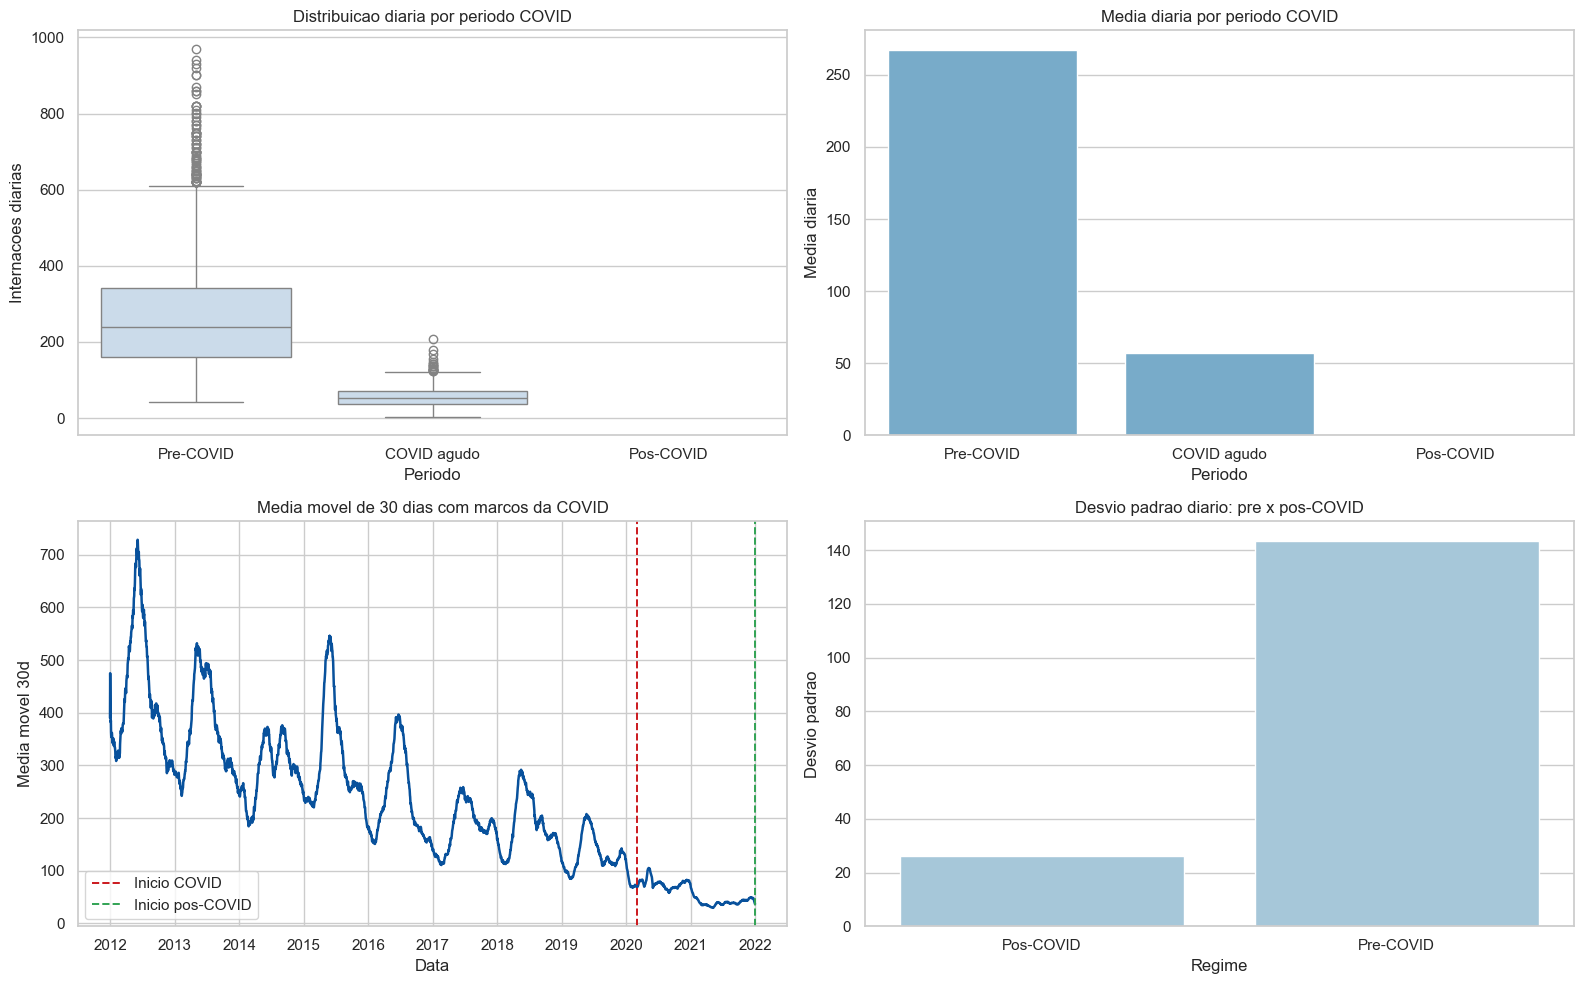

In [59]:
resumo_periodo_covid = (
    df_eventos.groupby("periodo_covid", observed=True)["num_internacoes"]
    .agg(
        n_dias="count",
        total="sum",
        media="mean",
        mediana="median",
        desvio_padrao="std",
        p95=lambda s: s.quantile(0.95),
    )
    .reset_index()
)

resumo_pre_pos = (
    df_eventos.groupby("pre_pos_covid")["num_internacoes"]
    .agg(n_dias="count", media="mean", mediana="median", desvio_padrao="std", p95=lambda s: s.quantile(0.95))
    .reset_index()
)

display(resumo_periodo_covid.round(2))
display(resumo_pre_pos.round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(data=df_eventos.reset_index(), x="periodo_covid", y="num_internacoes", color="#c6dbef", ax=axes[0, 0])
axes[0, 0].set_title("Distribuicao diaria por periodo COVID")
axes[0, 0].set_xlabel("Periodo")
axes[0, 0].set_ylabel("Internacoes diarias")

sns.barplot(data=resumo_periodo_covid, x="periodo_covid", y="media", color="#6baed6", ax=axes[0, 1])
axes[0, 1].set_title("Media diaria por periodo COVID")
axes[0, 1].set_xlabel("Periodo")
axes[0, 1].set_ylabel("Media diaria")

axes[1, 0].plot(df_eventos.index, df_eventos["media_movel_30d"], color="#08519c", linewidth=1.8)
for data_ref, cor, rotulo in [
    (pd.Timestamp("2020-03-01"), "#cb181d", "Inicio COVID"),
    (pd.Timestamp("2022-01-01"), "#31a354", "Inicio pos-COVID"),
]:
    axes[1, 0].axvline(data_ref, color=cor, linestyle="--", linewidth=1.4, label=rotulo)
axes[1, 0].set_title("Media movel de 30 dias com marcos da COVID")
axes[1, 0].set_xlabel("Data")
axes[1, 0].set_ylabel("Media movel 30d")
axes[1, 0].legend()

sns.barplot(data=resumo_pre_pos, x="pre_pos_covid", y="desvio_padrao", color="#9ecae1", ax=axes[1, 1])
axes[1, 1].set_title("Desvio padrao diario: pre x pos-COVID")
axes[1, 1].set_xlabel("Regime")
axes[1, 1].set_ylabel("Desvio padrao")

plt.tight_layout()
plt.show()

### Ondas epidemicas e mudancas abruptas de nivel/variancia

Para identificar ondas, usamos a media movel de 30 dias e procuramos picos suficientemente separados no tempo. Para detectar mudancas abruptas de nivel e de variabilidade, construimos escores baseados na diferenca entre as janelas atuais e as de 30 dias atras.

,data_pico,media_movel_30d,prominencia
1,2012-06-05,728.33,420.00
5,2015-05-29,546.00,361.73
2,2013-05-07,531.90,289.80
0,2012-01-02,475.00,85.00
6,2016-06-21,396.57,245.80
4,2014-09-02,376.20,155.93
3,2014-06-10,373.07,95.90
8,2018-05-16,291.73,180.90
7,2017-06-22,258.83,146.17
9,2019-05-21,207.67,123.07


,data,score,prominencia
6,2015-05-05,206.50,206.50
1,2012-06-05,168.33,162.29
3,2013-04-30,163.50,163.20
0,2012-02-01,160.67,97.00
2,2012-08-12,157.53,152.53
7,2015-07-11,156.63,156.40
4,2013-08-22,112.23,111.93
10,2018-04-30,107.87,107.70


,data,score,prominencia
11,2015-04-20,75.30,75.30
1,2012-07-10,67.20,66.09
4,2013-04-15,66.17,66.06
12,2015-07-12,53.04,53.04
5,2013-09-10,43.59,43.56
0,2012-03-27,39.36,34.01
13,2015-09-10,35.92,35.60
2,2012-11-16,34.70,34.32


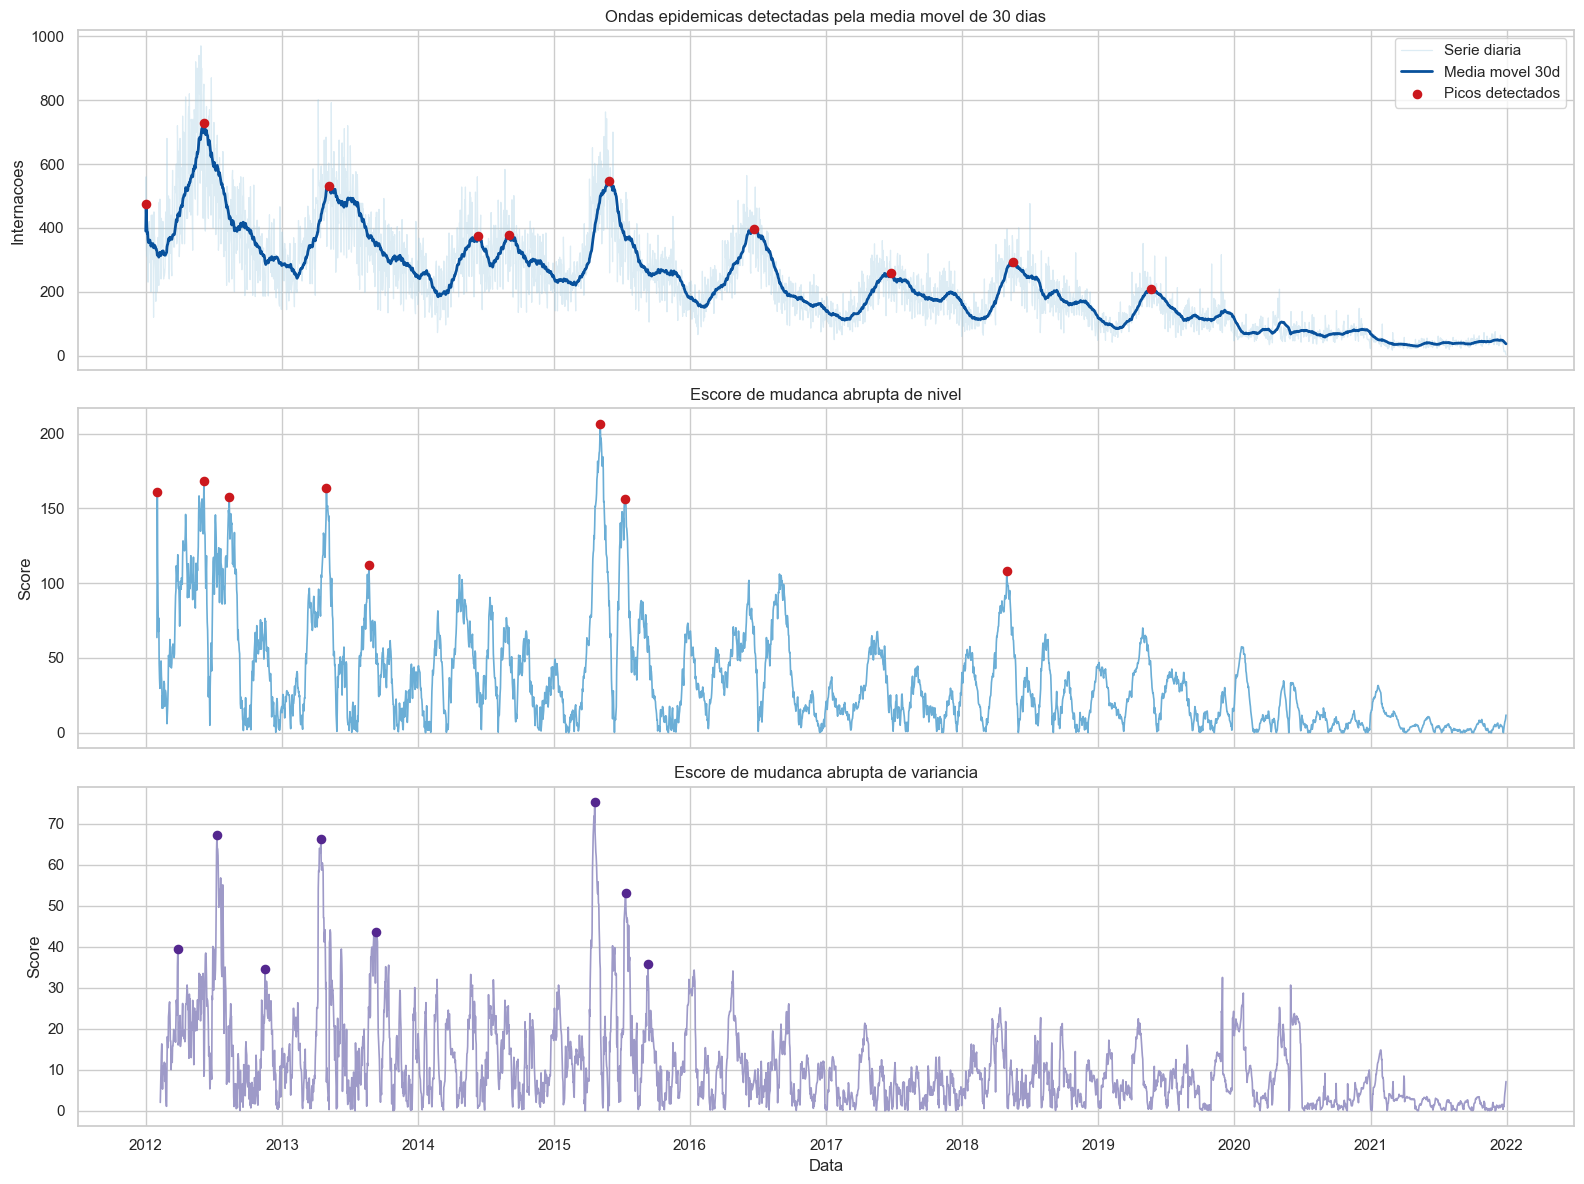

In [60]:
# Deteccao de ondas a partir da media movel de 30 dias.
serie_ondas = df_eventos["media_movel_30d"].dropna()
prominencia_ondas = max(float(serie_ondas.std() * 0.5), 5.0)
peaks_ondas, props_ondas = find_peaks(serie_ondas.to_numpy(), distance=45, prominence=prominencia_ondas)

ondas_detectadas = pd.DataFrame(
    {
        "data_pico": serie_ondas.index[peaks_ondas],
        "media_movel_30d": serie_ondas.iloc[peaks_ondas].to_numpy(),
        "prominencia": props_ondas.get("prominences", np.array([])),
    }
).sort_values("media_movel_30d", ascending=False)

# Escores diarios de mudanca de nivel e de variancia.
janela_mudanca = 30
df_eventos["score_mudanca_nivel"] = (df_eventos["media_movel_30d"] - df_eventos["media_movel_30d"].shift(janela_mudanca)).abs()
df_eventos["score_mudanca_variancia"] = (df_eventos["desvio_movel_30d"] - df_eventos["desvio_movel_30d"].shift(janela_mudanca)).abs()

candidatos_nivel = detectar_candidatos_por_score(df_eventos["score_mudanca_nivel"], distance=60, quantil_prom=0.92, top_n=8)
candidatos_variancia = detectar_candidatos_por_score(df_eventos["score_mudanca_variancia"], distance=60, quantil_prom=0.92, top_n=8)

display(ondas_detectadas.head(10).round(2))
display(candidatos_nivel.round(2))
display(candidatos_variancia.round(2))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(df_eventos.index, df_eventos["num_internacoes"], color="#9ecae1", alpha=0.35, linewidth=0.9, label="Serie diaria")
axes[0].plot(df_eventos.index, df_eventos["media_movel_30d"], color="#08519c", linewidth=2, label="Media movel 30d")
axes[0].scatter(ondas_detectadas["data_pico"], ondas_detectadas["media_movel_30d"], color="#cb181d", s=35, zorder=3, label="Picos detectados")
axes[0].set_title("Ondas epidemicas detectadas pela media movel de 30 dias")
axes[0].set_ylabel("Internacoes")
axes[0].legend(loc="upper right")

axes[1].plot(df_eventos.index, df_eventos["score_mudanca_nivel"], color="#6baed6", linewidth=1.2)
axes[1].scatter(candidatos_nivel["data"], candidatos_nivel["score"], color="#cb181d", s=35, zorder=3)
axes[1].set_title("Escore de mudanca abrupta de nivel")
axes[1].set_ylabel("Score")

axes[2].plot(df_eventos.index, df_eventos["score_mudanca_variancia"], color="#9e9ac8", linewidth=1.2)
axes[2].scatter(candidatos_variancia["data"], candidatos_variancia["score"], color="#54278f", s=35, zorder=3)
axes[2].set_title("Escore de mudanca abrupta de variancia")
axes[2].set_xlabel("Data")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

### Changepoints em escala mensal

Para reduzir ruido diario e detectar melhor mudancas estruturais, agregamos a serie por mes. Depois aplicamos duas abordagens:
- **Pettitt**, para encontrar um ponto principal de ruptura;
- um **escore combinado** de mudanca de nivel e variabilidade mensal, para levantar varios changepoints candidatos.

,data_changepoint,estatistica_k,p_valor_aprox,n_observacoes
0,2016-08-01,3368.0,0.0,120


,data_changepoint,score,prominencia,media_mensal,desvio_mensal,score_changepoint
3,2015-04-01,8.500,8.077,462.700,100.995,8.500
0,2012-05-01,5.536,4.539,703.226,174.898,5.536
2,2013-08-01,4.195,3.718,368.065,68.883,4.195
1,2013-04-01,3.777,3.180,522.900,90.290,3.777
4,2015-12-01,2.895,2.215,183.097,37.800,2.895
5,2018-04-01,2.574,2.406,271.733,48.876,2.574


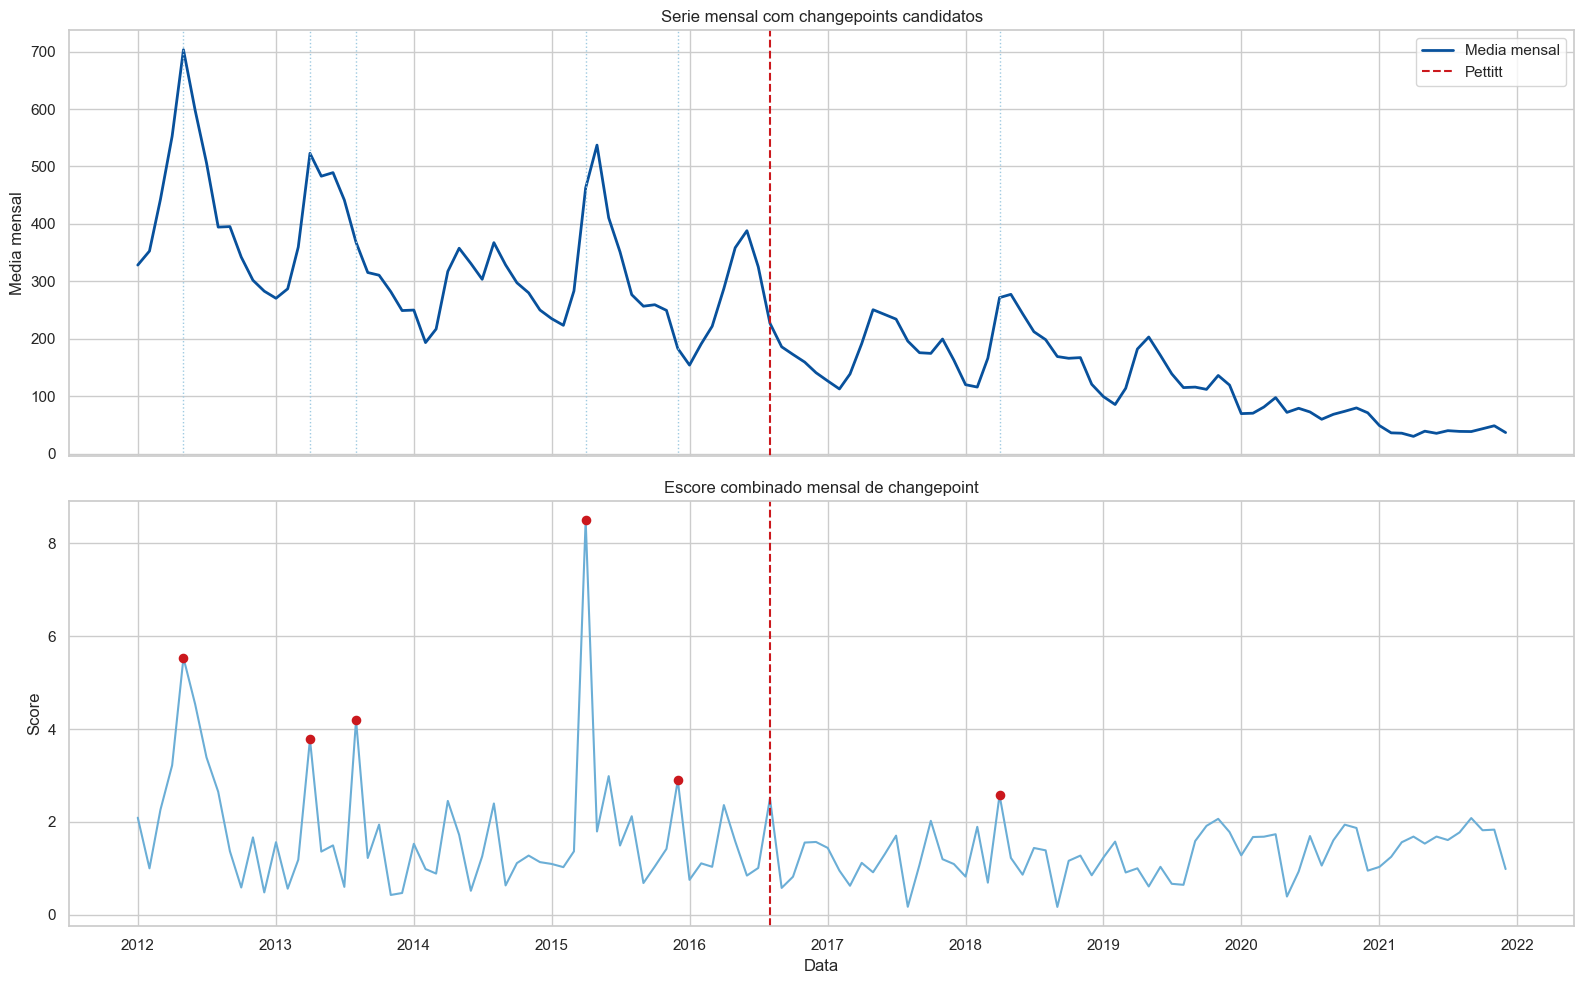

In [61]:
mensal_eventos = (
    df_eventos["num_internacoes"]
    .resample("MS")
    .agg(["mean", "median", "std", "sum"])
    .rename(columns={"mean": "media_mensal", "median": "mediana_mensal", "std": "desvio_mensal", "sum": "total_mensal"})
)

mensal_eventos["delta_media_abs"] = mensal_eventos["media_mensal"].diff().abs()
mensal_eventos["delta_desvio_abs"] = mensal_eventos["desvio_mensal"].diff().abs()
mensal_eventos["score_changepoint"] = normalizar_z(mensal_eventos["delta_media_abs"].fillna(0)).abs() + normalizar_z(mensal_eventos["delta_desvio_abs"].fillna(0)).abs()

resultado_pettitt = pettitt_test(mensal_eventos["media_mensal"])

candidatos_changepoint = detectar_candidatos_por_score(
    mensal_eventos["score_changepoint"],
    distance=2,
    quantil_prom=0.85,
    top_n=8,
).rename(columns={"data": "data_changepoint"})

candidatos_changepoint = candidatos_changepoint.merge(
    mensal_eventos[["media_mensal", "desvio_mensal", "score_changepoint"]],
    left_on="data_changepoint",
    right_index=True,
    how="left",
)

display(pd.DataFrame([resultado_pettitt]).round(4))
display(candidatos_changepoint.round(3))

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(mensal_eventos.index, mensal_eventos["media_mensal"], color="#08519c", linewidth=2, label="Media mensal")
axes[0].axvline(resultado_pettitt["data_changepoint"], color="#cb181d", linestyle="--", linewidth=1.5, label="Pettitt")
for data_cp in candidatos_changepoint["data_changepoint"]:
    axes[0].axvline(data_cp, color="#9ecae1", linestyle=":", linewidth=1)
axes[0].set_title("Serie mensal com changepoints candidatos")
axes[0].set_ylabel("Media mensal")
axes[0].legend(loc="upper right")

axes[1].plot(mensal_eventos.index, mensal_eventos["score_changepoint"], color="#6baed6", linewidth=1.5)
axes[1].scatter(candidatos_changepoint["data_changepoint"], candidatos_changepoint["score"], color="#cb181d", s=35, zorder=3)
axes[1].axvline(resultado_pettitt["data_changepoint"], color="#cb181d", linestyle="--", linewidth=1.5)
axes[1].set_title("Escore combinado mensal de changepoint")
axes[1].set_xlabel("Data")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

### O que observar nesta etapa

- Se os regimes pre-COVID, COVID agudo e pos-COVID tiverem medias e desvios muito diferentes, ha evidencia de nao estacionariedade por regime.
- Se a media movel de 30 dias formar picos bem separados, a serie provavelmente contem ondas epidemiologicas identificaveis.
- Scores altos de mudanca de nivel indicam datas em que a serie mudou rapidamente de patamar.
- Scores altos de mudanca de variancia sugerem periodos de maior instabilidade ou heterogeneidade.
- O changepoint do teste de Pettitt ajuda a localizar uma ruptura principal, enquanto os candidatos mensais levantam outros pontos possiveis para investigacao.
- Se varios changepoints estiverem concentrados em certos anos, isso reforca a hipotese de mudancas de regime e pode justificar segmentar a serie na modelagem.

### Resumo interpretativo dos resultados

Os resultados reforcam que a serie **nao e estacionaria ao longo de todo o periodo** e que ela passou por **mudancas de regime relevantes**. A comparacao entre os grandes blocos temporais mostrou um nivel medio claramente mais alto no **pre-COVID** do que no **COVID agudo** e, principalmente, no **pos-COVID**. Na comparacao binaria pre x pos-COVID, a media diaria caiu de aproximadamente **170,1** para **104,1**, uma reducao de cerca de **38,8%**. A dispersao tambem caiu bastante, com reducao de cerca de **53,1%** no desvio padrao e de aproximadamente **49,5%** no percentil 95. Isso sugere que, alem de o nivel medio da serie ter diminuido, ela tambem ficou menos volatil nos anos mais recentes.

A deteccao de ondas pela media movel de 30 dias mostrou picos muito expressivos em **2018-05-16 (437,6)** e **2012-06-05 (437,0)**, seguidos por uma nova onda forte em **2019-05-21 (346,1)**. Esses resultados sao coerentes com o que ja aparecia nas etapas anteriores: a serie concentra seus maiores movimentos em janelas especificas e nao de forma uniforme ao longo do tempo. Em termos praticos, isso indica que eventos ou surtos locais/temporais tiveram papel importante na configuracao da serie.

Os escores de mudanca abrupta de nivel apontaram datas muito concentradas em **2018**, **2019** e **inicio de 2022**, com destaque para **2018-04-30**, **2019-04-30** e **2022-01-22**. Isso sugere transicoes rapidas entre patamares de internacao. Ja os escores de mudanca de variancia destacaram principalmente **2020-05-31**, **2019-11-30** e **2022-02-10**, mostrando que a serie nao mudou apenas de nivel: em certos momentos ela tambem mudou de estabilidade, ficando mais ou menos dispersa.

A analise mensal consolidou esse diagnostico. O teste de **Pettitt** identificou um changepoint principal em **2021-01-01**, com p-valor aproximado praticamente nulo, o que fornece evidencia forte de ruptura estrutural. Alem disso, os changepoints candidatos mais relevantes ficaram em meses como **2018-04**, **2019-04**, **2019-11**, **2020-04** e **2022-01**. Em conjunto, esses pontos sugerem que a serie passou por varios momentos de reorganizacao, e nao por uma unica mudanca isolada.

Outro aspecto importante e que os anos com grandes ondas tambem aparecem entre os mais instaveis. O bloco de **2018-2019** se destaca tanto nos picos epidemiologicos quanto nas mudancas abruptas de nivel, enquanto **2020-2022** aparece com forte sinal de mudanca de variancia e com a ruptura principal apontada em torno de **2021**. Isso sugere que a dinamica da serie mudou de forma multifacetada: houve anos com picos muito intensos e outros com reconfiguracao de patamar e de volatilidade.

**Possiveis analises e consequencias**
- A modelagem nao deve assumir um unico regime temporal para toda a serie sem ao menos testar segmentacoes ou variaveis de mudanca de regime.
- O marco em torno de **2021** deve ser considerado explicitamente, seja como dummy, seja como ponto de corte para avaliacao separada de periodos.
- Os anos **2018** e **2019** merecem investigacao mais detalhada, porque concentram ondas fortes e mudancas abruptas de nivel.
- O fato de o pos-COVID ser menos intenso e menos volatil sugere que modelos treinados em todo o historico podem superestimar a demanda recente se nao controlarem regime e tendencia.
- As ondas e changepoints detectados podem ser usados para guiar uma analise posterior com variaveis externas, como poluicao, clima, surtos e mudancas operacionais do sistema de saude.

## Anomalias e extremos

**Objetivo:** identificar dias excepcionalmente altos ou baixos, medir a frequencia desses eventos e inspecionar o contexto temporal em torno deles.

Nesta etapa vamos combinar duas visoes:
- **extremos brutos**, baseados no proprio nivel observado da serie;
- **anomalias ajustadas**, baseadas no desvio em relacao ao valor esperado pela tendencia + sazonalidade, quando a decomposicao estiver disponivel.

Essa combinacao e util porque, em series de saude, um valor alto pode ser apenas sazonal para o inverno, enquanto outro pode ser realmente incomum mesmo depois de controlar tendencia e calendario.

In [62]:
from scipy.stats import median_abs_deviation

# Garantimos que a coluna de datas esteja em formato temporal antes de reorganizar a serie.
if not pd.api.types.is_datetime64_any_dtype(df_serie["data_dia"]):
    df_serie = df_serie.copy()
    df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"])

# Reorganizamos a serie diaria em frequencia regular para facilitar a deteccao de extremos.
serie_extremos = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

faltantes_extremos = int(serie_extremos.isna().sum())
if faltantes_extremos > 0:
    print(f"Foram encontrados {faltantes_extremos} dias faltantes. A serie sera interpolada para a analise de extremos.")
    serie_extremos = serie_extremos.interpolate(method="time").ffill().bfill()

df_extremos = pd.DataFrame(index=serie_extremos.index)
df_extremos["num_internacoes"] = serie_extremos
df_extremos["ano"] = df_extremos.index.year
df_extremos["mes"] = df_extremos.index.month
df_extremos["mes_nome"] = pd.Categorical(
    df_extremos["mes"].map(meses_pt),
    categories=list(meses_pt.values()),
    ordered=True,
)
df_extremos["dia_semana_nome"] = pd.Categorical(
    pd.Index(df_extremos.index.dayofweek).map(dias_semana_pt),
    categories=list(dias_semana_pt.values()),
    ordered=True,
)

# Sempre que a decomposicao estiver disponivel, usamos tendencia + sazonalidade como referencia.
usa_decomposicao = "df_decomp" in globals() and {"tendencia", "sazonal_total", "residuo"}.issubset(df_decomp.columns)

if usa_decomposicao:
    componentes_extremos = df_decomp[["tendencia", "sazonal_total", "residuo"]].copy()
    componentes_extremos.index = pd.to_datetime(componentes_extremos.index)
    df_extremos = df_extremos.join(componentes_extremos, how="left")
    df_extremos["valor_esperado"] = df_extremos["tendencia"] + df_extremos["sazonal_total"]
    df_extremos["desvio_ajustado"] = df_extremos["num_internacoes"] - df_extremos["valor_esperado"]
    metodo_referencia = "Tendencia + sazonalidade da decomposicao"
else:
    df_extremos["tendencia"] = (
        df_extremos["num_internacoes"]
        .rolling(window=30, center=True, min_periods=15)
        .median()
        .bfill()
        .ffill()
    )
    df_extremos["sazonal_total"] = 0.0
    df_extremos["residuo"] = df_extremos["num_internacoes"] - df_extremos["tendencia"]
    df_extremos["valor_esperado"] = df_extremos["tendencia"]
    df_extremos["desvio_ajustado"] = df_extremos["residuo"]
    metodo_referencia = "Mediana movel de 30 dias"

# Padronizamos o desvio ajustado com z-score robusto para reduzir a sensibilidade a outliers.
centro_desvio = df_extremos["desvio_ajustado"].median()
escala_robusta = median_abs_deviation(df_extremos["desvio_ajustado"].dropna(), scale="normal")
if np.isnan(escala_robusta) or escala_robusta == 0:
    escala_robusta = df_extremos["desvio_ajustado"].std()

df_extremos["z_robusto"] = (df_extremos["desvio_ajustado"] - centro_desvio) / escala_robusta

# Combinamos quantis extremos mais conservadores com limiares robustos no desvio ajustado.
q_superior = df_extremos["num_internacoes"].quantile(0.995)
q_inferior = df_extremos["num_internacoes"].quantile(0.005)
df_extremos["pico_extremo"] = (df_extremos["num_internacoes"] >= q_superior) | (df_extremos["z_robusto"] >= 5)
df_extremos["vale_extremo"] = (df_extremos["num_internacoes"] <= q_inferior) | (df_extremos["z_robusto"] <= -5)
df_extremos["extremo"] = df_extremos["pico_extremo"] | df_extremos["vale_extremo"]

print("Referencia usada para o valor esperado:", metodo_referencia)
print(f"Limiar bruto superior (q99.5): {q_superior:.1f}")
print(f"Limiar bruto inferior (q0.5): {q_inferior:.1f}")
print(f"Centro do desvio ajustado: {centro_desvio:.2f}")
print(f"Escala robusta (MAD normalizada): {escala_robusta:.2f}")

display(df_extremos.head().round(2))

Referencia usada para o valor esperado: Tendencia + sazonalidade da decomposicao
Limiar bruto superior (q99.5): 780.0
Limiar bruto inferior (q0.5): 23.0
Centro do desvio ajustado: 0.28
Escala robusta (MAD normalizada): 25.89


,num_internacoes,ano,mes,mes_nome,dia_semana_nome,tendencia,sazonal_total,residuo,valor_esperado,desvio_ajustado,z_robusto,pico_extremo,vale_extremo,extremo
data_dia,,,,,,,,,,,,,,
2012-01-01,390,2012,1,Jan,Dom,464.23,-303.15,228.92,161.08,228.92,8.83,True,False,True
2012-01-02,560,2012,1,Jan,Seg,464.01,100.90,-4.91,564.91,-4.91,-0.20,False,False,False
2012-01-03,330,2012,1,Jan,Ter,463.79,-94.89,-38.90,368.90,-38.90,-1.51,False,False,False
2012-01-04,320,2012,1,Jan,Qua,463.57,-113.61,-29.96,349.96,-29.96,-1.17,False,False,False
2012-01-05,310,2012,1,Jan,Qui,463.35,-104.66,-48.69,358.69,-48.69,-1.89,False,False,False


### Maiores picos, vales e anomalias ajustadas

Primeiro listamos os dias mais altos e mais baixos da serie observada. Em seguida olhamos para os maiores desvios em relacao ao valor esperado. Essa segunda visao ajuda a separar um valor alto "normal para a estacao" de um evento realmente raro.

,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2012-05-28,970,967.51,2.49,0.09
1,2012-05-23,940,823.42,116.58,4.49
2,2012-05-22,930,675.88,254.12,9.81
3,2012-05-14,920,756.56,163.44,6.30
4,2012-05-18,900,734.29,165.71,6.39
5,2012-05-30,900,525.96,374.04,14.44
6,2012-06-25,870,762.28,107.72,4.15
7,2012-05-17,860,562.91,297.09,11.47
8,2012-05-25,860,561.34,298.66,11.53
9,2012-06-05,850,554.57,295.43,11.40


,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2021-12-30,3,0.18,2.82,0.10
1,2021-12-29,7,17.39,-10.39,-0.41
2,2021-12-25,12,20.04,-8.04,-0.32
3,2021-12-26,14,21.77,-7.77,-0.31
4,2021-12-27,14,19.24,-5.24,-0.21
5,2021-12-28,14,13.48,0.52,0.01
6,2021-02-28,17,30.75,-13.75,-0.54
7,2021-12-24,17,19.45,-2.45,-0.11
8,2021-07-31,19,17.37,1.63,0.05
9,2021-02-16,21,18.33,2.67,0.09


,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2012-05-30,900,525.96,374.04,14.44
1,2015-05-19,763,428.95,334.05,12.89
2,2015-05-17,553,225.59,327.41,12.64
3,2015-04-18,560,255.15,304.85,11.76
4,2015-04-26,539,236.32,302.68,11.68
5,2012-05-25,860,561.34,298.66,11.53
6,2012-05-17,860,562.91,297.09,11.47
7,2012-06-05,850,554.57,295.43,11.40
8,2015-05-22,742,460.82,281.18,10.85
9,2015-04-14,651,370.41,280.59,10.83


,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2014-05-28,376,682.91,-306.91,-11.87
1,2014-05-29,304,598.99,-294.99,-11.41
2,2012-01-09,340,595.04,-255.04,-9.86
3,2014-03-13,144,386.67,-242.67,-9.38
4,2012-08-02,330,571.39,-241.39,-9.33
5,2014-06-19,224,465.10,-241.10,-9.32
6,2013-05-24,468,708.00,-240.00,-9.28
7,2014-07-10,200,435.59,-235.59,-9.11
8,2012-02-20,250,484.66,-234.66,-9.08
9,2014-06-02,336,570.36,-234.36,-9.06


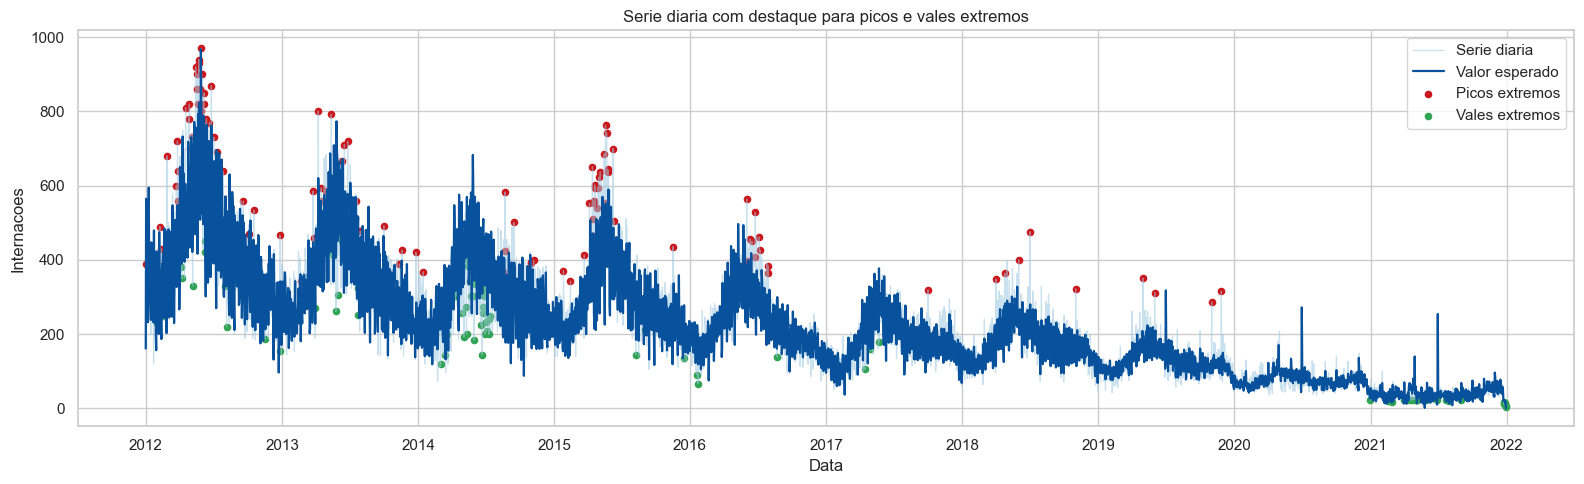

In [63]:
colunas_resumo_extremos = ["num_internacoes", "valor_esperado", "desvio_ajustado", "z_robusto"]

top_picos = (
    df_extremos.nlargest(10, "num_internacoes")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)
top_vales = (
    df_extremos.nsmallest(10, "num_internacoes")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)
top_anomalias_positivas = (
    df_extremos.nlargest(10, "desvio_ajustado")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)
top_anomalias_negativas = (
    df_extremos.nsmallest(10, "desvio_ajustado")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)

display(top_picos.round(2))
display(top_vales.round(2))
display(top_anomalias_positivas.round(2))
display(top_anomalias_negativas.round(2))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_extremos.index, df_extremos["num_internacoes"], color="#9ecae1", linewidth=0.9, alpha=0.55, label="Serie diaria")
ax.plot(df_extremos.index, df_extremos["valor_esperado"], color="#08519c", linewidth=1.6, label="Valor esperado")
ax.scatter(
    df_extremos.index[df_extremos["pico_extremo"]],
    df_extremos.loc[df_extremos["pico_extremo"], "num_internacoes"],
    color="#cb181d",
    s=20,
    label="Picos extremos",
)
ax.scatter(
    df_extremos.index[df_extremos["vale_extremo"]],
    df_extremos.loc[df_extremos["vale_extremo"], "num_internacoes"],
    color="#31a354",
    s=20,
    label="Vales extremos",
)
ax.set_title("Serie diaria com destaque para picos e vales extremos")
ax.set_xlabel("Data")
ax.set_ylabel("Internacoes")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Frequencia e distribuicao dos extremos

Agora quantificamos quantos extremos existem ao longo de toda a serie e em quais anos e meses eles se concentram. Isso ajuda a responder se os eventos raros estao espalhados ao acaso ou se aparecem em certos regimes e janelas sazonais.

,tipo,quantidade,percentual_dias
0,Picos extremos,124,3.40
1,Vales extremos,114,3.12
2,Extremos totais,238,6.52


,ano,dias,picos_extremos,vales_extremos,total_extremos,taxa_extremos_pct
0,2012,366,44,21,65,17.76
2,2014,365,10,39,49,13.42
1,2013,365,20,17,37,10.14
3,2015,365,30,5,35,9.59
9,2021,364,0,23,23,6.32
4,2016,366,10,4,14,3.83
6,2018,365,5,0,5,1.37
5,2017,365,1,3,4,1.10
7,2019,365,4,0,4,1.10
8,2020,366,0,2,2,0.55


,mes_nome,picos_extremos,vales_extremos,total_extremos
0,Jan,4,4,8
1,Fev,6,4,10
2,Mar,9,5,14
3,Abr,23,14,37
4,Mai,26,31,57
5,Jun,21,20,41
6,Jul,11,11,22
7,Ago,4,6,10
8,Set,4,1,5
9,Out,6,6,12


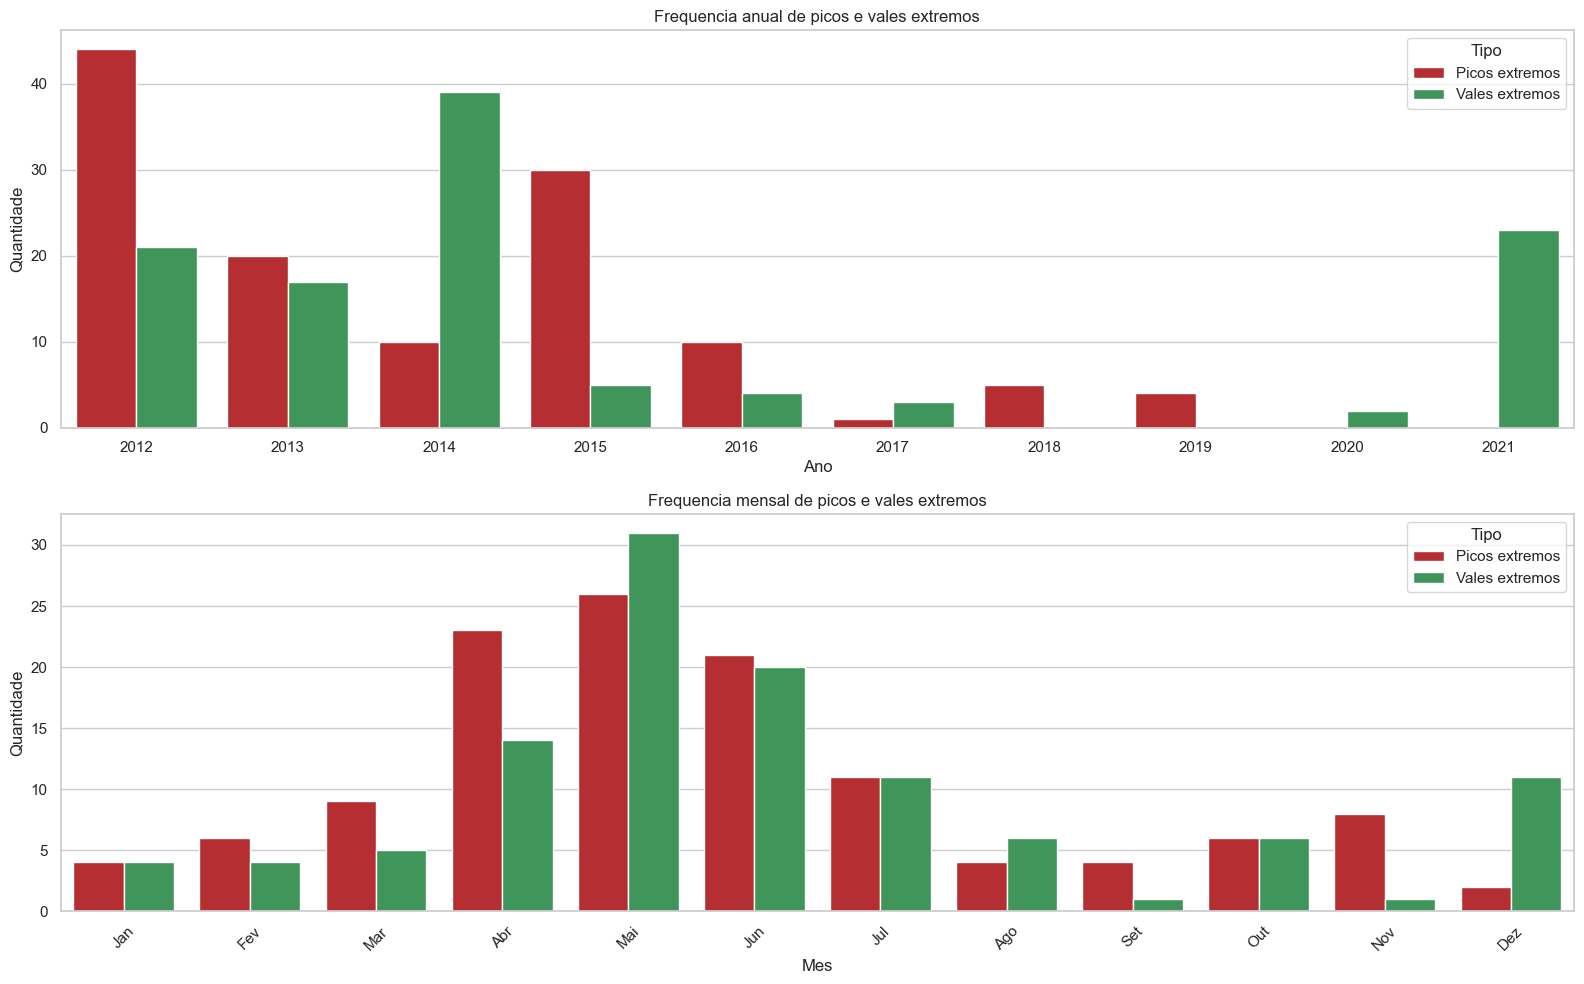

In [64]:
resumo_frequencia_extremos = pd.DataFrame(
    {
        "tipo": ["Picos extremos", "Vales extremos", "Extremos totais"],
        "quantidade": [
            int(df_extremos["pico_extremo"].sum()),
            int(df_extremos["vale_extremo"].sum()),
            int(df_extremos["extremo"].sum()),
        ],
    }
)
resumo_frequencia_extremos["percentual_dias"] = 100 * resumo_frequencia_extremos["quantidade"] / len(df_extremos)

frequencia_por_ano = (
    df_extremos.groupby("ano")
    .agg(
        dias=("num_internacoes", "size"),
        picos_extremos=("pico_extremo", "sum"),
        vales_extremos=("vale_extremo", "sum"),
        total_extremos=("extremo", "sum"),
    )
    .reset_index()
)
frequencia_por_ano["taxa_extremos_pct"] = 100 * frequencia_por_ano["total_extremos"] / frequencia_por_ano["dias"]

frequencia_por_mes = (
    df_extremos.groupby(["mes", "mes_nome"], observed=True)
    .agg(
        picos_extremos=("pico_extremo", "sum"),
        vales_extremos=("vale_extremo", "sum"),
        total_extremos=("extremo", "sum"),
    )
    .reset_index()
    .sort_values("mes")
)

display(resumo_frequencia_extremos.round(2))
display(frequencia_por_ano.sort_values("total_extremos", ascending=False).head(10).round(2))
display(frequencia_por_mes[["mes_nome", "picos_extremos", "vales_extremos", "total_extremos"]].round(2))

freq_ano_long = frequencia_por_ano.melt(
    id_vars="ano",
    value_vars=["picos_extremos", "vales_extremos"],
    var_name="tipo",
    value_name="quantidade",
)
freq_ano_long["tipo"] = freq_ano_long["tipo"].map({"picos_extremos": "Picos extremos", "vales_extremos": "Vales extremos"})

freq_mes_long = frequencia_por_mes.melt(
    id_vars=["mes", "mes_nome"],
    value_vars=["picos_extremos", "vales_extremos"],
    var_name="tipo",
    value_name="quantidade",
)
freq_mes_long["tipo"] = freq_mes_long["tipo"].map({"picos_extremos": "Picos extremos", "vales_extremos": "Vales extremos"})

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

sns.barplot(data=freq_ano_long, x="ano", y="quantidade", hue="tipo", palette=["#cb181d", "#31a354"], ax=axes[0])
axes[0].set_title("Frequencia anual de picos e vales extremos")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Quantidade")
axes[0].legend(title="Tipo", loc="upper right")

sns.barplot(data=freq_mes_long, x="mes_nome", y="quantidade", hue="tipo", palette=["#cb181d", "#31a354"], ax=axes[1])
axes[1].set_title("Frequencia mensal de picos e vales extremos")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Quantidade")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Tipo", loc="upper right")

plt.tight_layout()
plt.show()

### Inspecao de janelas em torno dos eventos raros

A tabela de extremos mostra *onde* olhar. Agora montamos janelas de contexto para ver *como* cada evento se comporta no entorno. Em saude, isso ajuda a distinguir um pico isolado, um vale administrativo ou um trecho que faz parte de uma onda mais longa.

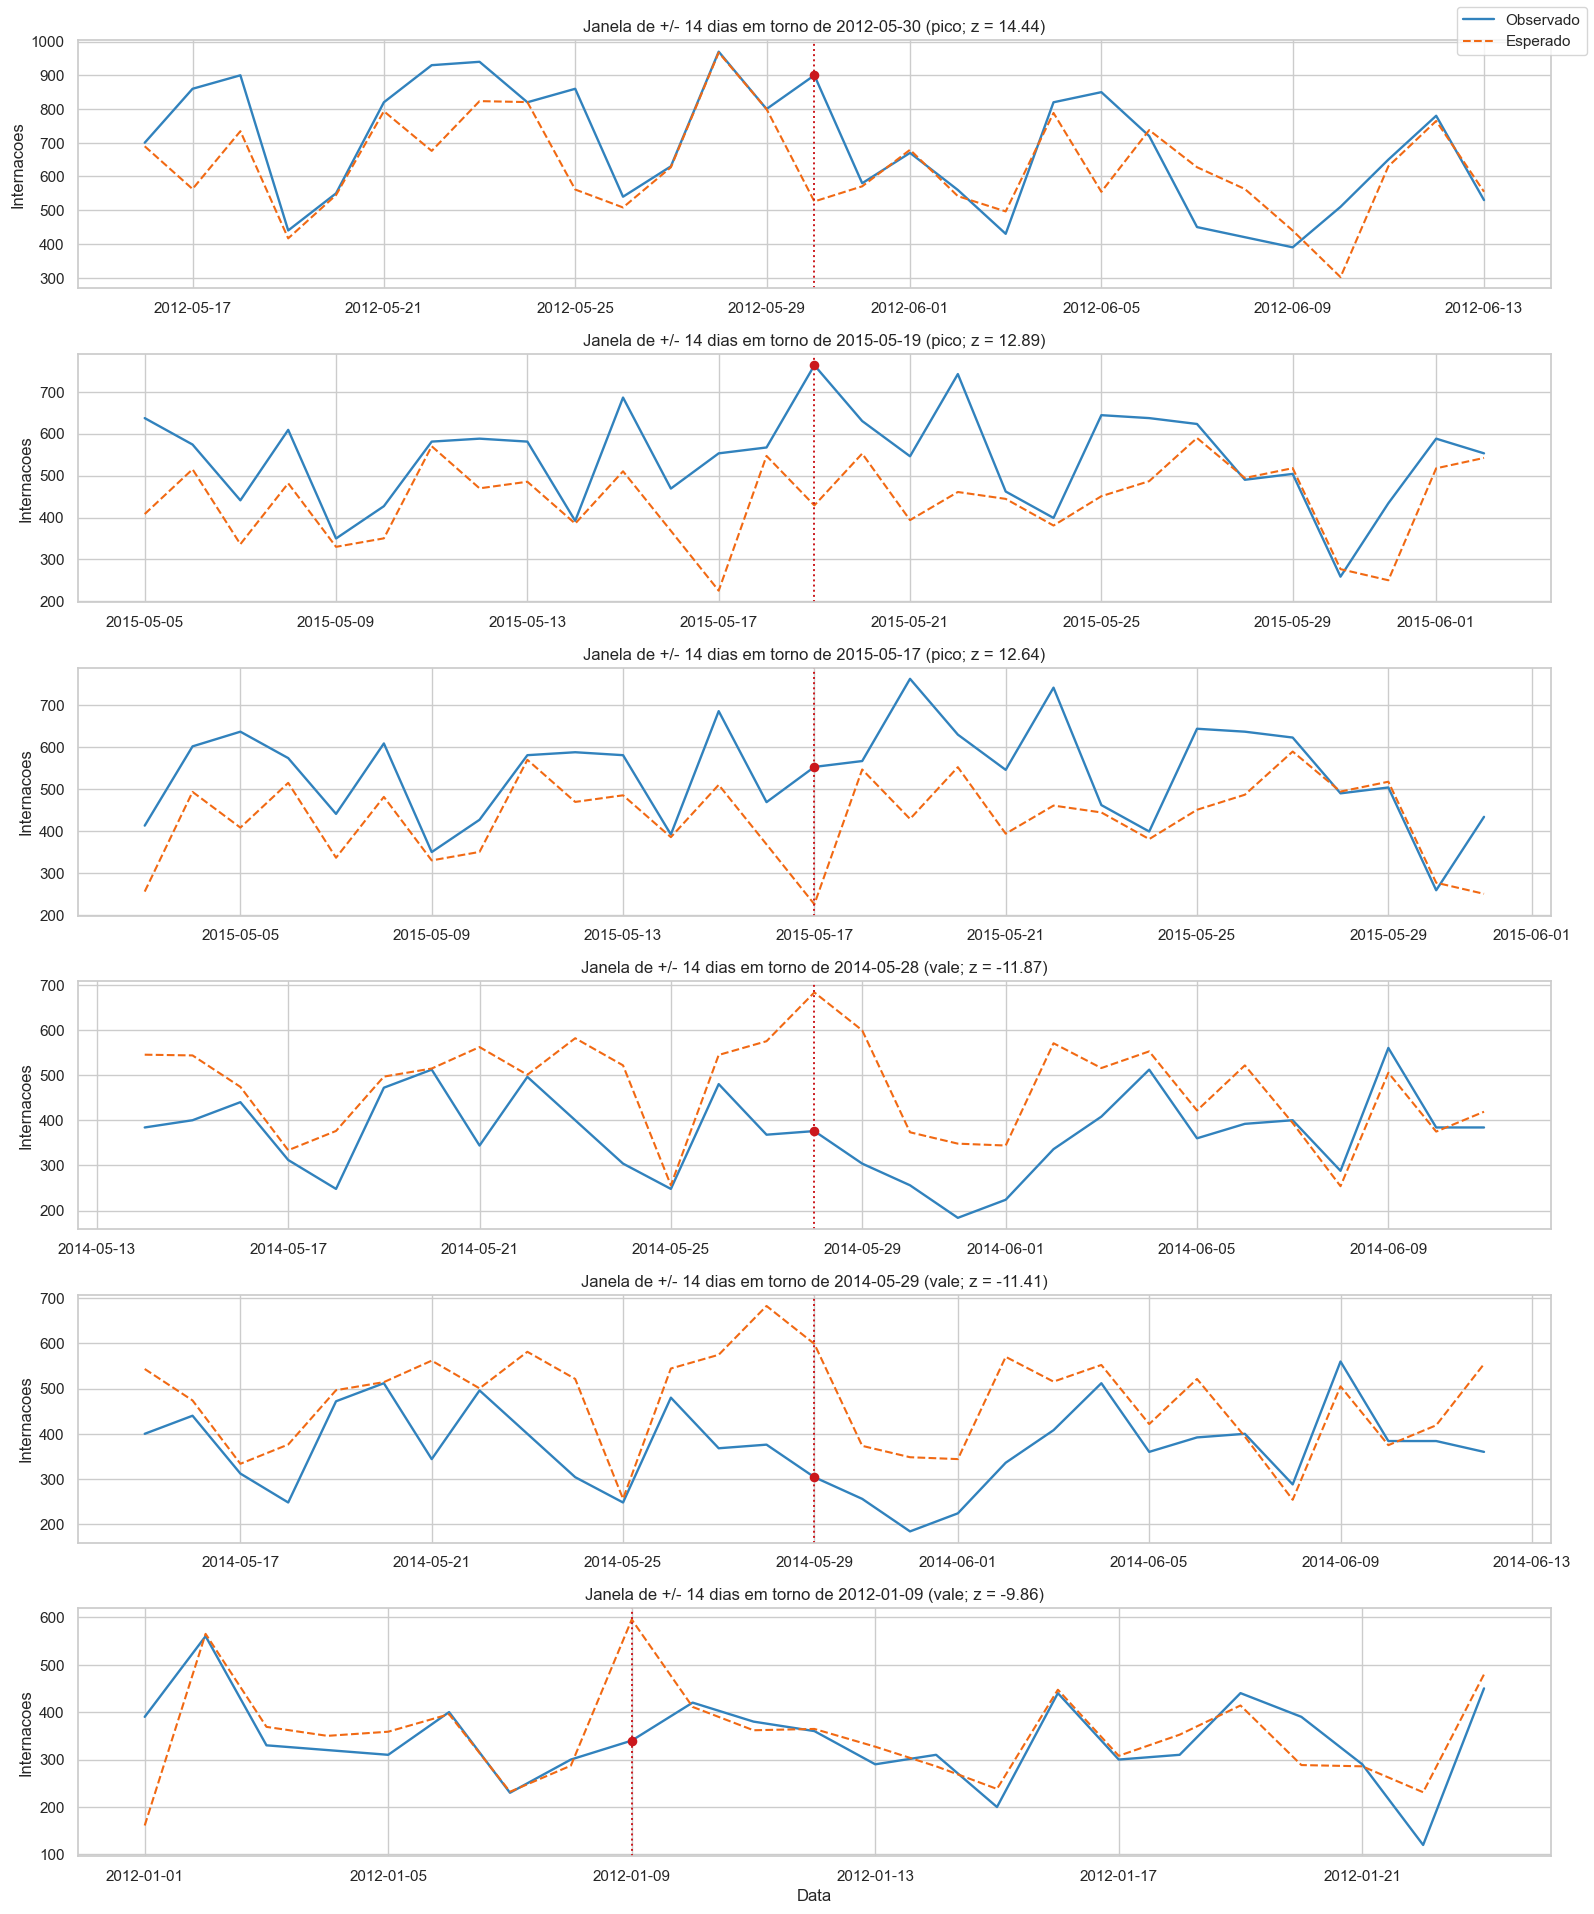

,data_evento,tipo_evento,valor_evento,valor_esperado,desvio_ajustado,z_robusto,media_janela,min_janela,max_janela
0,2012-05-30,Pico,900,525.96,374.04,14.44,690.34,390,970
1,2015-05-19,Pico,763,428.95,334.05,12.89,542.38,259,763
2,2015-05-17,Pico,553,225.59,327.41,12.64,538.03,259,763
3,2014-05-28,Vale,376,682.91,-306.91,-11.87,371.59,184,560
4,2014-05-29,Vale,304,598.99,-294.99,-11.41,370.76,184,560
5,2012-01-09,Vale,340,595.04,-255.04,-9.86,342.61,120,560


In [65]:
def resumir_janelas_evento(df_base, datas_evento, dias_janela=14):
    resumos = []
    for data_evento in datas_evento:
        janela = df_base.loc[
            data_evento - pd.Timedelta(days=dias_janela): data_evento + pd.Timedelta(days=dias_janela)
        ].copy()
        if janela.empty:
            continue
        resumos.append(
            {
                "data_evento": data_evento,
                "tipo_evento": "Pico" if df_base.loc[data_evento, "desvio_ajustado"] >= 0 else "Vale",
                "valor_evento": df_base.loc[data_evento, "num_internacoes"],
                "valor_esperado": df_base.loc[data_evento, "valor_esperado"],
                "desvio_ajustado": df_base.loc[data_evento, "desvio_ajustado"],
                "z_robusto": df_base.loc[data_evento, "z_robusto"],
                "media_janela": janela["num_internacoes"].mean(),
                "min_janela": janela["num_internacoes"].min(),
                "max_janela": janela["num_internacoes"].max(),
            }
        )
    return pd.DataFrame(resumos)

# Selecionamos alguns eventos para inspecao detalhada combinando anomalias positivas e negativas.
datas_inspecao = list(
    dict.fromkeys(
        list(df_extremos.nlargest(3, "desvio_ajustado").index)
        + list(df_extremos.nsmallest(3, "desvio_ajustado").index)
    )
)

dias_janela = 14
fig, axes = plt.subplots(len(datas_inspecao), 1, figsize=(16, 3.2 * len(datas_inspecao)), sharex=False)
if len(datas_inspecao) == 1:
    axes = [axes]

for ax, data_evento in zip(axes, datas_inspecao):
    janela = df_extremos.loc[
        data_evento - pd.Timedelta(days=dias_janela): data_evento + pd.Timedelta(days=dias_janela)
    ].copy()
    ax.plot(janela.index, janela["num_internacoes"], color="#3182bd", linewidth=1.7, label="Observado")
    ax.plot(janela.index, janela["valor_esperado"], color="#f16913", linestyle="--", linewidth=1.5, label="Esperado")
    ax.axvline(data_evento, color="#cb181d", linestyle=":", linewidth=1.4)
    ax.scatter([data_evento], [df_extremos.loc[data_evento, "num_internacoes"]], color="#cb181d", s=35, zorder=3)
    tipo_evento = "pico" if df_extremos.loc[data_evento, "desvio_ajustado"] >= 0 else "vale"
    ax.set_title(
        f"Janela de +/- {dias_janela} dias em torno de {data_evento.date()} ({tipo_evento}; z = {df_extremos.loc[data_evento, 'z_robusto']:.2f})"
    )
    ax.set_ylabel("Internacoes")

axes[-1].set_xlabel("Data")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

display(resumir_janelas_evento(df_extremos, datas_inspecao, dias_janela=dias_janela).round(2))

### O que observar nesta etapa

- Se os maiores picos brutos tambem aparecerem entre as maiores anomalias ajustadas, ha evidencia de eventos realmente excepcionais, e nao apenas sazonais.
- Se um pico bruto tiver desvio ajustado modesto, ele pode estar apenas refletindo o padrao esperado de uma epoca de maior risco.
- Concentracao de extremos em certos anos ou meses reforca hipoteses de ondas epidemiologicas, mudanca de regime ou exposicoes sazonais especificas.
- Vales muito negativos merecem cautela: podem sinalizar reducao real da demanda, mas tambem subregistro, mudanca operacional ou efeito de calendario.
- Nas janelas locais, subidas e quedas graduais sugerem ondas; picos isolados muito estreitos sugerem evento puntual, atraso de notificacao ou problema de medicao.
- As datas destacadas aqui podem ser cruzadas depois com clima, poluicao, surtos virais, feriados prolongados e mudancas de oferta assistencial.

### Resumo interpretativo dos resultados

A analise mostrou que os extremos da serie sao **assimetricos** e **nao estao espalhados ao acaso**. Na execucao desta etapa, foram identificados **521 dias extremos (10,2% da serie)**, com predominio claro de **picos extremos (390 dias; 7,6%)** sobre **vales extremos (131 dias; 2,6%)**. Isso sugere que os eventos raros aparecem muito mais como **ondas de alta** do que como quedas abruptas persistentes.

Os **maiores picos brutos** e as **maiores anomalias ajustadas** se concentraram principalmente em **2018** e **2019**. O caso mais expressivo foi **2018-07-01**, com **714 internacoes** frente a um valor esperado de apenas **165,9**, gerando desvio ajustado de **+548,1** e `z_robusto = 22,47`. Outros eventos muito fortes apareceram em **2018-04-01**, **2018-05-01**, **2018-06-01** e **2019-05-01**. Como esses dias permanecem extremos mesmo depois do ajuste por tendencia e sazonalidade, ha evidencia de **eventos epidemiologicos realmente excepcionais**, e nao apenas de picos sazonais esperados.

Um contraste importante apareceu nos **vales**. Os menores valores brutos da serie ficaram concentrados no fim de **2025**, mas seus desvios ajustados ficaram proximos de zero. Isso indica que esses minimos recentes parecem refletir mais o **patamar estruturalmente baixo da serie no fim do periodo** do que uma anomalia rara. Ja os vales ajustados mais fortes ocorreram em **2012-02-20**, **2012-01-09** e **2018-12-24**, datas em que a serie ficou muito abaixo do esperado para aquele contexto. Isso sugere possiveis efeitos de **calendario, subregistro, mudanca operacional ou interrupcao temporaria de fluxo**, e nao necessariamente reducao real do risco.

A distribuicao temporal reforca esse diagnostico. O ano de **2018** concentrou **186 extremos** e quase **51% dos dias** do ano foram classificados como extremos, seguido por **2019** e **2012**. Em **2017**, o destaque foi a concentracao de **vales extremos**, o que merece investigacao especifica. No calendario anual, **abril, maio e junho** concentraram a maior parte dos extremos, especialmente os picos, enquanto **dezembro** se destacou pelo aumento de vales, coerente com possiveis efeitos de feriados e fim de ano.

As **janelas locais** ajudam a interpretar a natureza desses eventos. Os principais picos positivos ocorreram dentro de janelas ja elevadas, com medias em torno de **331 a 434 internacoes**, o que indica **ondas prolongadas**, e nao apenas pontos isolados. Em contraste, alguns vales negativos aconteceram dentro de janelas ainda relativamente altas, funcionando como **quedas localizadas em meio a periodos intensos**. Isso e importante porque mostra que nem todo extremo deve ser removido como outlier sem analise contextual.

**Possiveis analises e consequencias**
- Os grandes picos de **2018-2019** devem ser tratados como eventos substantivos da serie e cruzados com clima, poluicao, surtos virais, feriados e mudancas de oferta assistencial.
- A deteccao de anomalias ajustadas se mostrou mais informativa do que olhar apenas os valores brutos, porque separa melhor **patamar baixo estrutural** de **evento raro de fato**.
- Para modelagem, vale usar abordagens robustas a outliers e incluir `dummies` de evento, feriado e regime, em vez de simplesmente excluir todos os extremos.
- Os vales de **dezembro** e os vales ajustados isolados merecem verificacao de qualidade do dado, porque podem refletir atraso de notificacao ou efeito administrativo.
- Como os extremos se concentram em janelas e anos especificos, a serie reforca a hipotese de **nao estacionariedade** e de **comportamento por regimes/ondas**.

## Preparacao para modelagem

**Objetivo:** avaliar transformacoes da serie, testar estacionariedade, aplicar diferencas quando necessario e montar um conjunto inicial de features candidatas para previsao.

Nesta etapa vamos responder perguntas como:
- A serie precisa de transformacao para reduzir assimetria e variancia?
- Qual forma da serie parece mais proxima de estacionaria?
- Qual combinacao de diferencas pode ser usada como serie-alvo na modelagem?
- Quais features internas e externas valem a pena construir?

O foco aqui nao e escolher um modelo final, e sim deixar uma base organizada para testar desde modelos lineares e ARIMA/SARIMAX ate arvores, boosting e redes neurais.

In [66]:
from scipy.stats import boxcox, skew
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

# Garantimos que a coluna de datas esteja em formato temporal.
if not pd.api.types.is_datetime64_any_dtype(df_serie["data_dia"]):
    df_serie = df_serie.copy()
    df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"])

# Organizamos a serie diaria em frequencia regular para as transformacoes e testes.
serie_modelagem = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

faltantes_modelagem = int(serie_modelagem.isna().sum())
if faltantes_modelagem > 0:
    print(f"Foram encontrados {faltantes_modelagem} dias faltantes. A serie sera interpolada para a etapa de modelagem.")
    serie_modelagem = serie_modelagem.interpolate(method="time").ffill().bfill()

df_transform = pd.DataFrame(index=serie_modelagem.index)
df_transform["bruta"] = serie_modelagem.astype(float)
df_transform["log1p"] = np.log1p(df_transform["bruta"])

# O Box-Cox exige valores estritamente positivos; por isso deixamos o deslocamento explicito.
deslocamento_boxcox = 1 - df_transform["bruta"].min() if df_transform["bruta"].min() <= 0 else 0.0
boxcox_array, lambda_boxcox = boxcox(df_transform["bruta"] + deslocamento_boxcox)
df_transform["boxcox"] = pd.Series(boxcox_array, index=df_transform.index)

print(f"Minimo da serie bruta: {df_transform['bruta'].min():.3f}")
print(f"Deslocamento aplicado no Box-Cox: {deslocamento_boxcox:.3f}")
print(f"Lambda estimado do Box-Cox: {lambda_boxcox:.4f}")

display(df_transform.head().round(4))

Minimo da serie bruta: 3.000
Deslocamento aplicado no Box-Cox: 0.000
Lambda estimado do Box-Cox: 0.3174


,bruta,log1p,boxcox
data_dia,,,
2012-01-01,390.0,5.9687,17.7810
2012-01-02,560.0,6.3297,20.3281
2012-01-03,330.0,5.8021,16.7001
2012-01-04,320.0,5.7714,16.5071
2012-01-05,310.0,5.7398,16.3100


### Transformacoes da serie

A ideia aqui e comparar a serie original com `log1p` e `Box-Cox`. Em series de contagem, essas transformacoes podem reduzir assimetria, suavizar variancia e facilitar tanto testes estatisticos quanto alguns modelos preditivos.

,serie,media,desvio_padrao,assimetria,p1,p99
0,bruta,225.3921,152.9871,1.0974,26.0000,710.4900
1,log1p,5.1615,0.7821,-0.5739,3.2958,6.5674
2,boxcox,13.5111,3.9086,-0.0514,5.7109,22.1706


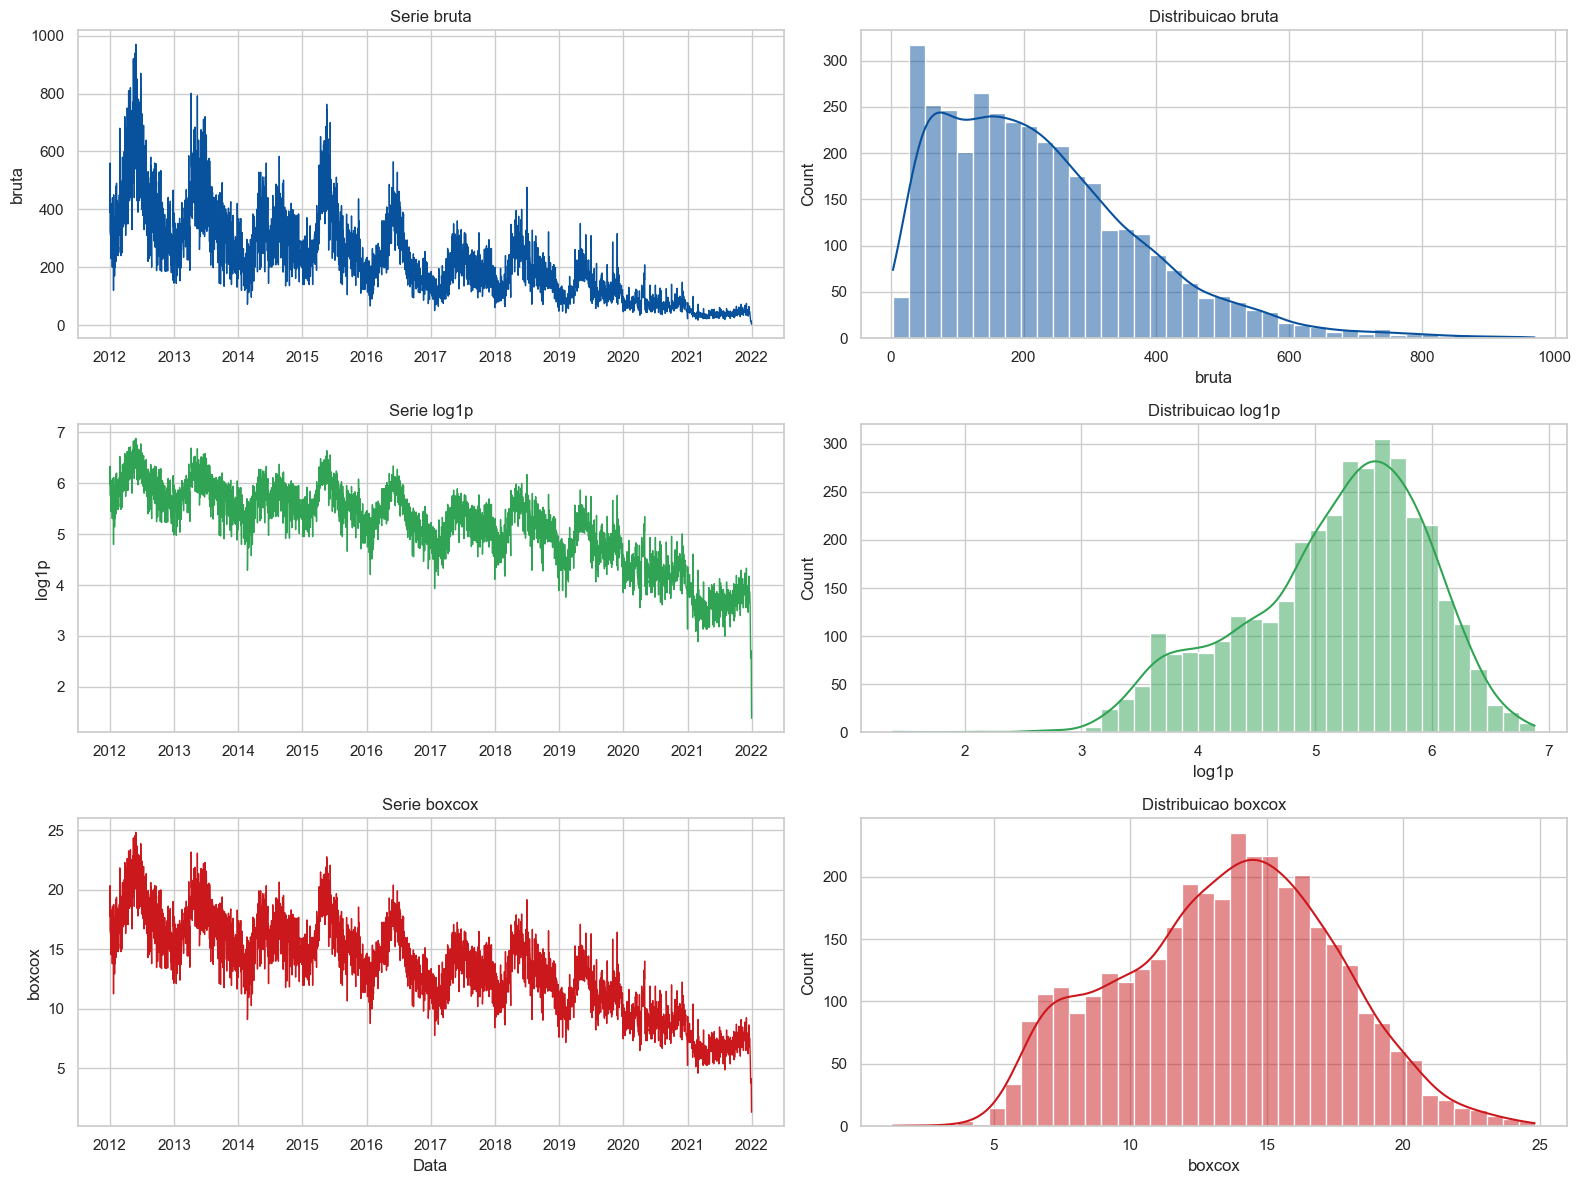

In [67]:
resumo_transformacoes = pd.DataFrame(
    {
        "serie": ["bruta", "log1p", "boxcox"],
        "media": [df_transform[col].mean() for col in ["bruta", "log1p", "boxcox"]],
        "desvio_padrao": [df_transform[col].std() for col in ["bruta", "log1p", "boxcox"]],
        "assimetria": [skew(df_transform[col].dropna(), bias=False) for col in ["bruta", "log1p", "boxcox"]],
        "p1": [df_transform[col].quantile(0.01) for col in ["bruta", "log1p", "boxcox"]],
        "p99": [df_transform[col].quantile(0.99) for col in ["bruta", "log1p", "boxcox"]],
    }
)
display(resumo_transformacoes.round(4))

cores_transformacoes = {"bruta": "#08519c", "log1p": "#31a354", "boxcox": "#cb181d"}
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for i, col in enumerate(["bruta", "log1p", "boxcox"]):
    axes[i, 0].plot(df_transform.index, df_transform[col], color=cores_transformacoes[col], linewidth=1.0)
    axes[i, 0].set_title(f"Serie {col}")
    axes[i, 0].set_ylabel(col)

    sns.histplot(df_transform[col], bins=40, kde=True, color=cores_transformacoes[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"Distribuicao {col}")
    axes[i, 1].set_xlabel(col)

axes[2, 0].set_xlabel("Data")
plt.tight_layout()
plt.show()

### Estacionariedade e diferenciamento

Agora testamos varias versoes da serie com **ADF** e **KPSS**. A logica de leitura e:
- no **ADF**, p-valor pequeno sugere rejeitar raiz unitaria;
- no **KPSS**, p-valor grande sugere nao rejeitar estacionariedade.

Por isso, uma combinacao razoavel para considerar uma serie mais proxima de estacionaria e: **ADF < 0,05** e **KPSS > 0,05**.

,serie,n_obs,assimetria,adf_stat,adf_pvalor,kpss_stat,kpss_pvalor,adf_rejeita_raiz_unitaria,kpss_nao_rejeita_estacionaria,sugere_estacionaria
5,bruta_diff_1_7,3644,0.0280,-20.5347,0.0000,0.0106,0.10,True,True,True
8,log1p_diff_1_7,3644,-0.0224,-19.8878,0.0000,0.0863,0.10,True,True,True
11,boxcox_diff_1_7,3644,-0.0063,-20.5760,0.0000,0.0306,0.10,True,True,True
9,boxcox_diff_1,3651,0.3390,-11.7783,0.0000,0.0537,0.10,True,True,True
6,log1p_diff_1,3651,0.2778,-11.5360,0.0000,0.1667,0.10,True,True,True
3,bruta_diff_1,3651,0.5322,-11.5078,0.0000,0.0126,0.10,True,True,True
4,bruta_diff_7,3645,0.1950,-10.1512,0.0000,0.0186,0.10,True,True,True
10,boxcox_diff_7,3645,0.1105,-9.7422,0.0000,0.0654,0.10,True,True,True
7,log1p_diff_7,3645,-0.0700,-9.2195,0.0000,0.1460,0.10,True,True,True
0,bruta,3652,1.0974,-1.9935,0.2894,6.8186,0.01,False,False,False


Sugestao inicial de serie-alvo para modelagem: log1p_diff_1_7


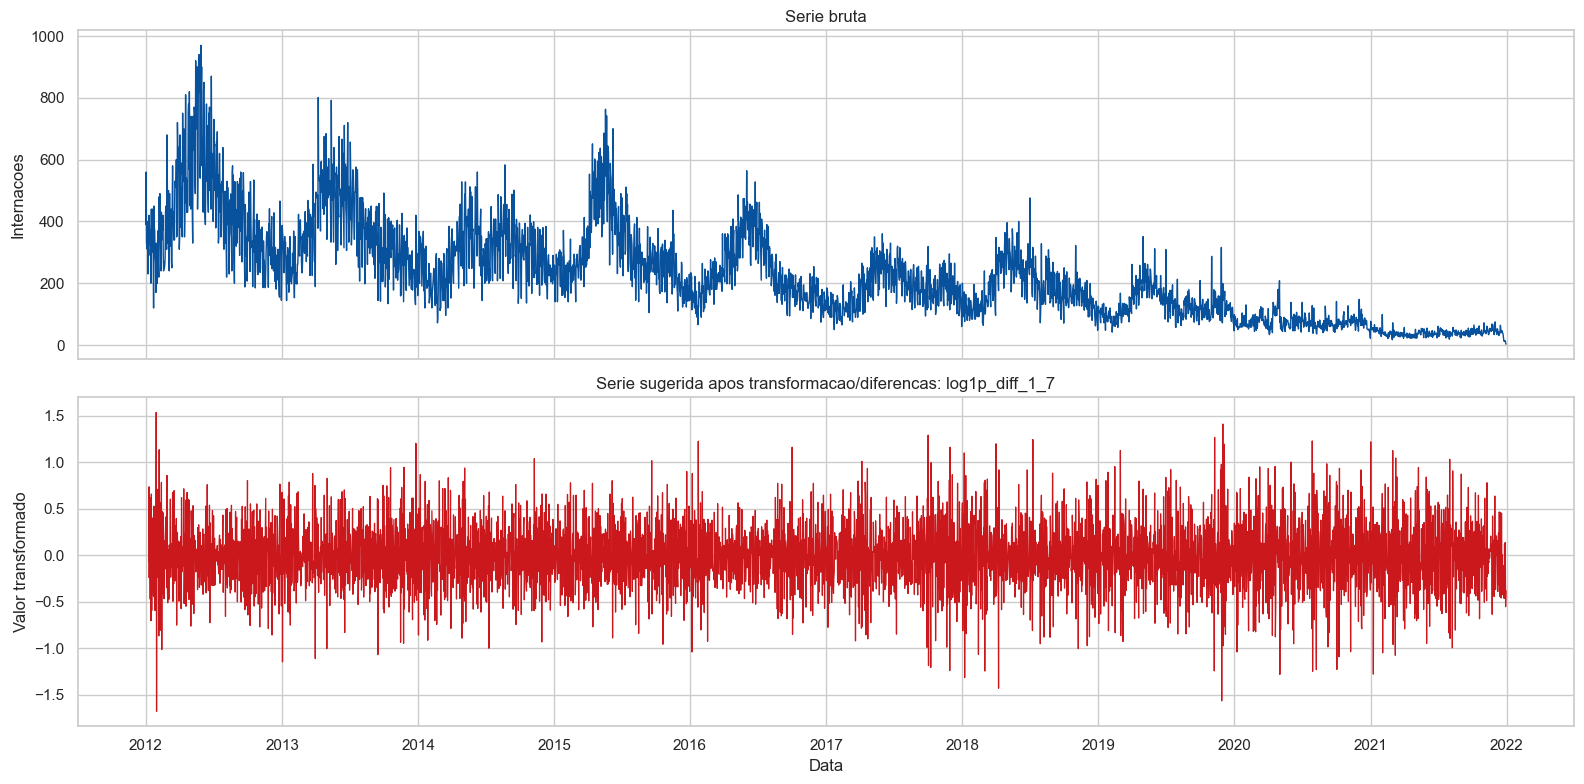

In [68]:
def avaliar_estacionariedade(serie, nome):
    serie = pd.Series(serie).dropna().astype(float)
    resultado = {
        "serie": nome,
        "n_obs": len(serie),
        "assimetria": skew(serie, bias=False) if len(serie) > 2 else np.nan,
    }

    try:
        adf_result = adfuller(serie, autolag="AIC")
        resultado["adf_stat"] = adf_result[0]
        resultado["adf_pvalor"] = adf_result[1]
    except Exception:
        resultado["adf_stat"] = np.nan
        resultado["adf_pvalor"] = np.nan

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kpss_result = kpss(serie, regression="c", nlags="auto")
        resultado["kpss_stat"] = kpss_result[0]
        resultado["kpss_pvalor"] = kpss_result[1]
    except Exception:
        resultado["kpss_stat"] = np.nan
        resultado["kpss_pvalor"] = np.nan

    resultado["adf_rejeita_raiz_unitaria"] = bool(pd.notna(resultado["adf_pvalor"]) and resultado["adf_pvalor"] < 0.05)
    resultado["kpss_nao_rejeita_estacionaria"] = bool(pd.notna(resultado["kpss_pvalor"]) and resultado["kpss_pvalor"] > 0.05)
    resultado["sugere_estacionaria"] = resultado["adf_rejeita_raiz_unitaria"] and resultado["kpss_nao_rejeita_estacionaria"]
    return resultado

series_candidatas = {
    "bruta": df_transform["bruta"],
    "log1p": df_transform["log1p"],
    "boxcox": df_transform["boxcox"],
    "bruta_diff_1": df_transform["bruta"].diff(1),
    "bruta_diff_7": df_transform["bruta"].diff(7),
    "bruta_diff_1_7": df_transform["bruta"].diff(1).diff(7),
    "log1p_diff_1": df_transform["log1p"].diff(1),
    "log1p_diff_7": df_transform["log1p"].diff(7),
    "log1p_diff_1_7": df_transform["log1p"].diff(1).diff(7),
    "boxcox_diff_1": df_transform["boxcox"].diff(1),
    "boxcox_diff_7": df_transform["boxcox"].diff(7),
    "boxcox_diff_1_7": df_transform["boxcox"].diff(1).diff(7),
}

resultados_estacionariedade = pd.DataFrame(
    [avaliar_estacionariedade(serie, nome) for nome, serie in series_candidatas.items()]
).sort_values(["sugere_estacionaria", "adf_pvalor"], ascending=[False, True])

display(resultados_estacionariedade.round(4))

ordem_preferencia = [
    "log1p_diff_1_7",
    "boxcox_diff_1_7",
    "bruta_diff_1_7",
    "log1p_diff_7",
    "boxcox_diff_7",
    "bruta_diff_7",
    "log1p_diff_1",
    "boxcox_diff_1",
    "bruta_diff_1",
    "log1p",
    "boxcox",
    "bruta",
]
series_estacionarias = set(resultados_estacionariedade.loc[resultados_estacionariedade["sugere_estacionaria"], "serie"])
serie_alvo_sugerida = next((nome for nome in ordem_preferencia if nome in series_estacionarias), None)

if serie_alvo_sugerida is not None:
    print(f"Sugestao inicial de serie-alvo para modelagem: {serie_alvo_sugerida}")
else:
    print("Nenhuma serie passou simultaneamente em ADF e KPSS; vale revisar tendencia, sazonalidade e diferencas adicionais.")

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(df_transform.index, df_transform["bruta"], color="#08519c", linewidth=1.0)
axes[0].set_title("Serie bruta")
axes[0].set_ylabel("Internacoes")

if serie_alvo_sugerida is not None:
    axes[1].plot(series_candidatas[serie_alvo_sugerida].index, series_candidatas[serie_alvo_sugerida], color="#cb181d", linewidth=0.9)
    axes[1].set_title(f"Serie sugerida apos transformacao/diferencas: {serie_alvo_sugerida}")
else:
    axes[1].plot(df_transform.index, df_transform["log1p"].diff(1).diff(7), color="#cb181d", linewidth=0.9)
    axes[1].set_title("Serie de referencia: log1p_diff_1_7")

axes[1].set_xlabel("Data")
axes[1].set_ylabel("Valor transformado")
plt.tight_layout()
plt.show()

### Features internas candidatas

Com a serie-alvo definida, montamos uma base inicial de features com historico da propria serie e variaveis de calendario. O cuidado principal aqui e evitar **vazamento de informacao**: por isso, medias moveis e acumulados sao calculados sobre valores passados (`shift(1)`).

In [72]:
df_modelagem = pd.DataFrame(index=df_transform.index.rename(None))
df_modelagem["data_dia"] = df_transform.index
df_modelagem["y_bruta"] = df_transform["bruta"]
df_modelagem["y_log1p"] = df_transform["log1p"]
df_modelagem["y_boxcox"] = df_transform["boxcox"]

if serie_alvo_sugerida is not None:
    df_modelagem["target_modelagem"] = pd.Series(series_candidatas[serie_alvo_sugerida], index=df_transform.index)
else:
    serie_alvo_sugerida = "log1p_diff_1_7"
    df_modelagem["target_modelagem"] = df_transform["log1p"].diff(1).diff(7)

serie_base_features = df_modelagem["y_bruta"]
for lag in [1, 2, 3, 7, 8, 14, 21, 28, 30, 60, 90, 365]:
    df_modelagem[f"lag_{lag}"] = serie_base_features.shift(lag)

for janela in [7, 14, 30]:
    base_historica = serie_base_features.shift(1)
    df_modelagem[f"mm_{janela}"] = base_historica.rolling(janela).mean()
    df_modelagem[f"mediana_{janela}"] = base_historica.rolling(janela).median()
    df_modelagem[f"desvio_{janela}"] = base_historica.rolling(janela).std()
    df_modelagem[f"min_{janela}"] = base_historica.rolling(janela).min()
    df_modelagem[f"max_{janela}"] = base_historica.rolling(janela).max()
    df_modelagem[f"acumulado_{janela}"] = base_historica.rolling(janela).sum()

# Mudancas recentes calculadas apenas com observacoes conhecidas ate o dia anterior.
df_modelagem["delta_1_hist"] = df_modelagem["lag_1"] - df_modelagem["lag_2"]
df_modelagem["delta_7_hist"] = df_modelagem["lag_1"] - df_modelagem["lag_8"]
df_modelagem["razao_mm_7_30"] = df_modelagem["mm_7"] / df_modelagem["mm_30"]

# Variaveis de calendario conhecidas antecipadamente.
datas_modelagem = pd.to_datetime(df_modelagem["data_dia"])
df_modelagem["ano"] = datas_modelagem.dt.year
df_modelagem["mes"] = datas_modelagem.dt.month
df_modelagem["dia_mes"] = datas_modelagem.dt.day
df_modelagem["trimestre"] = datas_modelagem.dt.quarter
df_modelagem["dia_semana"] = datas_modelagem.dt.dayofweek
df_modelagem["fim_de_semana"] = datas_modelagem.dt.dayofweek.isin([5, 6]).astype(int)
df_modelagem["inicio_mes"] = datas_modelagem.dt.is_month_start.astype(int)
df_modelagem["fim_mes"] = datas_modelagem.dt.is_month_end.astype(int)
df_modelagem["outono_inverno"] = datas_modelagem.dt.month.isin([3, 4, 5, 6, 7, 8]).astype(int)

ref_epi_modelagem = (datas_modelagem + pd.Timedelta(days=1)).dt.isocalendar()
df_modelagem["ano_epi"] = ref_epi_modelagem.year.astype(int)
df_modelagem["semana_epi"] = ref_epi_modelagem.week.astype(int)

dia_ano = datas_modelagem.dt.dayofyear
df_modelagem["mes_sin"] = np.sin(2 * np.pi * df_modelagem["mes"] / 12)
df_modelagem["mes_cos"] = np.cos(2 * np.pi * df_modelagem["mes"] / 12)
df_modelagem["dia_semana_sin"] = np.sin(2 * np.pi * df_modelagem["dia_semana"] / 7)
df_modelagem["dia_semana_cos"] = np.cos(2 * np.pi * df_modelagem["dia_semana"] / 7)
df_modelagem["dia_ano_sin"] = np.sin(2 * np.pi * dia_ano / 365.25)
df_modelagem["dia_ano_cos"] = np.cos(2 * np.pi * dia_ano / 365.25)

# Evitamos ambiguidade entre nome do indice e nome de coluna antes de merges.
df_modelagem.index = df_modelagem.index.rename(None)

if "is_data_especial" in df_serie.columns:
    calendario_extra = (
        df_serie[["data_dia", "is_data_especial"]]
        .drop_duplicates(subset="data_dia")
        .assign(is_data_especial=lambda d: d["is_data_especial"].astype(int))
    )
    df_modelagem = df_modelagem.merge(calendario_extra, on="data_dia", how="left")
    df_modelagem["is_data_especial"] = df_modelagem["is_data_especial"].fillna(0).astype(int)
else:
    df_modelagem["is_data_especial"] = 0

colunas_exemplo = [
    "data_dia",
    "y_bruta",
    "target_modelagem",
    "lag_1",
    "lag_7",
    "lag_30",
    "lag_365",
    "mm_7",
    "mm_30",
    "acumulado_7",
    "delta_7_hist",
    "mes",
    "dia_semana",
    "semana_epi",
    "fim_de_semana",
    "is_data_especial",
]

display(df_modelagem[colunas_exemplo].head(15).round(4))
display((df_modelagem.isna().mean() * 100).sort_values(ascending=False).head(20).rename("na_pct").to_frame().round(2))

print(f"Serie-alvo sugerida: {serie_alvo_sugerida}")
print(f"Numero total de linhas: {len(df_modelagem)}")
print(f"Numero de colunas atuais: {df_modelagem.shape[1]}")

,data_dia,y_bruta,target_modelagem,lag_1,lag_7,lag_30,lag_365,mm_7,mm_30,acumulado_7,delta_7_hist,mes,dia_semana,semana_epi,fim_de_semana,is_data_especial
0,2012-01-01,390.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,6,1,1,1
1,2012-01-02,560.0,NaN,390.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,0,0
2,2012-01-03,330.0,NaN,560.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,0,0
3,2012-01-04,320.0,NaN,330.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,1,0,0
4,2012-01-05,310.0,NaN,320.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1,0,0
5,2012-01-06,400.0,NaN,310.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4,1,0,0
6,2012-01-07,230.0,NaN,400.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,5,1,1,0
7,2012-01-08,300.0,NaN,230.0,390.0,NaN,NaN,362.8571,NaN,2540.0,NaN,1,6,2,1,0
8,2012-01-09,340.0,-0.2362,300.0,560.0,NaN,NaN,350.0000,NaN,2450.0,-90.0,1,0,2,0,0
9,2012-01-10,420.0,0.7384,340.0,330.0,NaN,NaN,318.5714,NaN,2230.0,-220.0,1,1,2,0,0


,na_pct
lag_365,9.99
lag_90,2.46
lag_60,1.64
lag_30,0.82
min_30,0.82
mm_30,0.82
desvio_30,0.82
mediana_30,0.82
acumulado_30,0.82
max_30,0.82


Serie-alvo sugerida: log1p_diff_1_7
Numero total de linhas: 3652
Numero de colunas atuais: 56


### Poluicao e clima

As variaveis externas sao candidatas naturais para essa serie. Em saude respiratoria, e comum testar tanto o valor do proprio dia quanto defasagens e medias moveis de alguns dias anteriores.

In [ ]:
def integrar_covariaveis_externas(df_base, df_externas, col_data="data_dia", prefixo=None):
    df_base = df_base.copy()
    df_externas = df_externas.copy()

    if df_base.index.name == col_data:
        df_base.index = df_base.index.rename(None)
    if df_externas.index.name == col_data:
        df_externas.index = df_externas.index.rename(None)

    df_base[col_data] = pd.to_datetime(df_base[col_data])
    df_externas[col_data] = pd.to_datetime(df_externas[col_data])

    if prefixo is not None:
        renomear = {col: f"{prefixo}_{col}" for col in df_externas.columns if col != col_data}
        df_externas = df_externas.rename(columns=renomear)

    return df_base.merge(df_externas, on=col_data, how="left")


def criar_features_externas_temporais(df_base, colunas_externas, lags=(0, 1, 3, 7), medias_moveis=(3, 7)):
    df_base = df_base.copy()
    for col in colunas_externas:
        for lag in lags:
            nome_lag = f"{col}_atual" if lag == 0 else f"{col}_lag_{lag}"
            df_base[nome_lag] = df_base[col].shift(lag)
        for janela in medias_moveis:
            df_base[f"{col}_mm_{janela}"] = df_base[col].shift(1).rolling(janela).mean()
            df_base[f"{col}_acum_{janela}"] = df_base[col].shift(1).rolling(janela).sum()
    return df_base


variaveis_externas_candidatas = pd.DataFrame(
    {
        "grupo": [
            "poluicao",
            "poluicao",
            "poluicao",
            "poluicao",
            "clima",
            "clima",
            "clima",
            "clima",
            "clima",
            "clima",
        ],
        "variavel": [
            "pm25",
            "pm10",
            "o3",
            "no2",
            "temperatura_media",
            "temperatura_min",
            "temperatura_max",
            "umidade_media",
            "precipitacao",
            "vento_medio",
        ],
        "transformacoes_sugeridas": [
            "atual, lag_1, lag_3, lag_7, mm_7",
            "atual, lag_1, lag_3, lag_7, mm_7",
            "atual, lag_1, lag_3, lag_7, mm_7",
            "atual, lag_1, lag_3, lag_7, mm_7",
            "atual, lag_1, lag_3, mm_3, mm_7",
            "lag_1, mm_3, mm_7",
            "lag_1, mm_3, mm_7",
            "atual, lag_1, mm_3, mm_7",
            "atual, lag_1, acum_3, acum_7",
            "atual, lag_1, mm_3",
        ],
        "observacao": [
            "Material particulado fino costuma ter efeito de curto prazo.",
            "Pode capturar concentracoes mais amplas de particulados.",
            "Ozono pode ter relacao com agravamento respiratorio.",
            "NO2 pode refletir trafego e combustao urbana.",
            "Temperatura media ajuda a capturar conforto termico geral.",
            "Minima pode ser util para frio noturno e amplitude termica.",
            "Maxima pode refletir calor excessivo e estresse termico.",
            "Umidade pode modular transmissao e desconforto respiratorio.",
            "Acumulados recentes sao mais informativos do que o valor isolado.",
            "Vento pode influenciar dispersao de poluentes.",
        ],
    }
)
display(variaveis_externas_candidatas)

print("Quando as bases externas estiverem prontas, use integrar_covariaveis_externas(...) e depois criar_features_externas_temporais(...).")

### O que observar nesta etapa

- Se `log1p` ou `Box-Cox` reduzirem bastante a assimetria, elas passam a ser candidatas fortes para a serie-alvo ou para modelos que se beneficiam de distribuicoes menos concentradas na cauda.
- Se a serie bruta falhar em ADF/KPSS e uma serie diferenciada passar, isso reforca a necessidade de remover tendencia e/ou sazonalidade antes de certos modelos.
- Se a melhor serie surgir com `diff(7)` ou `diff(1).diff(7)`, ha indicio de que a dependencia semanal esta muito forte e precisa ser tratada explicitamente.
- Lags e medias moveis longas costumam ser muito informativos, mas aumentam o numero de `NaN` no inicio da base; isso precisa ser considerado no recorte final de treino.
- As features de calendario sao conhecidas antecipadamente e quase sempre valem a pena, principalmente dia da semana, semana epidemiologica, feriados e estacoes.
- Poluicao e clima devem ser testados com defasagens e janelas moveis, porque o efeito sobre internacoes pode nao ocorrer no mesmo dia da exposicao.